# Deep Learning for EAS Reconstruction
## An Interpretable Multi-Task CNN-Transformer Model for the CONDOR Observatory

This notebook implements the full pipeline described in the paper:
multi-task CNN-Transformer for (1) gamma/hadron classification, (2) zenith angle reconstruction, (3) energy estimation.

**Architecture:** 6 Transformer streams (3 CNN + 3 RAW) with task-specific attention — **531,375 parameters**.

### Contributions and Reference
- Joint multi-task learning for classification + regression (angle, energy).
- Hybrid sequence + global branch with per-task attention.
- Physics-driven feature engineering and balanced splits.
- Dual attention streams (CNN + RAW) for interpretability.

**Zenodo DOI:** [10.5281/zenodo.17717722](https://doi.org/10.5281/zenodo.17717722)  
**GitHub:** [luisnavarrof/CONDOR_EAS-Reconstruction](https://github.com/luisnavarrof/CONDOR_EAS-Reconstruction)  
**Author:** Luis F. Navarro — luis.navarrof@usm.cl

In [1]:
import os
import json
import pickle
import random
import gc
from pathlib import Path
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from scipy.stats import norm, pearsonr, spearmanr
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    roc_curve,
    auc,
    roc_auc_score,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, callbacks, optimizers, Input, Model
from tensorflow.keras.metrics import Metric
from tensorflow.keras.preprocessing.sequence import pad_sequences

### Visualization Defaults and Shared Utilities

In [2]:
# ===================================================== #
# CONDOR thesis visual identity                          #
# ===================================================== #
SAVE_DPI = 200

CONDOR_DARKRED = "#6E1423"   # primary  - thesis citation colour
CONDOR_RED     = "#A4243B"   # accent
CONDOR_INK     = "#1A1A1A"   # near-black
CONDOR_GRAY    = "#9E9E9E"   # neutral grey
CONDOR_CREAM   = "#F2E8E5"   # warm off-white

# Particle classes: proton = ink, gamma (signal) = dark red
PARTICLE_PALETTE = {0: CONDOR_INK, 1: CONDOR_DARKRED}
PARTICLE_LABELS  = {0: "Proton", 1: r"$\gamma$"}

# Energy levels: light -> dark red ramp
ENERGY_PALETTE = {"3E2": "#C97B86", "5E2": CONDOR_RED, "8E2": CONDOR_DARKRED}
ENERGY_LABEL_MAP = {"3E2": "300 GeV", "5E2": "500 GeV", "8E2": "800 GeV"}

# Shared colormaps: sequential (cream -> dark red), diverging (ink <-> dark red)
CMAP_SEQ = LinearSegmentedColormap.from_list(
    "condor_seq", [CONDOR_CREAM, "#C97B86", CONDOR_RED, CONDOR_DARKRED, "#3D0A14"])
CMAP_DIV = LinearSegmentedColormap.from_list(
    "condor_div", [CONDOR_INK, CONDOR_GRAY, CONDOR_CREAM, CONDOR_RED, CONDOR_DARKRED])


def apply_condor_style():
    """Document-grade, consistent matplotlib style for every figure."""
    sns.set_style("ticks")
    mpl.rcParams.update({
        "figure.dpi": 110, "savefig.dpi": SAVE_DPI, "savefig.bbox": "tight",
        "figure.facecolor": "white", "axes.facecolor": "white",
        "font.family": "serif", "font.size": 13,
        "axes.titlesize": 14, "axes.titleweight": "bold",
        "axes.labelsize": 13, "axes.labelcolor": CONDOR_INK,
        "axes.edgecolor": CONDOR_INK, "axes.linewidth": 0.9,
        "axes.grid": True, "axes.axisbelow": True,
        "grid.color": "#DCDCDC", "grid.linewidth": 0.6, "grid.alpha": 0.7,
        "xtick.color": CONDOR_INK, "ytick.color": CONDOR_INK,
        "xtick.labelsize": 12, "ytick.labelsize": 12,
        "legend.fontsize": 12, "legend.frameon": False, "lines.linewidth": 1.8,
        "axes.prop_cycle": mpl.cycler(color=[CONDOR_DARKRED, CONDOR_INK, CONDOR_RED, CONDOR_GRAY, "#C97B86"]),
    })


apply_condor_style()


# ─────────────────────────────── #
# Shared metric: F1Score          #
# ─────────────────────────────── #
class F1Score(Metric):
    """Binary F1 metric for Keras. Defined once, used in build and load."""

    def __init__(self, name="f1_score", threshold=0.5, **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        self.tp.assign_add(tf.reduce_sum(y_true * y_pred))
        self.fp.assign_add(tf.reduce_sum((1 - y_true) * y_pred))
        self.fn.assign_add(tf.reduce_sum(y_true * (1 - y_pred)))

    def result(self):
        precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
        recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
        return 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

    def reset_state(self):
        self.tp.assign(0)
        self.fp.assign(0)
        self.fn.assign(0)


# ─────────────────────────────── #
# CORSIKA column mapping          #
# ─────────────────────────────── #
# Columns in the raw shower_data array (CORSIKA output):
CORSIKA_COLS = {
    "detector_id": 0,
    "t_bin": 1,
    "particle_count": 2,
    "shower_id": 3,
    "angle": 4,
    "x_center": 5,
    "y_center": 6,
    "total_energy": 7,
}
# Order used for model input features:
FEATURE_NAMES = ["detector_id", "particle_count", "t_bin", "total_energy", "x_center", "y_center"]
FEATURE_ORDER = [CORSIKA_COLS[f] for f in FEATURE_NAMES]
FEATURE_IDX = {name: i for i, name in enumerate(FEATURE_NAMES)}

## 1. Data Pipeline
### Reproducibility and Environment
- Fixed seeds (numpy, random, tensorflow).
- GPU memory growth.
- Paths and artifact directories.

In [3]:
# ─────────────────────────────── #
# Reproducibility configuration   #
# ─────────────────────────────── #
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# GPU setup
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU detected: {gpus[0].name} ({len(gpus)} device(s))")
else:
    print("No GPU detected — running on CPU")

strategy = tf.distribute.get_strategy()

GPU detected: /physical_device:GPU:0 (1 device(s))


### Data Source and Physics Cuts
- Monte Carlo EAS simulations (CORSIKA) for CONDOR.
- Energy bands: 300, 500, 800 GeV; zenith $\leq$ 40 deg; min total particles $\geq$ 30.
- Cached pickle download if missing.

In [4]:
# ─────────────────────────────── #
# Paths and pipeline parameters   #
# ─────────────────────────────── #
BASE_DIR = Path.cwd()  # run from the code/ directory (Jupyter default)
CACHE_FILE = BASE_DIR / "processed_all_data.pkl"

# Processed dataset archived on Zenodo, doi:10.5281/zenodo.17717722
# (md5 cf21f0de988a269fb5128e0e8993f632)
if not CACHE_FILE.exists():
    import urllib.request
    url = "https://zenodo.org/records/17717722/files/processed_all_data.pkl?download=1"
    urllib.request.urlretrieve(url, CACHE_FILE)

ARTIFACTS_DIR = BASE_DIR / "pipeline_artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

ENERGY_FILTER = ("3E2", "5E2", "8E2")
ANGLE_MAX = 40.0
MIN_TOTAL_PARTICLES = 30

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15  # test = 0.15 (remaining)
BATCH_SIZE = 32
EPOCHS = 100

# Diagnostics output directory (used by many cells)
plots_dir = ARTIFACTS_DIR / "diagnostics"
plots_dir.mkdir(parents=True, exist_ok=True)

In [5]:
# ----------------------------- #
# Load from pickle              #
# ----------------------------- #
def load_dataset_from_cache(cache_path: Path) -> pd.DataFrame:
    if not cache_path.exists():
        raise FileNotFoundError(
            f"{cache_path} not found. Regenerate the pickle before running the pipeline."
        )
    with cache_path.open("rb") as fh:
        data = pickle.load(fh)
    if isinstance(data, pd.DataFrame):
        df = data.copy()
    elif isinstance(data, dict):
        df = pd.DataFrame(data)
    else:
        raise ValueError("Unsupported cache format.")
    required_cols = {"shower_data", "angle", "label", "energy", "total_particles", "max_time"}
    if not required_cols.issubset(df.columns):
        raise ValueError("The pickle does not contain all required columns.")
    return df.reset_index(drop=True)

df_full = load_dataset_from_cache(CACHE_FILE)

df_full = df_full[
    (df_full["energy"].isin(ENERGY_FILTER)) &
    (df_full["angle"] <= ANGLE_MAX) &
    (df_full["total_particles"] >= MIN_TOTAL_PARTICLES)
].reset_index(drop=True)
if df_full.empty:
    raise RuntimeError("No events found after filtering by energy / angle / particles.")
df_full["idx"] = df_full.index

In [6]:
df_full.head()

,shower_data,angle,label,energy,total_particles,max_time,idx
0,"[[34.0, 0.0, 1.0, -10.521292, -0.18196964, -12...",0.0,1,3E2,31,28,0
1,"[[72.0, 0.0, 1.0, 23.91233, -21.620737, 21.25,...",0.0,1,3E2,92,49,1
2,"[[52.0, 0.0, 3.0, 5.457006, -21.212957, 4.25, ...",0.0,1,3E2,154,77,2
3,"[[46.0, 0.0, 1.0, -3.1485364, 15.506375, -4.25...",0.0,1,3E2,109,104,3
4,"[[64.0, 0.0, 2.0, 10.033819, -3.3683705, 12.75...",0.0,1,3E2,48,74,4


### Description of CONDOR Dataset Variables

Below are the variables used in this notebook, originating from simulated extensive air showers (EAS) under the CONDOR observatory conditions. These variables are divided into sequence features (individual hits), global event features, and target variables.

| Variable | Description |
|:---|:---|
| **`shower_data`** | Raw sequence of hits recorded by the detectors. This is the main input for the convolutional/recurrent branch. |
| `detector_id` | Unique identifier of the detector that registered the signal. |
| `x_center`, `y_center` | Spatial coordinates (in meters) of the center of the activated detector. |
| `t_bin` | Discretized time bin when the signal was recorded in the detector. |
| `particle_count` | Number of secondary particles detected in the detector at that instant. |
| `total_energy` (hit) | Energy deposited in the specific detector during the hit. |
| **`total_particles`** | Total sum of particles detected across the entire array (global feature). |
| **`active_detectors`** | Number of unique detectors activated during the event (global feature). |
| **`max_time / duration`** | Total temporal duration of the event in the array (global feature). |
| **`energy_central`** | Accumulated energy specifically in the 16 central detectors of the array (global feature). |
| **`label`** | Classification label: Type of primary particle (Photon $\gamma$ vs Proton/Hadron). |
| **`angle`** | Zenith angle of the incoming primary particle (in degrees). Regression target variable. |
| **`energy`** | Energy of the primary particle (in GeV). Regression target variable (e.g., 300, 500, 800 GeV). |

> **Note:** Sequence variables (`detector_id`, `t_bin`, etc.) are processed as time series, while global variables (`total_particles`, etc.) are injected directly into the dense layers of the hybrid model.

### Detector Geometry Reconstruction
- Map detector_id → (x_center, y_center).
- Save catalog for spatial features.

In [7]:
# ----------------------------- #
# Catálogo de detectores        #
# ----------------------------- #
def build_detector_catalog(df: pd.DataFrame) -> pd.DataFrame:
    positions = []
    for seq in df["shower_data"]:
        arr = np.asarray(seq, dtype=np.float32)
        if arr.size == 0:
            continue
        positions.append(arr[:, [0, 5, 6]])  # detector_id, x_center, y_center
    if not positions:
        return pd.DataFrame(columns=["detector_id", "x_center", "y_center"])
    catalog = (
        pd.DataFrame(np.vstack(positions), columns=["detector_id", "x_center", "y_center"])
        .drop_duplicates(subset=["detector_id"])
        .sort_values("detector_id")
        .reset_index(drop=True)
    )
    catalog["detector_id"] = catalog["detector_id"].astype(int)
    return catalog

detector_catalog = build_detector_catalog(df_full)
detector_catalog.to_csv(ARTIFACTS_DIR / "detector_catalog.csv", index=False)

### Balancing Strategy
- Undersample/oversample by (label, angle, energy) to remove spectral/geom biases.
- Target = median group size.

In [8]:
def balance_by_group(df: pd.DataFrame, group_cols, random_state: int) -> tuple[pd.DataFrame, int]:
    counts = df.groupby(list(group_cols)).size()
    counts = counts[counts > 0]
    if counts.empty:
        raise RuntimeError("No groups available for balancing.")
    target = int(counts.median())
    balanced_parts = []
    for _, group in df.groupby(list(group_cols)):
        replace = len(group) < target
        balanced_parts.append(group.sample(n=target, replace=replace, random_state=random_state))
    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1.0, random_state=random_state).reset_index(drop=True)
    return balanced_df, target

df_balanced, target_per_group = balance_by_group(
    df_full,
    group_cols=("label", "angle", "energy"),
    random_state=SEED,
)

### Distribution Checks
Side-by-side comparison of label, angle, and energy distributions before and after balancing.

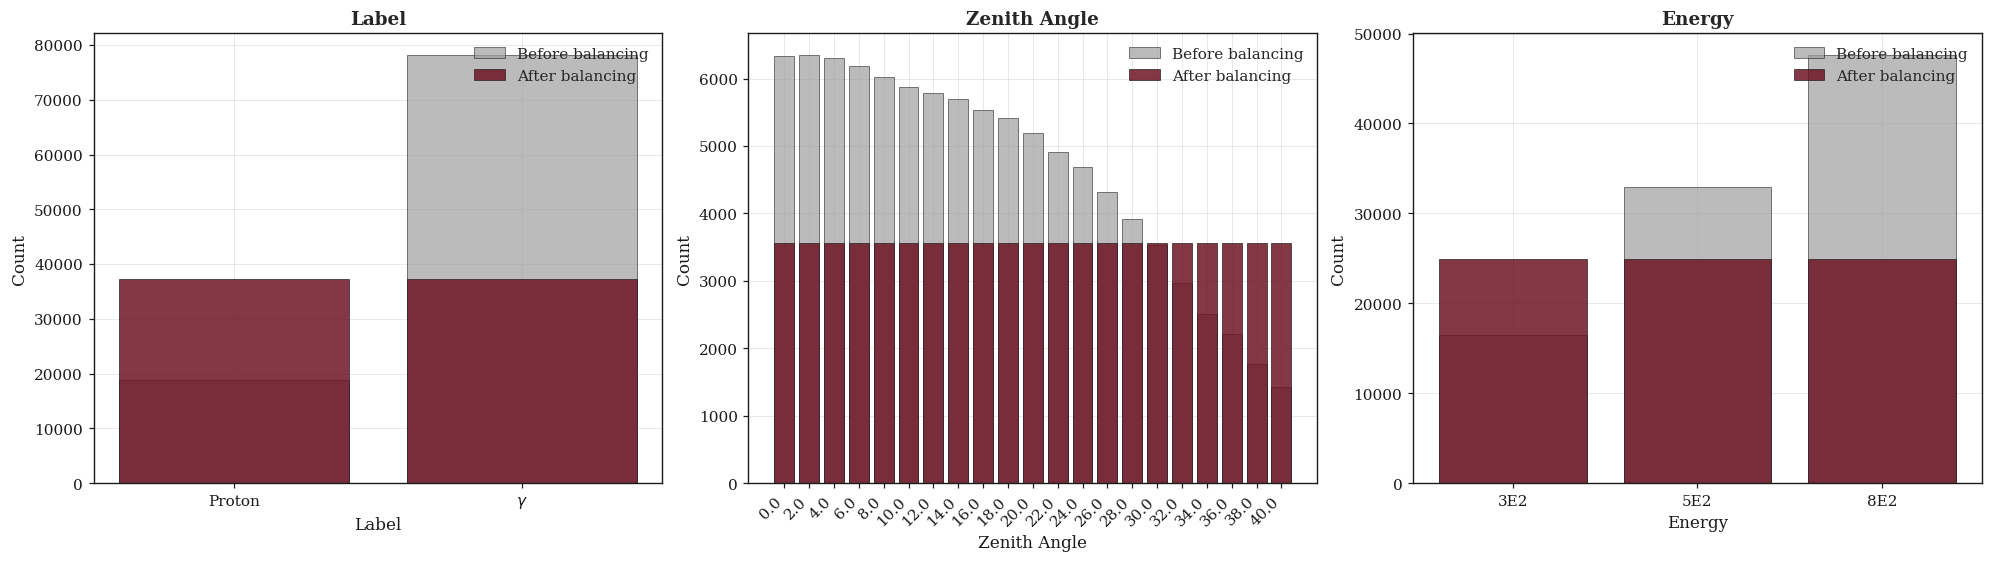

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

features = ["label", "angle", "energy"]
titles   = ["Label", "Zenith Angle", "Energy"]

for col_idx, (feature, title) in enumerate(zip(features, titles)):
    ax = axes[col_idx]

    counts_before = df_full[feature].value_counts().sort_index()
    counts_after  = df_balanced[feature].value_counts().sort_index()

    idx = counts_before.index.union(counts_after.index)
    counts_before = counts_before.reindex(idx, fill_value=0)
    counts_after  = counts_after.reindex(idx, fill_value=0)

    x = np.arange(len(idx))

    ax.bar(x, counts_before.values,
           color=CONDOR_GRAY, alpha=0.70,
           edgecolor=CONDOR_INK, linewidth=0.5,
           label="Before balancing", zorder=1)
    ax.bar(x, counts_after.values,
           color=CONDOR_DARKRED, alpha=0.85,
           edgecolor=CONDOR_INK, linewidth=0.5,
           label="After balancing", zorder=2)

    if feature == "label":
        tick_labels = ["Proton" if v == 0 else r"$\gamma$" for v in idx]
        rot, ha = 0, "center"
    elif feature == "energy":
        tick_labels = [str(v) for v in idx]
        rot, ha = 0, "center"
    else:
        tick_labels = [str(v) for v in idx]
        rot, ha = 45, "right"

    ax.set_xticks(x)
    ax.set_xticklabels(tick_labels, rotation=rot, ha=ha)
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel("Count")
    ax.legend(loc="upper right")

fig.savefig(plots_dir / "distribution_checks.png", dpi=SAVE_DPI)
plt.show()

In [10]:
def balance_summary(df_pre, df_post):
    label_map = {0: "Photon", 1: "Proton"}
    def agregar_tabla(df, nombre):
        tabla = (
            df.assign(label=df["label"].map(label_map))
            .groupby(["energy", "label", "angle"])
            .size()
            .unstack("angle", fill_value=0)
        )
        tabla["Total"] = tabla.sum(axis=1)
        tabla["Set"] = nombre
        return tabla.reset_index()
    tabla_pre = agregar_tabla(df_pre, "Before")
    tabla_post = agregar_tabla(df_post, "After")
    tabla_final = pd.concat([tabla_pre, tabla_post], ignore_index=True)
    display(tabla_final)

balance_summary(df_full, df_balanced)


angle,energy,label,0.0,2.0,4.0,6.0,8.0,10.0,12.0,14.0,...,26.0,28.0,30.0,32.0,34.0,36.0,38.0,40.0,Total,Set
0,3E2,Photon,179,168,150,154,112,129,130,143,...,78,63,64,38,36,30,31,19,1958,Before
1,3E2,Proton,1174,1136,1118,1071,1087,1045,979,935,...,513,415,364,287,223,197,124,90,14474,Before
2,5E2,Photon,449,369,344,371,316,307,261,310,...,233,229,153,161,103,116,101,85,5306,Before
3,5E2,Proton,1844,1845,1843,1812,1807,1785,1752,1683,...,1226,1075,961,721,634,526,399,287,27611,Before
4,8E2,Photon,706,847,866,796,713,627,690,651,...,460,394,356,332,242,249,216,214,11496,Before
5,8E2,Proton,1987,1988,1991,1986,1994,1986,1980,1979,...,1810,1740,1636,1425,1278,1091,895,725,36143,Before
6,3E2,Photon,593,593,593,593,593,593,593,593,...,593,593,593,593,593,593,593,593,12453,After
7,3E2,Proton,593,593,593,593,593,593,593,593,...,593,593,593,593,593,593,593,593,12453,After
8,5E2,Photon,593,593,593,593,593,593,593,593,...,593,593,593,593,593,593,593,593,12453,After
9,5E2,Proton,593,593,593,593,593,593,593,593,...,593,593,593,593,593,593,593,593,12453,After


### Sequence Features
- Time-ordered hits: detector_id, particle_count, t_bin, total_energy, x_center, y_center.
- Sorted by t_bin; padded sequences.

In [11]:
def build_sequence_list(df: pd.DataFrame) -> list[np.ndarray]:
    sequences = []
    for seq in df["shower_data"]:
        arr = np.asarray(seq, dtype=np.float32)
        if arr.size == 0:
            sequences.append(np.zeros((0, len(FEATURE_ORDER)), dtype=np.float32))
            continue
        order = np.argsort(arr[:, CORSIKA_COLS["t_bin"]])
        ordered = arr[order][:, FEATURE_ORDER].astype(np.float32)
        sequences.append(ordered)
    return sequences

X_sequences = build_sequence_list(df_balanced)
angles = df_balanced["angle"].to_numpy(dtype=np.float32)
labels = df_balanced["label"].to_numpy(dtype=np.int32)
energies = df_balanced["energy"].to_numpy()

### Global Features
- Total particles, total energy, active detectors, duration, central energy (inner detectors).
- Central IDs: 16 central detectors.

In [12]:
detector_catalog["distance"] = np.hypot(detector_catalog["x_center"], detector_catalog["y_center"])
central_ids = detector_catalog.nsmallest(16, "distance")["detector_id"].astype(int).tolist()

def compute_global_features(sequences: list[np.ndarray], central_detectors: list[int]) -> np.ndarray:
    central_detectors = np.array(central_detectors, dtype=np.int32)
    features = np.zeros((len(sequences), 5), dtype=np.float32)
    for idx, seq in enumerate(sequences):
        if seq.size == 0:
            continue
        det_ids = seq[:, 0].astype(np.int32)
        particle_counts = seq[:, 1]
        t_bins = seq[:, 2]
        tot_energy = seq[:, 3]

        total_particles = float(particle_counts.sum())
        total_energy = float(tot_energy.sum())
        active_detectors = float(np.unique(det_ids).size)
        duration = float(t_bins.max() - t_bins.min())
        mask_central = np.isin(det_ids, central_detectors)
        energy_central = float(tot_energy[mask_central].sum()) if np.any(mask_central) else 0.0

        features[idx] = [
            total_particles,
            total_energy,
            active_detectors,
            duration,
            energy_central,
        ]
    return features

X_global = compute_global_features(X_sequences, central_ids)
X_padded = pad_sequences(X_sequences, padding="post", dtype="float32")
max_sequence_length = int(X_padded.shape[1])

### Stratified Split
- 70/15/15 stratified on (angle, label).
- Energy both categorical (bins) and continuous (scaled).
- Record means/std for scaling.

In [13]:
indices = np.arange(len(X_padded))
strata = np.array([f"{int(round(a))}_{lbl}" for a, lbl in zip(angles, labels)])

train_idx, temp_idx = train_test_split(
    indices,
    test_size=1.0 - TRAIN_RATIO,
    stratify=strata,
    random_state=SEED,
    shuffle=True,
)

val_fraction = VAL_RATIO / (1.0 - TRAIN_RATIO)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=1.0 - val_fraction,
    stratify=strata[temp_idx],
    random_state=SEED,
    shuffle=True,
)

def split_arrays(arr: np.ndarray, tr: np.ndarray, va: np.ndarray, te: np.ndarray):
    return arr[tr], arr[va], arr[te]

X_train, X_val, X_test = split_arrays(X_padded, train_idx, val_idx, test_idx)
Xg_train, Xg_val, Xg_test = split_arrays(X_global, train_idx, val_idx, test_idx)
y_angle_train, y_angle_val, y_angle_test = split_arrays(angles, train_idx, val_idx, test_idx)
y_label_train, y_label_val, y_label_test = split_arrays(labels, train_idx, val_idx, test_idx)
y_energy_train, y_energy_val, y_energy_test = split_arrays(energies, train_idx, val_idx, test_idx)

energy_levels = sorted({e for e in df_balanced["energy"]}, key=lambda x: float(x.replace("E", "e")))
energy_to_idx = {e: idx for idx, e in enumerate(energy_levels)}
y_energy_train_cls = np.array([energy_to_idx[e] for e in y_energy_train], dtype=np.int32)
y_energy_val_cls = np.array([energy_to_idx[e] for e in y_energy_val], dtype=np.int32)
y_energy_test_cls = np.array([energy_to_idx[e] for e in y_energy_test], dtype=np.int32)

def parse_energy(arr: np.ndarray) -> np.ndarray:
    return np.array([float(s.replace("E", "e")) for s in arr], dtype=np.float32)

y_energy_train_cont = parse_energy(y_energy_train)
y_energy_val_cont = parse_energy(y_energy_val)
y_energy_test_cont = parse_energy(y_energy_test)

energy_mean = float(y_energy_train_cont.mean())
energy_std = float(y_energy_train_cont.std(ddof=0) + 1e-8)
y_energy_train_scaled = (y_energy_train_cont - energy_mean) / energy_std
y_energy_val_scaled = (y_energy_val_cont - energy_mean) / energy_std
y_energy_test_scaled = (y_energy_test_cont - energy_mean) / energy_std

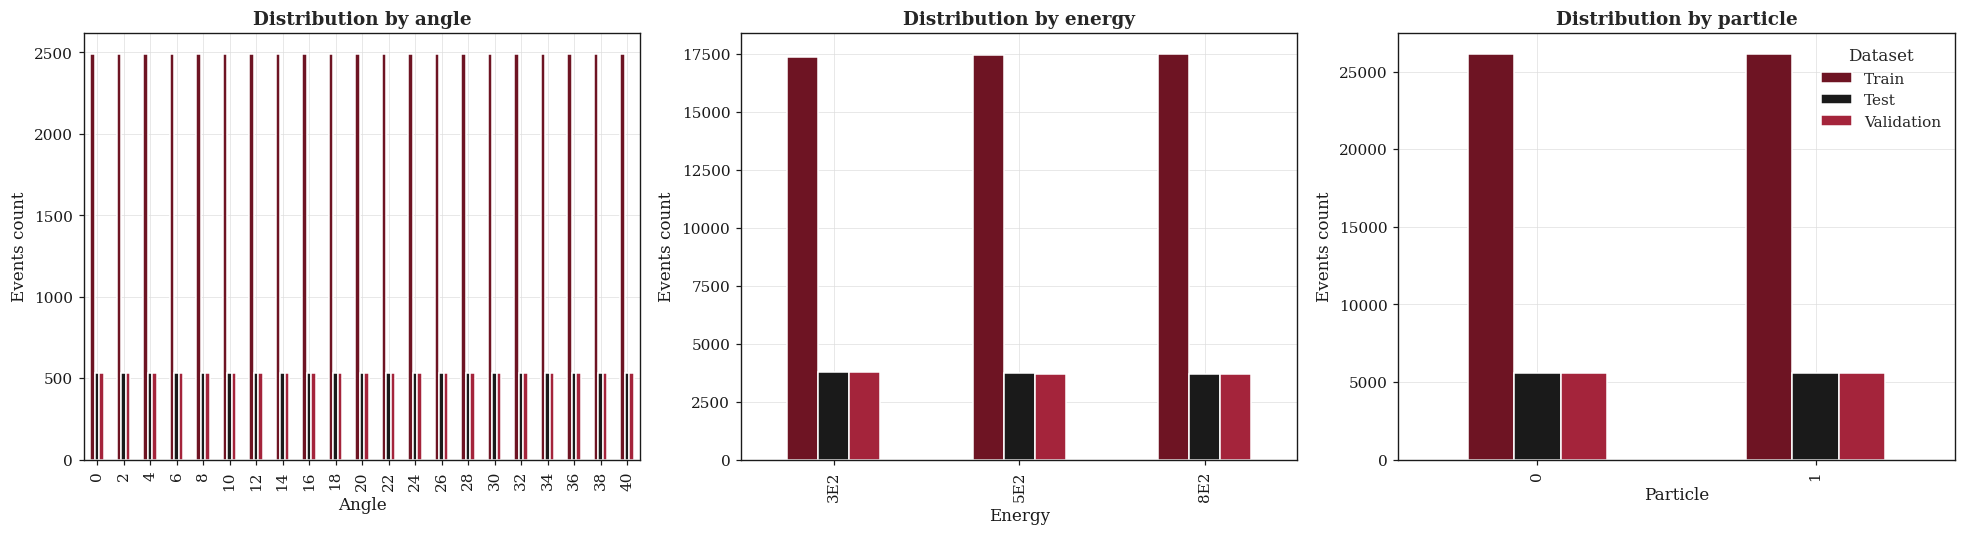

In [14]:
datasets = [
    ("Train", y_angle_train, y_energy_train, y_label_train),
    ("Validation", y_angle_val, y_energy_val, y_label_val),
    ("Test", y_angle_test, y_energy_test, y_label_test),
]

frames = []
for name, angle_arr, energy_arr, particle_arr in datasets:
    frames.append(
        pd.DataFrame(
            {
                "dataset": name,
                "angle": angle_arr.astype(int),
                "energy": energy_arr,
                "particle": particle_arr.astype(int),
            }
        )
    )

dist_df = pd.concat(frames, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plots = [
    ("angle", "Distribution by angle"),
    ("energy", "Distribution by energy"),
    ("particle", "Distribution by particle"),
]

order = ["Train", "Test", "Validation"]

for i, (ax, (feature, title)) in enumerate(zip(axes, plots)):
    counts = (
        dist_df.groupby(["dataset", feature])
        .size()
        .unstack("dataset", fill_value=0)
        .sort_index()
    )
    counts = counts[order]  # Reorder columns
    counts.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(feature.capitalize())
    ax.set_ylabel("Events count")
    if i == 2:
        ax.legend(title="Dataset")
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()

In [15]:
# Create a list with energy levels and dataset names
sets = ["Train", "Validation", "Test"]

# Create a list with energy-type combinations
energy_types = []
for energy in energy_levels:
    for label in [0, 1]:
        tipo = "Photon" if label == 0 else "Proton"
        energy_types.append(f"{energy}-{tipo}")

# Initialize the counts dictionary
table_dict = {set_name: [] for set_name in sets}
totals = []

for set_name, angle_arr, energy_arr, label_arr in datasets:
    row = []
    for energy in energy_levels:
        for label in [0, 1]:
            count = ((energy_arr == energy) & (label_arr == label)).sum()
            row.append(count)
    total = sum(row)
    table_dict[set_name] = row + [total]
    totals.append(total)

# Construct and display the final table
columns = energy_types + ["Total"]
tabla = pd.DataFrame([table_dict[set_name] for set_name in sets], columns=columns, index=sets)
display(tabla)

,3E2-Photon,3E2-Proton,5E2-Photon,5E2-Proton,8E2-Photon,8E2-Proton,Total
Train,8678,8684,8728,8718,8745,8749,52302
Validation,1892,1894,1838,1875,1872,1836,11207
Test,1883,1875,1887,1860,1836,1868,11209


## 2. Model
### Hybrid CNN-Transformer with Multi-Task Heads
- Shared CNN backbone: 3× Conv1D(128, k=7) + BN + ELU → MaxPool(2) → Dense(128→256→128).
- 6 Transformer streams: 3 on CNN output (high-level features) + 3 on raw sequence (interpretable).
- Per-task fusion: `concat(GAP_cnn[128], GAP_raw[6], global[5]) = 139 dims`.
- Heads: particle (sigmoid/BCE), angle (linear/Huber), energy (linear/Huber).
- Single attention head per stream (d_k=32) for direct interpretability.

In [16]:
model_dir = ARTIFACTS_DIR / "model"
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "condor_multitask_model.keras"

In [17]:
from tensorflow.keras.metrics import Metric

def build_multitask_model(sequence_shape: tuple[int, int], global_dim: int, include_attention_outputs: bool = False) -> Model:
    seq_input = Input(shape=sequence_shape, name="seq_input")
    global_input = Input(shape=(global_dim,), name="global_input")

    # Masked sequence (raw)
    x_raw = layers.Masking(mask_value=0.0, name="masking")(seq_input)

    # CNN branch (same as before, operating on raw)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_0")(x_raw)
    x_cnn = layers.BatchNormalization(name="bn_0")(x_cnn)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_1")(x_cnn)
    x_cnn = layers.BatchNormalization(name="bn_1")(x_cnn)
    x_cnn = layers.Conv1D(128, 7, padding="same", activation="elu", name="conv_2")(x_cnn)
    x_cnn = layers.BatchNormalization(name="bn_2")(x_cnn)
    x_cnn = layers.MaxPooling1D(pool_size=2, padding="same", name="pool_2")(x_cnn)
    x_cnn = layers.Dense(128, activation="elu", name="dense_after_cnn1")(x_cnn)
    x_cnn = layers.Dense(256, activation="elu", name="dense_after_cnn2")(x_cnn)
    x_cnn = layers.Dropout(0.40, name="dropout_after_cnn")(x_cnn)
    x_cnn = layers.Dense(128, activation="elu", name="dense_after_cnn4")(x_cnn)

    attention_recorders = []
    attention_tap_names = {}

    def transformer_block(x: tf.Tensor, prefix: str) -> tuple[tf.Tensor, tf.Tensor]:
        x_norm = layers.LayerNormalization(name=f"pre_mha_norm_{prefix}")(x)
        mha_layer = layers.MultiHeadAttention(num_heads=1, key_dim=32, name=f"mha_{prefix}")
        attn_output, attn_scores = mha_layer(x_norm, x_norm, return_attention_scores=True)
        recorder = layers.Lambda(lambda s: s, name=f"attention_scores_{prefix}")(attn_scores)
        attention_tap_names[prefix] = recorder.name
        attention_recorders.append(recorder)
        x_add = layers.Add(name=f"add_{prefix}")([x, attn_output])
        x_norm_ffn = layers.LayerNormalization(name=f"pre_ffn_norm_{prefix}")(x_add)
        ffn = layers.Dense(128, activation="elu", name=f"ffn_dense_{prefix}1")(x_norm_ffn)
        ffn = layers.Dense(x.shape[-1], name=f"ffn_dense_{prefix}2")(ffn)
        x_out = layers.Add(name=f"ffn_add_{prefix}")([x_add, ffn])
        pooled = layers.GlobalAveragePooling1D(name=f"temporal_pooling_{prefix}")(x_out)
        return pooled, recorder

    # Transformers on CNN output
    feat_angle_cnn, attn_angle_cnn = transformer_block(x_cnn, "angle_cnn")
    feat_particle_cnn, attn_class_cnn = transformer_block(x_cnn, "class_cnn")
    feat_energy_cnn, attn_energy_cnn = transformer_block(x_cnn, "energy_cnn")

    # Transformers on raw sequence (without convolution)
    feat_angle_raw, attn_angle_raw = transformer_block(x_raw, "angle_raw")
    feat_particle_raw, attn_class_raw = transformer_block(x_raw, "class_raw")
    feat_energy_raw, attn_energy_raw = transformer_block(x_raw, "energy_raw")

    # Fuse attention features CNN + raw
    feat_angle = layers.Concatenate(name="feat_angle_fused")([feat_angle_cnn, feat_angle_raw])
    feat_particle = layers.Concatenate(name="feat_particle_fused")([feat_particle_cnn, feat_particle_raw])
    feat_energy = layers.Concatenate(name="feat_energy_fused")([feat_energy_cnn, feat_energy_raw])

    merged_angle = layers.Concatenate(name="merge_angle")([feat_angle, global_input])
    merged_particle = layers.Concatenate(name="merge_particle")([feat_particle, global_input])
    merged_energy = layers.Concatenate(name="merge_energy")([feat_energy, global_input])

    class_branch = layers.Dropout(0.35, name="dropout_particle")(merged_particle)
    class_branch = layers.Dense(128, activation="elu", name="dense_particle")(class_branch)
    particle_out = layers.Dense(1, activation="sigmoid", dtype="float32", name="particle_output")(class_branch)

    angle_branch = layers.Dense(128, activation="elu", name="dense_angle")(merged_angle)
    angle_out = layers.Dense(1, activation="linear", dtype="float32", name="angle_output")(angle_branch)

    energy_branch = layers.Dense(128, activation="elu", name="dense_energy")(merged_energy)
    energy_branch = layers.Dropout(0.50, name="dropout_energy")(energy_branch)
    energy_out = layers.Dense(1, activation="linear", dtype="float32", name="energy_output")(energy_branch)

    outputs = [particle_out, angle_out, energy_out]
    if include_attention_outputs:
        outputs.extend([
            attn_class_cnn, attn_angle_cnn, attn_energy_cnn,
            attn_class_raw, attn_angle_raw, attn_energy_raw,
        ])

    model = Model(inputs=[seq_input, global_input], outputs=outputs, name="CONDOR_Multitask")
    optimizer = optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)

    model.attention_recorders = {
        logical: model.get_layer(layer_name)
        for logical, layer_name in attention_tap_names.items()
        if layer_name in [layer.name for layer in model.layers]
    }
    model.attention_layer_names = attention_tap_names

    class F1Score(Metric):
        def __init__(self, name="f1_score", threshold=0.5, **kwargs):
            super().__init__(name=name, **kwargs)
            self.threshold = threshold
            self.tp = self.add_weight(name="tp", initializer="zeros")
            self.fp = self.add_weight(name="fp", initializer="zeros")
            self.fn = self.add_weight(name="fn", initializer="zeros")

        def update_state(self, y_true, y_pred, sample_weight=None):
            y_pred = tf.cast(y_pred > self.threshold, tf.float32)
            y_true = tf.cast(y_true, tf.float32)
            tp = tf.reduce_sum(y_true * y_pred)
            fp = tf.reduce_sum((1 - y_true) * y_pred)
            fn = tf.reduce_sum(y_true * (1 - y_pred))
            self.tp.assign_add(tp)
            self.fp.assign_add(fp)
            self.fn.assign_add(fn)

        def result(self):
            precision = self.tp / (self.tp + self.fp + tf.keras.backend.epsilon())
            recall = self.tp / (self.tp + self.fn + tf.keras.backend.epsilon())
            return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

        def reset_state(self):
            self.tp.assign(0)
            self.fp.assign(0)
            self.fn.assign(0)

    # Compile
    model.compile(
        optimizer=optimizer,
        loss={
            "particle_output": "binary_crossentropy",
            "angle_output": tf.keras.losses.Huber(),
            "energy_output": tf.keras.losses.Huber(),
        },
        loss_weights={
            "particle_output": 0.6,
            "angle_output": 1.0,
            "energy_output": 1.5,
        },
        metrics={
            "particle_output": [F1Score(name="f1_score")],
            "angle_output": "mae",
            "energy_output": "mae",
        },
    )
    return model

with strategy.scope():
    model = build_multitask_model(
        sequence_shape=(max_sequence_length, len(FEATURE_NAMES)),
        global_dim=Xg_train.shape[1]
    )
model.summary()

Model: "CONDOR_Multitask"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 seq_input (InputLayer)         [(None, 472, 6)]     0           []                               
                                                                                                  
 masking (Masking)              (None, 472, 6)       0           ['seq_input[0][0]']              
                                                                                                  
 conv_0 (Conv1D)                (None, 472, 128)     5504        ['masking[0][0]']                
                                                                                                  
 bn_0 (BatchNormalization)      (None, 472, 128)     512         ['conv_0[0][0]']                 
                                                                                   

### Training Protocol
- **Losses:** BCE (particle, $\lambda=0.6$), Huber (angle, $\lambda=1.0$), Huber (energy, $\lambda=1.5$).
- **Optimizer:** Adam (lr=5×10⁻⁴, clipnorm=1.0).
- **Callbacks:** EarlyStopping (patience=15, restore best), ReduceLROnPlateau (patience=7, factor=0.5).
- **Persistence:** Set `FORCE_RETRAIN = False` to skip training if a saved model exists.

In [ ]:
# ----------------------------- #
# Training                      #
# ----------------------------- #
# Set True if you changed the model architecture in this session
FORCE_RETRAIN = False

if model_path.exists() and not FORCE_RETRAIN:
    print(f"Saved model found at: {model_path}")
    print("Skipping training. Set FORCE_RETRAIN = True to retrain.")
    TRAINED_THIS_SESSION = False  # weights NOT in memory — must load from disk
else:
    callbacks_list = [
        callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, verbose=1, min_lr=1e-6),
    ]

    history = model.fit(
        x=[X_train, Xg_train],
        y=[y_label_train, y_angle_train, y_energy_train_scaled],
        validation_data=([X_val, Xg_val], [y_label_val, y_angle_val, y_energy_val_scaled]),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks_list,
        verbose=1,
    )

    model.save(model_path)
    model.save_weights(model_dir / "condor_multitask.weights.h5")
    TRAINED_THIS_SESSION = True  # weights ARE in memory and up-to-date
    print(f"Model saved at: {model_path}")

Epoch 1/100
1635/1635 [==============================] - 157s 85ms/step - loss: 3.8348 - particle_output_loss: 0.5284 - angle_output_loss: 1.8127 - energy_output_loss: 1.1367 - particle_output_f1_score: 0.7967 - angle_output_mae: 2.2504 - energy_output_mae: 1.5412 - val_loss: 2.0603 - val_particle_output_loss: 0.3913 - val_angle_output_loss: 1.2262 - val_energy_output_loss: 0.3996 - val_particle_output_f1_score: 0.8724 - val_angle_output_mae: 1.6570 - val_energy_output_mae: 0.7785 - lr: 5.0000e-04
Epoch 2/100
1635/1635 [==============================] - 142s 87ms/step - loss: 1.8316 - particle_output_loss: 0.3321 - angle_output_loss: 1.0009 - energy_output_loss: 0.4209 - particle_output_f1_score: 0.8755 - angle_output_mae: 1.4161 - energy_output_mae: 0.7985 - val_loss: 2.3355 - val_particle_output_loss: 0.2299 - val_angle_output_loss: 1.6114 - val_energy_output_loss: 0.3908 - val_particle_output_f1_score: 0.9252 - val_angle_output_mae: 2.0505 - val_energy_output_mae: 0.7637 - lr: 5.000

### Training Curves

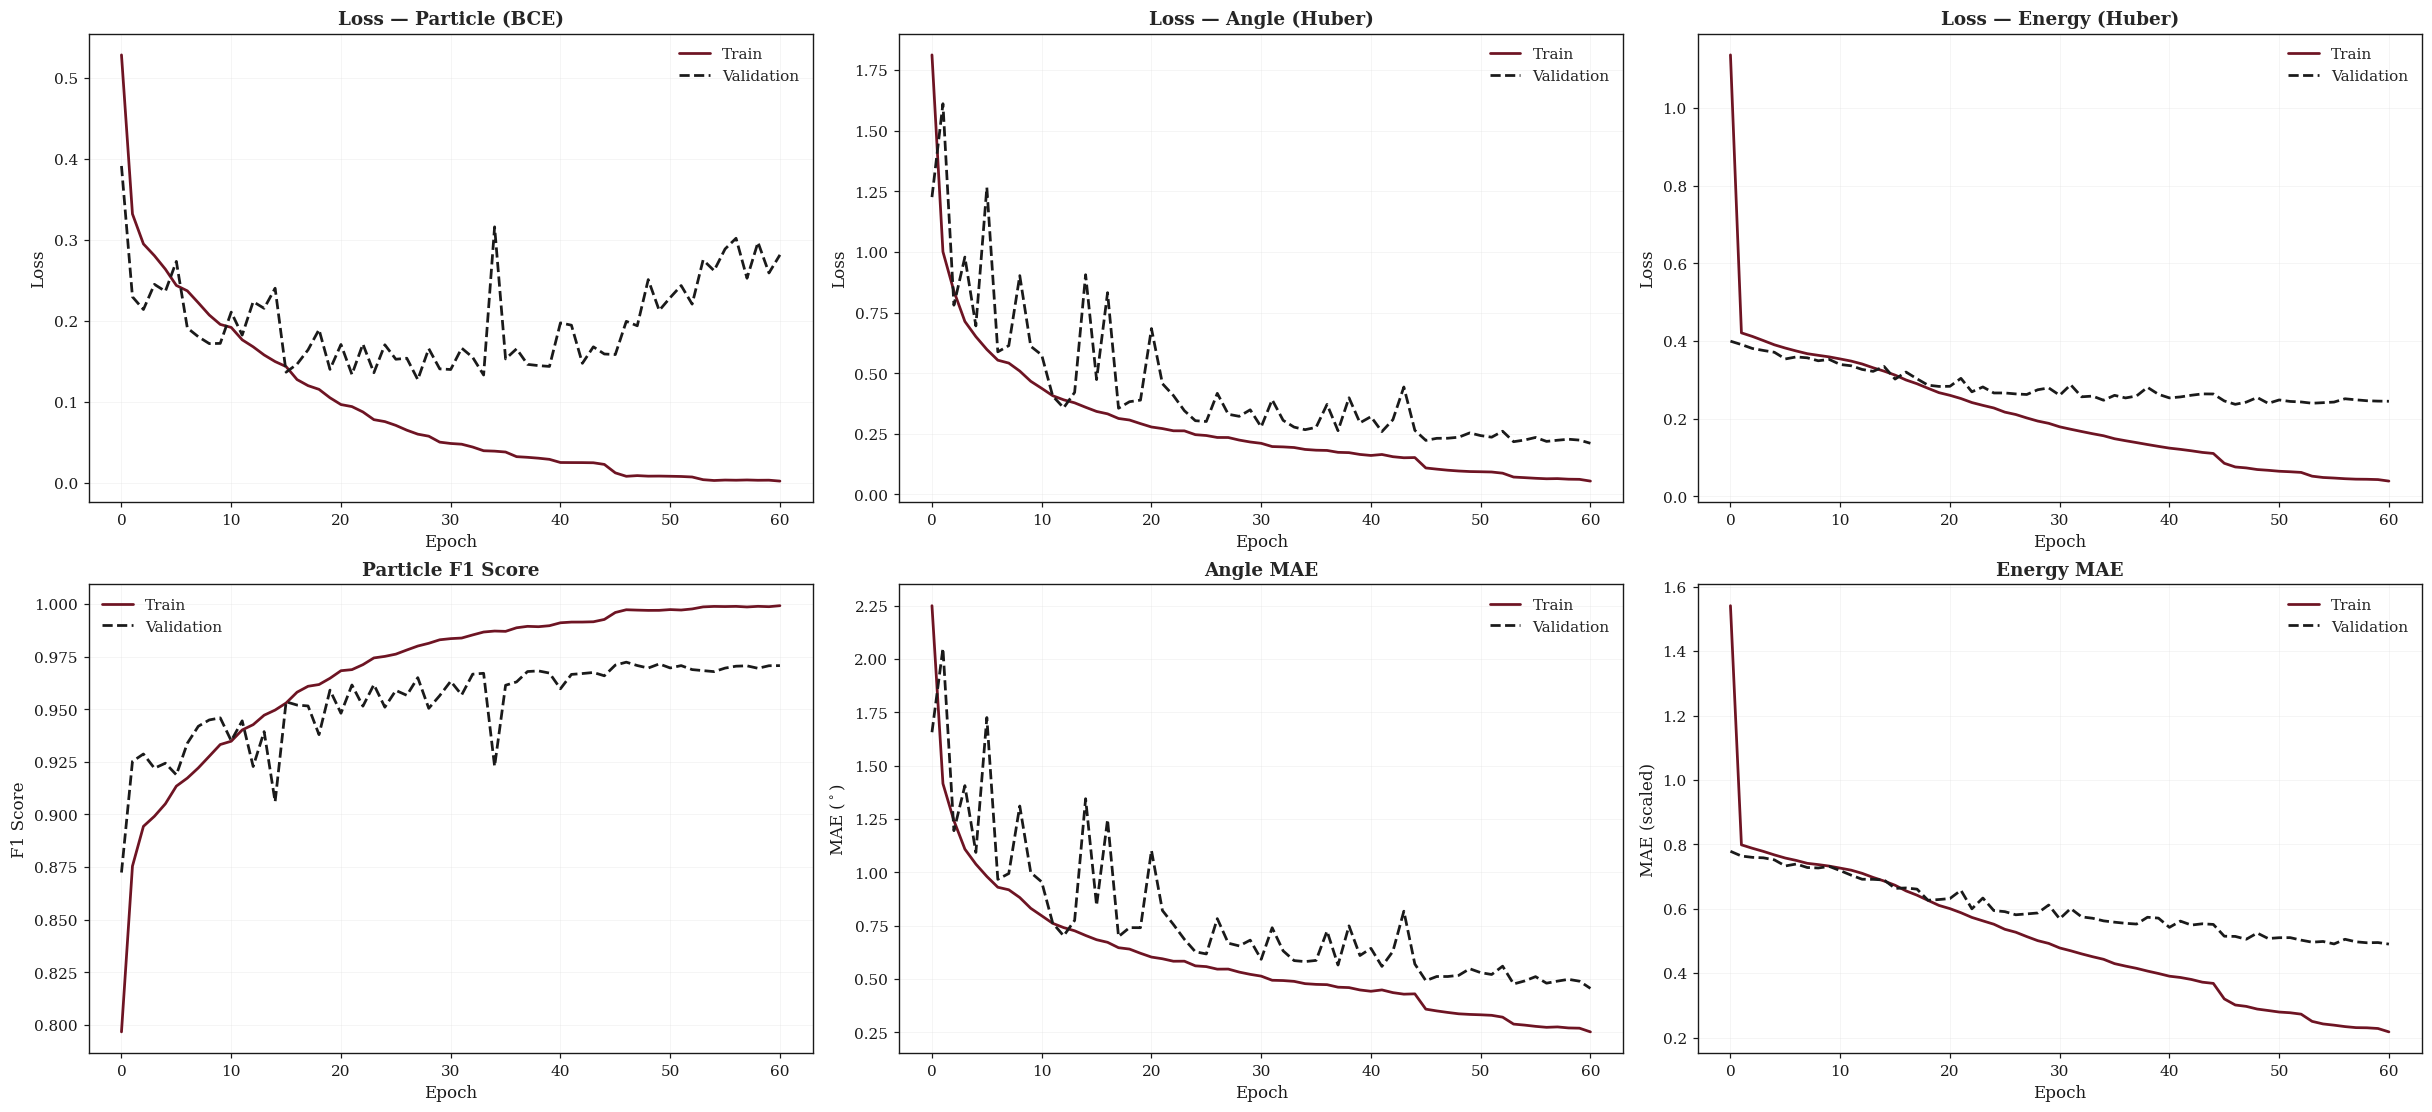

In [19]:
history_csv_path = model_dir / "training_history.csv"

if "history" not in globals() or history is None:
    if history_csv_path.exists():
        history_df = pd.read_csv(history_csv_path)
        expected_cols = {"particle_output_loss", "val_particle_output_loss"}
        if not expected_cols.issubset(history_df.columns):
            raise ValueError(f"History CSV missing expected columns. Found: {list(history_df.columns)[:5]}...")
        class HistoryObj:
            def __init__(self, df):
                self.history = {col: df[col].values for col in df.columns}
        history = HistoryObj(history_df)
        TRAINED_THIS_SESSION = False  # loaded from disk — weights must be loaded separately
        print(f"Training history loaded from: {history_csv_path}")
    else:
        raise FileNotFoundError(f"Training history not found at {history_csv_path}")

fig, axes = plt.subplots(2, 3, figsize=(22, 10), constrained_layout=True)

loss_cols = ["particle_output_loss", "angle_output_loss", "energy_output_loss"]
loss_titles = ["Particle (BCE)", "Angle (Huber)", "Energy (Huber)"]
metric_cols = ["particle_output_f1_score", "angle_output_mae", "energy_output_mae"]
metric_titles = ["Particle F1 Score", "Angle MAE", "Energy MAE"]
metric_ylabels = ["F1 Score", r"MAE ($^\circ$)", "MAE (scaled)"]

for j, (col, title) in enumerate(zip(loss_cols, loss_titles)):
    axes[0, j].plot(history.history[col], label="Train", color=CONDOR_DARKRED)
    axes[0, j].plot(history.history[f"val_{col}"], label="Validation", color=CONDOR_INK, ls="--")
    axes[0, j].set_title(f"Loss — {title}")
    axes[0, j].set_ylabel("Loss")
    axes[0, j].set_xlabel("Epoch")
    axes[0, j].grid(alpha=0.3)
    axes[0, j].legend()

for j, (col, title, ylabel) in enumerate(zip(metric_cols, metric_titles, metric_ylabels)):
    axes[1, j].plot(history.history[col], label="Train", color=CONDOR_DARKRED)
    axes[1, j].plot(history.history[f"val_{col}"], label="Validation", color=CONDOR_INK, ls="--")
    axes[1, j].set_title(title)
    axes[1, j].set_ylabel(ylabel)
    axes[1, j].set_xlabel("Epoch")
    axes[1, j].grid(alpha=0.3)
    axes[1, j].legend()

fig.savefig(plots_dir / "training_curves.png", dpi=SAVE_DPI)
plt.show()

In [20]:
def attach_attention_recorders(m):
    tap_names = {
        "angle_raw": "attention_scores_angle",
        "particle_raw": "attention_scores_class",
        "energy_raw": "attention_scores_energy",
    }
    m.attention_layer_names = tap_names
    m.attention_recorders = {
        logical: m.get_layer(layer_name)
        for logical, layer_name in tap_names.items()
        if any(layer.name == layer_name for layer in m.layers)
    }

# TRAINED_THIS_SESSION=True only when model.fit() ran in this session.
# Checking 'history' in globals is NOT sufficient: the training-curves cell sets
# history from the CSV even when training was skipped, making 'history in globals'
# true while the model still carries random weights.
use_in_memory_model = (
    "model" in globals() and model is not None
    and globals().get("TRAINED_THIS_SESSION", False)
)

if use_in_memory_model:
    print("Model in memory detected; keeping the trained model.")
    attach_attention_recorders(model)
else:
    if not model_path.exists():
        raise FileNotFoundError(f"Model not found at {model_path}")
    model = tf.keras.models.load_model(
        model_path,
        custom_objects={"F1Score": F1Score},
    )
    attach_attention_recorders(model)
    print(f"Model loaded from: {model_path}")

Model in memory detected; keeping the trained model.


## 3. Evaluation
### Test Metrics

In [21]:
eval_results = model.evaluate(
    x=[X_test, Xg_test],
    y=[y_label_test, y_angle_test, y_energy_test_scaled],
    verbose=1,
)
metrics_names = model.metrics_names
eval_dict = {name: float(value) for name, value in zip(metrics_names, eval_results)}

pred_particle, pred_angle, pred_energy_scaled = model.predict([X_test, Xg_test], batch_size=BATCH_SIZE, verbose=1)
pred_particle = pred_particle.reshape(-1)
pred_angle = pred_angle.reshape(-1)
pred_energy_scaled = pred_energy_scaled.reshape(-1)
pred_energy_cont = pred_energy_scaled * energy_std + energy_mean

pred_particle_labels = (pred_particle >= 0.5).astype(np.int32)
particle_accuracy = float(np.mean(pred_particle_labels == y_label_test))
angle_mae = float(np.mean(np.abs(pred_angle - y_angle_test)))
energy_mae = float(np.mean(np.abs(pred_energy_cont - y_energy_test_cont)))
energy_rmse = float(np.sqrt(np.mean((pred_energy_cont - y_energy_test_cont) ** 2)))

additional_metrics = {
    "particle_accuracy_custom": particle_accuracy,
    "angle_mae_deg_custom": angle_mae,
    "energy_mae_GeV_custom": energy_mae,
    "energy_rmse_GeV_custom": energy_rmse,
}

351/351 [==============================] - 12s 31ms/step


In [22]:
# ----------------------------- #
# Artifacts                     #
# ----------------------------- #

# Persist attention layer mapping
default_attention_map = {
    "angle_raw": "attention_scores_angle",
    "particle_raw": "attention_scores_class",
    "energy_raw": "attention_scores_energy",
}
attention_map = getattr(model, "attention_layer_names", None) or default_attention_map
attention_json = model_dir / "attention_layers.json"
with attention_json.open("w", encoding="utf-8") as fh:
    json.dump(attention_map, fh, indent=2)
print(f"Attention layer mapping saved to: {attention_json}")


history_df = pd.DataFrame(history.history)
history_csv = model_dir / "training_history.csv"
history_df.to_csv(history_csv, index=False)
print(f"Training history saved to: {history_csv}")

metrics_path = model_dir / "evaluation_metrics.json"
with metrics_path.open("w", encoding="utf-8") as fh:
    json.dump(
        {"keras_metrics": eval_dict, "custom_metrics": additional_metrics},
        fh,
        indent=2,
    )
print(f"Basic metrics saved to: {metrics_path}")

pred_npz_path = ARTIFACTS_DIR / "test_predictions.npz"
np.savez_compressed(
    pred_npz_path,
    particle_probability=pred_particle.astype(np.float32),
    particle_label_pred=pred_particle_labels,
    particle_label_true=y_label_test,
    angle_pred=pred_angle.astype(np.float32),
    angle_true=y_angle_test,
    energy_pred_scaled=pred_energy_scaled.astype(np.float32),
    energy_pred=pred_energy_cont.astype(np.float32),
    energy_true=y_energy_test_cont,
    energy_true_str=np.array(y_energy_test, dtype="<U8"),
    energy_levels=np.array(energy_levels, dtype="<U8"),
    energy_mean=np.array([energy_mean], dtype=np.float32),
    energy_std=np.array([energy_std], dtype=np.float32),
)
print(f"Test predictions saved to: {pred_npz_path}")

Attention layer mapping saved to: pipeline_artifacts\model\attention_layers.json
Training history saved to: pipeline_artifacts\model\training_history.csv
Basic metrics saved to: pipeline_artifacts\model\evaluation_metrics.json
Test predictions saved to: pipeline_artifacts\test_predictions.npz


In [23]:
metadata = {
    "seed": SEED,
    "energies_used": list(ENERGY_FILTER),
    "angle_max_deg": ANGLE_MAX,
    "min_total_particles": MIN_TOTAL_PARTICLES,
    "balance_target_per_group": target_per_group,
    "num_events_total": int(len(df_balanced)),
    "train_val_test_split": {
        "train": int(len(train_idx)),
        "val": int(len(val_idx)),
        "test": int(len(test_idx)),
    },
    "feature_order": FEATURE_NAMES,
    "max_sequence_length": max_sequence_length,
    "global_features_definition": [
        "sum_particle_count",
        "sum_total_energy",
        "num_active_detectors",
        "duration_tbin",
        "sum_total_energy_central_ids",
    ],
    "central_detector_ids": [int(x) for x in central_ids],
    "energy_scaling": {"mean": energy_mean, "std": energy_std},
    "artifacts": {
        "dataset_npz": str(pred_npz_path),
        "history_csv": str(history_csv),
        "model_path": str(model_path),
        "metrics_path": str(metrics_path),
        "predictions_npz": str(pred_npz_path),
        "detector_catalog_csv": str(ARTIFACTS_DIR / "detector_catalog.csv"),
    },
    "keras_metrics": eval_dict,
    "custom_metrics": additional_metrics,
}

metadata_path = ARTIFACTS_DIR / "preprocessing_metadata.json"
with metadata_path.open("w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2)
print(f"Metadata saved to: {metadata_path}")

Metadata saved to: pipeline_artifacts\preprocessing_metadata.json


In [24]:
# ----------------------------- #
# Predictions visualization     #
# ----------------------------- #

pred_summary = pd.DataFrame(
    {
        "particle_true": y_label_test.astype(int),
        "particle_pred_prob": pred_particle.astype(float),
        "particle_pred_label": pred_particle_labels.astype(int),
        "angle_true_deg": y_angle_test.astype(float),
        "angle_pred_deg": pred_angle.astype(float),
        "energy_true_GeV": y_energy_test_cont.astype(float),
        "energy_pred_GeV": pred_energy_cont.astype(float),
        "energy_level_true": y_energy_test,
    }
)
pred_summary["angle_error_deg"] = pred_summary["angle_pred_deg"] - pred_summary["angle_true_deg"]
pred_summary["energy_error_GeV"] = pred_summary["energy_pred_GeV"] - pred_summary["energy_true_GeV"]
pred_summary["particle_correct"] = pred_summary["particle_pred_label"] == pred_summary["particle_true"]
pred_summary["angle_abs_error_deg"] = pred_summary["angle_error_deg"].abs()
pred_summary["energy_abs_error_GeV"] = pred_summary["energy_error_GeV"].abs()

angle_metrics = {
    "MAE (deg)": mean_absolute_error(pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]),
    "RMSE (deg)": root_mean_squared_error(pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]),
    "R2": r2_score(pred_summary["angle_true_deg"], pred_summary["angle_pred_deg"]),
}
energy_metrics = {
    "MAE (GeV)": mean_absolute_error(pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]),
    "RMSE (GeV)": root_mean_squared_error(pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]),
    "R2": r2_score(pred_summary["energy_true_GeV"], pred_summary["energy_pred_GeV"]),
}

display(pd.DataFrame(angle_metrics, index=["Angle"]).T.round(4))
display(pd.DataFrame(energy_metrics, index=["Energy"]).T.round(4))

,Angle
MAE (deg),0.4841
RMSE (deg),0.7361
R2,0.9963


,Energy
MAE (GeV),103.7179
RMSE (GeV),151.7955
R2,0.4530


## 4. Results
### 4.1. Gamma/Hadron Discrimination
Confusion matrix, ROC curve, and score distribution for the binary classification task.

,precision,recall,f1-score,support
Proton,0.9712,0.9686,0.9699,5606.0000
$\gamma$,0.9687,0.9713,0.9700,5603.0000
accuracy,0.9699,0.9699,0.9699,0.9699
macro avg,0.9699,0.9699,0.9699,11209.0000
weighted avg,0.9699,0.9699,0.9699,11209.0000


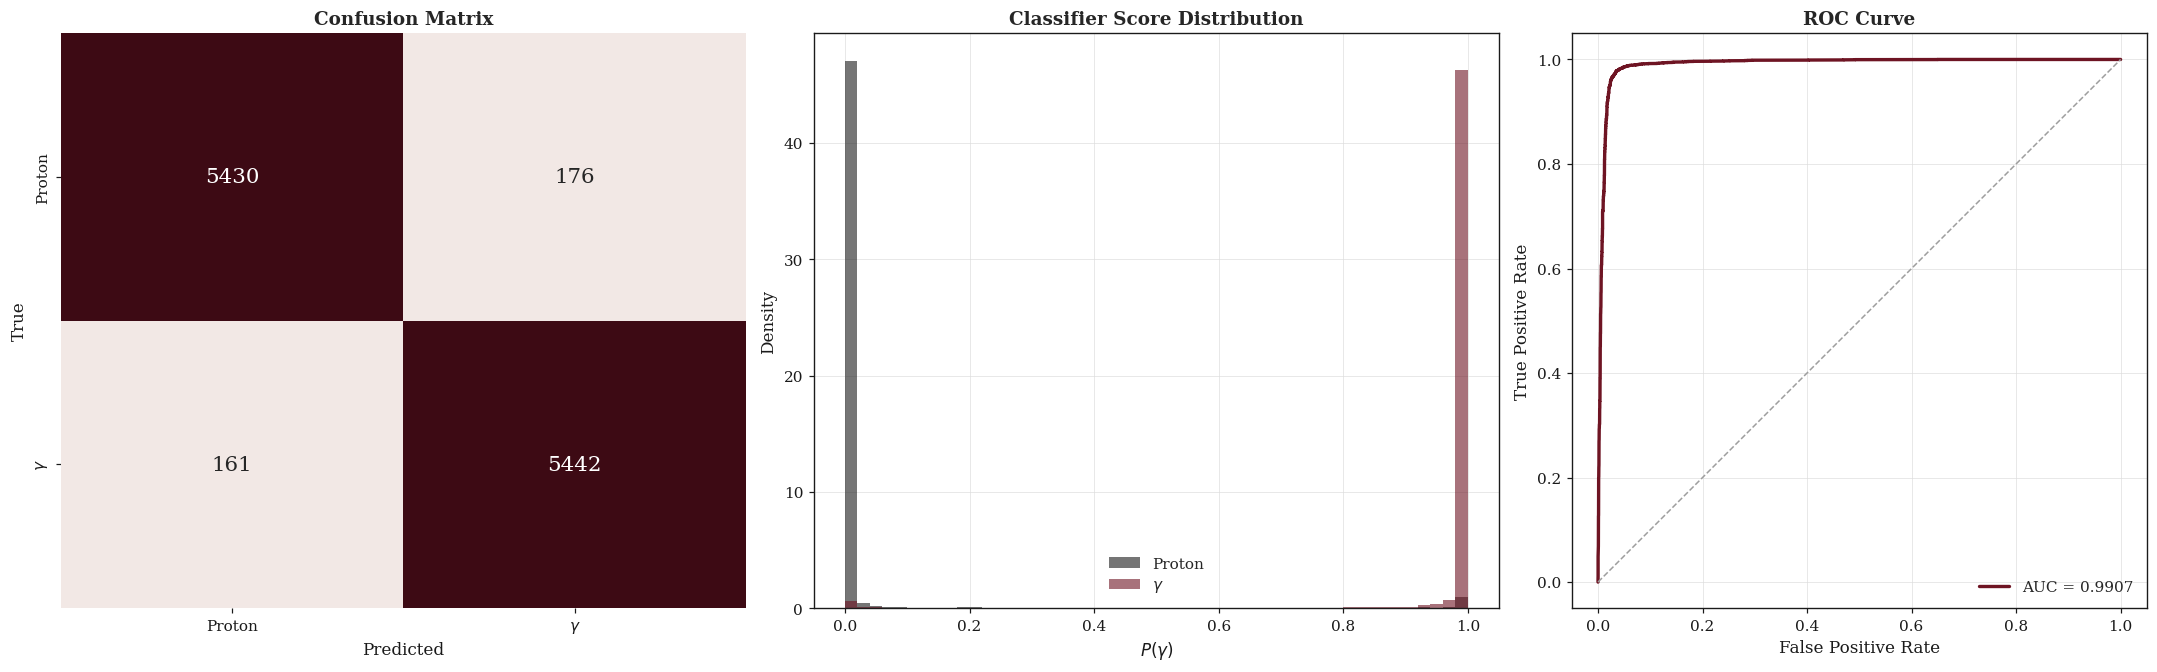

In [25]:
cm_particle = confusion_matrix(pred_summary["particle_true"], pred_summary["particle_pred_label"])
particle_report = classification_report(
    pred_summary["particle_true"],
    pred_summary["particle_pred_label"],
    target_names=["Proton", r"$\gamma$"],
    output_dict=True,
)
display(pd.DataFrame(particle_report).T.round(4))

fpr, tpr, _ = roc_curve(pred_summary["particle_true"], pred_summary["particle_pred_prob"])
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), constrained_layout=True)

# Confusion matrix
sns.heatmap(cm_particle, annot=True, fmt="d", cmap=CMAP_SEQ, cbar=False, ax=axes[0],
            annot_kws={"fontsize": 14})
axes[0].set_xlabel(r"Predicted")
axes[0].set_ylabel(r"True")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticklabels(["Proton", r"$\gamma$"])
axes[0].set_yticklabels(["Proton", r"$\gamma$"])

# Score distribution
for ptype, color, label in [(0, PARTICLE_PALETTE[0], "Proton"), (1, PARTICLE_PALETTE[1], r"$\gamma$")]:
    mask = pred_summary["particle_true"] == ptype
    axes[1].hist(pred_summary.loc[mask, "particle_pred_prob"], bins=50, alpha=0.6,
                 color=color, label=label, edgecolor="none", density=True)
axes[1].set_xlabel(r"$P(\gamma)$")
axes[1].set_ylabel("Density")
axes[1].set_title("Classifier Score Distribution")
axes[1].legend()

# ROC curve
axes[2].plot(fpr, tpr, color=CONDOR_DARKRED, linewidth=2.2, label=f"AUC = {roc_auc:.4f}")
axes[2].plot([0, 1], [0, 1], ls="--", color=CONDOR_GRAY, linewidth=1)
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curve")
axes[2].legend(loc="lower right")
axes[2].set_aspect("equal")

fig.savefig(plots_dir / "particle_results.png", dpi=SAVE_DPI)
plt.show()

In [26]:
# ============================================================
# Q-FACTOR and efficiencies 
# ============================================================

def gamma_hadron_metrics(y_true, y_pred_proba, threshold=0.5):
    """
    Standard metrics in gamma/hadron discrimination:
    - Q-factor: figure of merit
    - Gamma/hadron efficiencies
    - Sample purity
    """
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Assuming: 1=gamma, 0=proton
    gamma_mask = y_true == 1
    proton_mask = y_true == 0
    
    # True Positives, False Positives, etc.
    tp = np.sum((y_pred == 1) & gamma_mask)
    fp = np.sum((y_pred == 1) & proton_mask)
    fn = np.sum((y_pred == 0) & gamma_mask)
    tn = np.sum((y_pred == 0) & proton_mask)
    
    epsilon_gamma = tp / (tp + fn) if (tp + fn) > 0 else 0  # Gamma efficiency
    epsilon_hadron = fp / (fp + tn) if (fp + tn) > 0 else 0  # Hadronic contamination
    
    # Q-factor 
    q_factor = epsilon_gamma / np.sqrt(epsilon_hadron) if epsilon_hadron > 0 else 0
    
    # Gamma sample purity
    purity = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    return {
        'efficiency_gamma': epsilon_gamma,
        'contamination_hadron': epsilon_hadron,
        'q_factor': q_factor,
        'purity_gamma': purity,
        'significance_lima': calculate_lima_significance(tp, fp) 
    }

def calculate_lima_significance(n_on, n_off, alpha=1.0):
    """
    Li & Ma significance (ApJ 272:317-324, 1983)
    Standard in gamma-ray astronomy
    """
    if n_on == 0 or n_off == 0:
        return 0.0
    
    n_on = float(n_on)
    n_off = float(n_off)
    
    term1 = n_on * np.log((1 + alpha) / alpha * (n_on / (n_on + n_off)))
    term2 = n_off * np.log((1 + alpha) * (n_off / (n_on + n_off)))
    
    significance = np.sqrt(2 * (term1 + term2))
    return significance

gh_metrics = gamma_hadron_metrics(
    pred_summary["particle_true"],
    pred_summary["particle_pred_prob"]
)

### 4.2. Zenith Angle Reconstruction
Error distributions, profile plots, and standard angular resolution metrics.

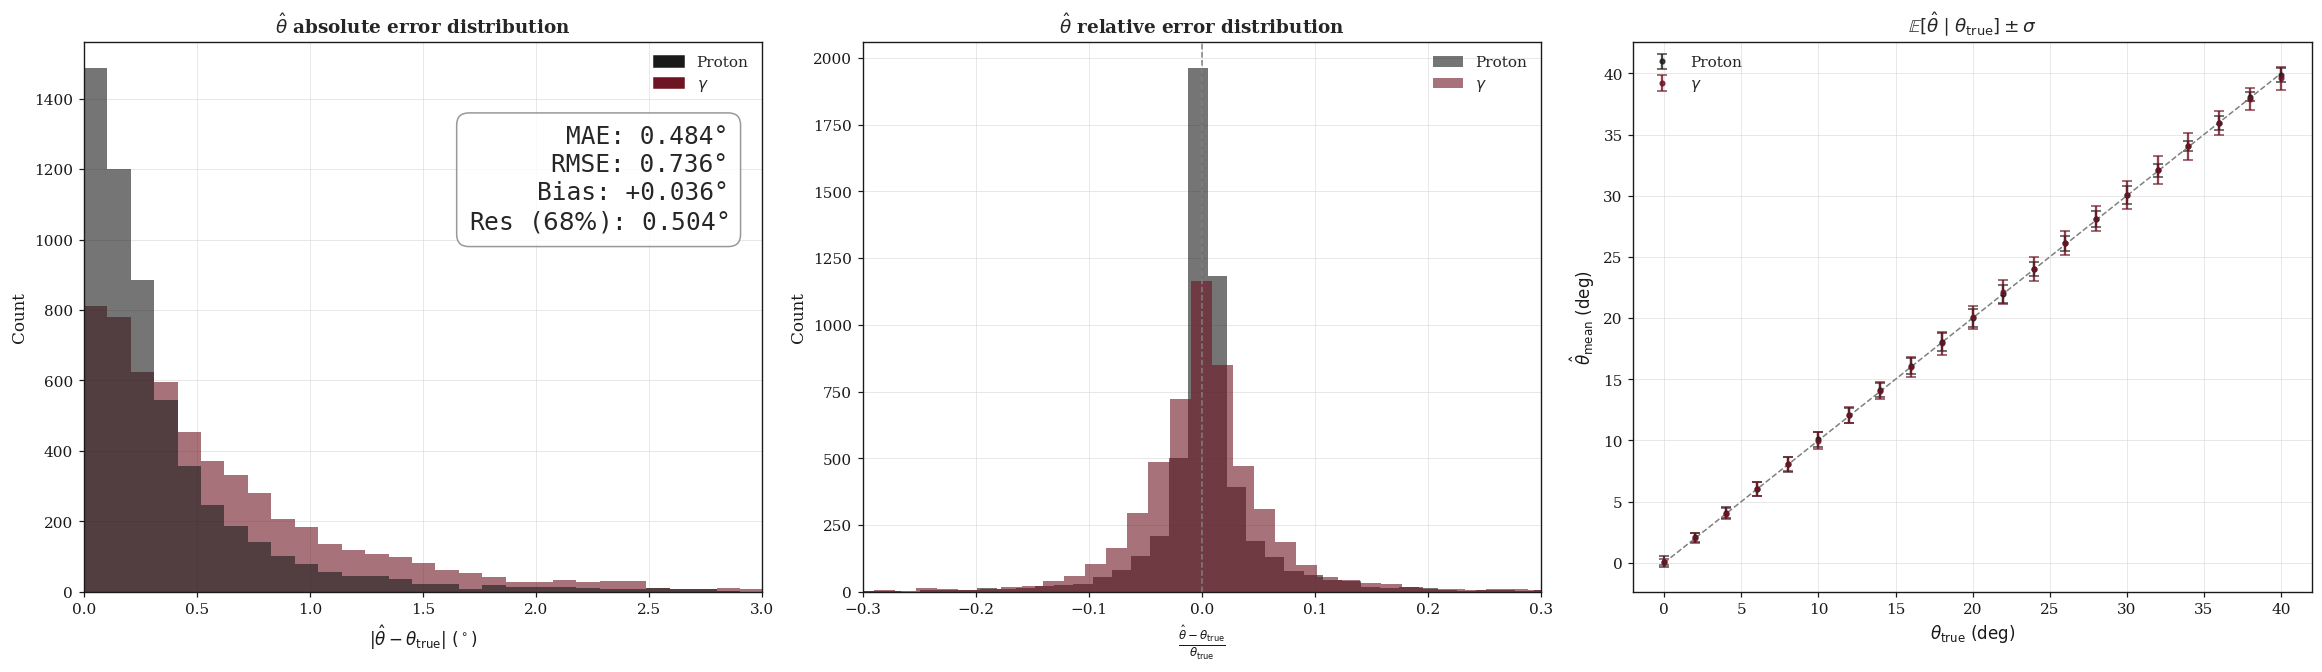

In [27]:
# ----------------------------- #
# Angle and energy diagnostics  #
# ----------------------------- #
theta_hat = pred_summary["angle_pred_deg"]
theta_true = pred_summary["angle_true_deg"]
particle_series = pred_summary["particle_true"]

particle_names = {0: "Proton", 1: r"$\gamma$"}
particle_palette = {0: "#1A1A1A", 1: "#6E1423"}

# --- Calculations for Plot 2 (Relative Error) ---
denom = theta_true.replace(0.0, np.nan)
theta_rel_error = (theta_hat - theta_true) / denom
theta_rel_error = theta_rel_error.replace([np.inf, -np.inf], np.nan)

# --- Grouping for Plot 3 ---
angle_bins = np.round(theta_true, 1)
angle_group = (
    pred_summary.assign(angle_bin=angle_bins)
    .groupby("angle_bin")
    .agg(mean_pred=("angle_pred_deg", "mean"), std_pred=("angle_pred_deg", "std"))
    .reset_index()
)
angle_group_particle = (
    pred_summary.assign(angle_bin=angle_bins)
    .groupby(["particle_true", "angle_bin"])
    .agg(mean_pred=("angle_pred_deg", "mean"), std_pred=("angle_pred_deg", "std"))
    .reset_index()
)

# --- CALCULATION OF METRICS FOR THE TEXT ---
# We calculate directly from the data to ensure consistency
errors = theta_hat - theta_true
abs_errors = np.abs(errors)

mae_val = np.mean(abs_errors)
rmse_val = np.sqrt(np.mean(errors**2))
bias_val = np.mean(errors) # Systematic bias (Mean Signed Error)
resolution_val = np.percentile(abs_errors, 68) # Angular Resolution (Sigma 68)

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- AXES 0: Absolute Error Distribution ---
sns.histplot(
    pred_summary,
    x="angle_abs_error_deg",
    hue="particle_true",
    bins=60,
    ax=axes[0],
    edgecolor="none",
    alpha=0.6,
    palette=particle_palette,
)
axes[0].set_xlabel(r"$|\hat{\theta} - \theta_{\mathrm{true}}|\ (^\circ)$")
axes[0].set_title(r"$\hat{\theta}$ absolute error distribution")
axes[0].legend(handles=[
    Patch(color=particle_palette[pid], label=particle_names[pid]) for pid in particle_palette
])
axes[0].set_xlim(0.0, 3.0)

# --- TEXT WITH THE 4 METRICS ---
metrics_text = (
    f"MAE: {mae_val:.3f}°\n"
    f"RMSE: {rmse_val:.3f}°\n"
    f"Bias: {bias_val:+.3f}°\n"     # The + sign forces showing + or -
    f"Res ($68\%$): {resolution_val:.3f}°"
)

axes[0].text(
    0.95,
    0.65, # I slightly lowered the position so it fits well
    metrics_text,
    transform=axes[0].transAxes,
    fontsize=16,
    va="bottom",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.5"),
    family="monospace" # Improved numeric alignment
)

# --- AXES 1: Relative Error Distribution ---
for pid, color in particle_palette.items():
    mask = particle_series == pid
    sns.histplot(
        theta_rel_error[mask].dropna(),
        bins=80,
        color=color,
        ax=axes[1],
        edgecolor="none",
        alpha=0.6,
        label=particle_names[pid],
    )
axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\frac{\hat{\theta}-\theta_{\mathrm{true}}}{\theta_{\mathrm{true}}}$")
axes[1].set_title(r"$\hat{\theta}$ relative error distribution")
axes[1].set_xlim(-0.3, 0.3)
axes[1].legend()

# --- AXES 2: Profile (Mean +- Std) ---
for pid, color in particle_palette.items():
    subset = angle_group_particle[angle_group_particle["particle_true"] == pid]
    axes[2].errorbar(
        subset["angle_bin"],
        subset["mean_pred"],
        yerr=subset["std_pred"].fillna(0.0),
        fmt=".",
        color=color,
        ecolor=color,
        elinewidth=1.5,
        alpha=0.8,
        capsize=3,
        label=particle_names[pid],
    )
axes[2].plot(
    angle_group["angle_bin"],
    angle_group["angle_bin"],
    color="gray",
    linestyle="--",
    linewidth=1,
)
axes[2].set_xlabel(r"$\theta_{\mathrm{true}}\ (\text{deg})$")
axes[2].set_ylabel(r"$\hat{\theta}_{\mathrm{mean}}\ (\text{deg})$")
axes[2].set_title(r"$\mathbb{E}[\hat{\theta}\mid\theta_{\mathrm{true}}] \pm \sigma$")
axes[2].legend()

# Save and show
fig.savefig(plots_dir / "angle_predictions_overview.png", dpi=200)
plt.show()

In [28]:
# ============================================================
# STANDARD ANGULAR RECONSTRUCTION METRICS
# ============================================================

def angular_resolution_metrics(theta_true, theta_pred, percentiles=[68, 95]):
    """
    Standard metrics in cosmic ray astrophysics.
    
    Returns:
    - PSF (Point Spread Function): percentiles of the angular error
    - Systematic Bias
    - Resolution (effective sigma)
    """
    errors = np.abs(theta_pred - theta_true)
    
    metrics = {
        'bias_deg': np.mean(theta_pred - theta_true),
        'median_error_deg': np.median(errors),
        'rms_deg': np.sqrt(np.mean((theta_pred - theta_true)**2)),
    }
    
    # PSF: Angular Resolution (equivalent to "sigma" in astronomy)
    for p in percentiles:
        metrics[f'psf_{p}_deg'] = np.percentile(errors, p)
    
    # Q-factor: fraction of well-reconstructed events (< 5°)
    metrics['q_factor_5deg'] = np.mean(errors < 5.0)
    
    return metrics

angle_resolution = angular_resolution_metrics(
    pred_summary["angle_true_deg"], 
    pred_summary["angle_pred_deg"]
)

print("\n ANGULAR RESOLUTION (Standard Metrics)")
print("="*60)
for key, val in angle_resolution.items():
    print(f"  {key:20s}: {val:.4f}")


 ANGULAR RESOLUTION (Standard Metrics)
  bias_deg            : 0.0357
  median_error_deg    : 0.2970
  rms_deg             : 0.7361
  psf_68_deg          : 0.5043
  psf_95_deg          : 1.5816
  q_factor_5deg       : 0.9995


### 4.3. Energy Estimation
Prediction distributions, bias/resolution analysis (CTA-style), and pull distributions.

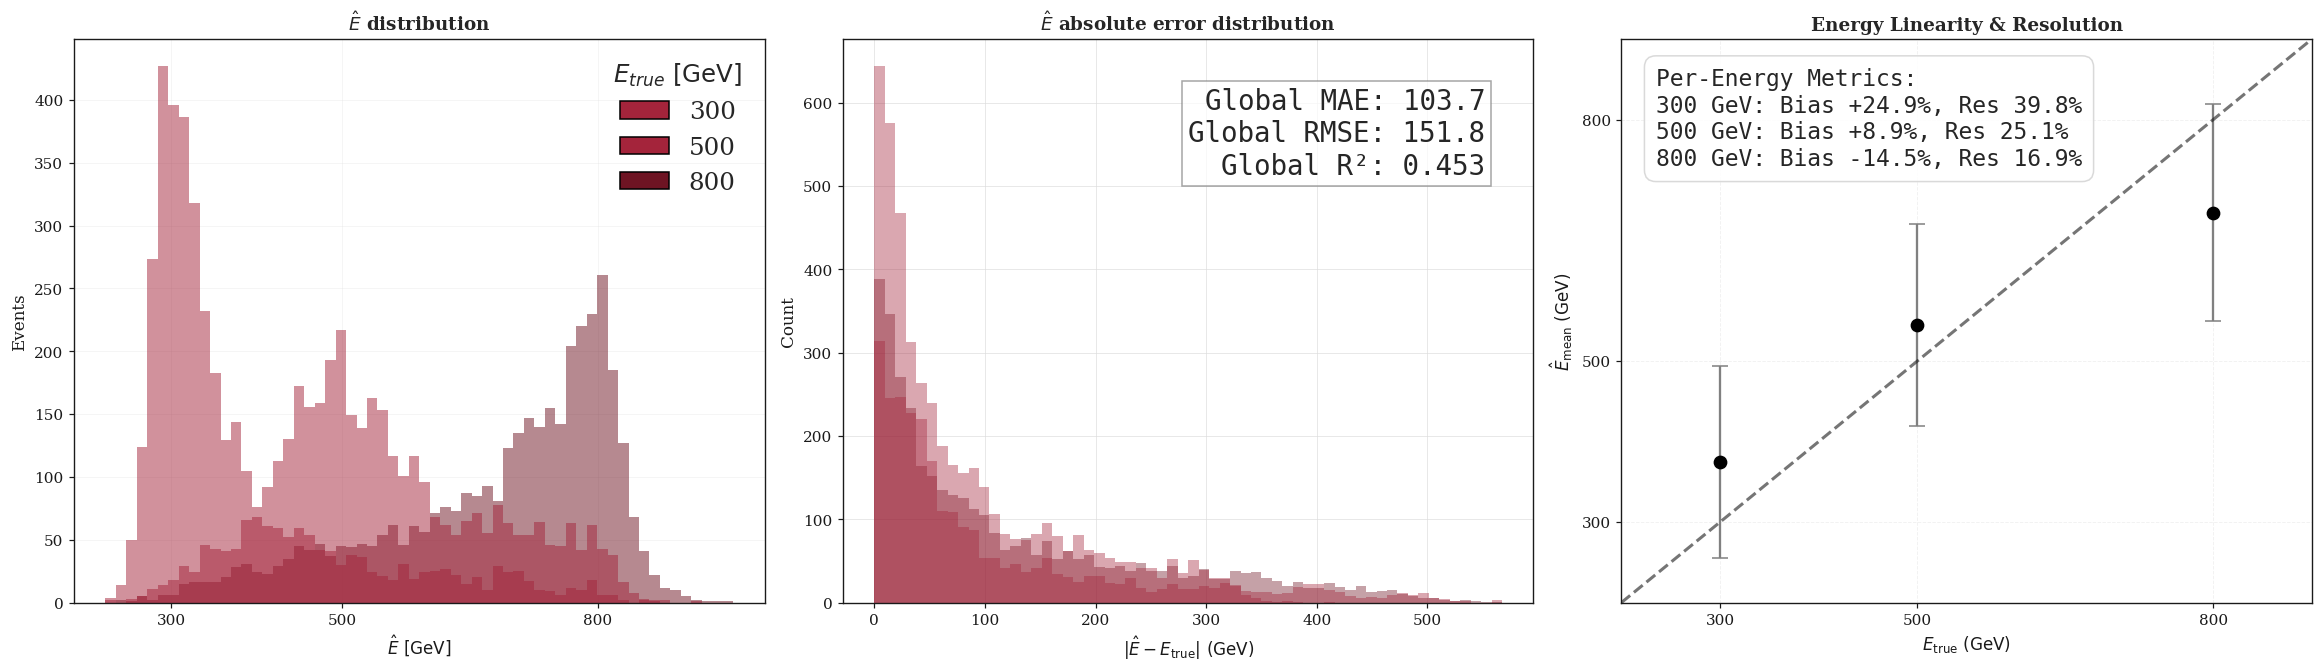

In [29]:
E_hat = pred_summary["energy_pred_GeV"]
E_true = pred_summary["energy_true_GeV"]

# Relative error calculation
# Bias = (Pred - True) / True
rel_error_series = (E_hat - E_true) / E_true.replace(0.0, np.nan)
pred_summary["relative_error"] = rel_error_series # We store it in the DF to facilitate groupby

energy_group = (
    pred_summary.groupby("energy_true_GeV")
    .agg(mean_pred=("energy_pred_GeV", "mean"), std_pred=("energy_pred_GeV", "std"))
    .reset_index()
)

energy_group_level = (
    pred_summary.groupby("energy_level_true")
    .agg(
        mean_pred=("energy_pred_GeV", "mean"),
        std_pred=("energy_pred_GeV", "std"),
        true_energy=("energy_true_GeV", "mean"),
    )
    .reset_index()
    .sort_values("true_energy")
)

energy_palette = {"3E2": "#A4243B", "5E2": "#A4243B", "8E2": "#6E1423"}
label_map = {"3E2": "300", "5E2": "500", "8E2": "800"}
desired_order = ["300", "500", "800"]

fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)

# --- AXES 0: Distribution of Predictions ---
sns.histplot(
    data=pred_summary,
    x="energy_pred_GeV",
    hue="energy_level_true",
    bins=60,
    ax=axes[0],
    alpha=0.5,
    edgecolor="none",
    palette=energy_palette,
    multiple="layer",
)
axes[0].set_xlabel(r"$\hat{E}\ \mathrm{[GeV]}$")
axes[0].set_ylabel("Events")
axes[0].set_title(r"$\hat{E}$ distribution")
axes[0].set_xticks([300, 500, 800])
axes[0].grid(alpha=0.3)

# Ordered legend for Axes 0
handles0, labels0 = axes[0].get_legend_handles_labels()
if handles0:
    mapped = []
    for h, lab in zip(handles0, labels0):
        mapped_label = label_map.get(lab, lab)
        mapped.append((mapped_label, h))
    in_order = [item for item in mapped if item[0] in desired_order]
    out_order = [item for item in mapped if item[0] not in desired_order]
    in_order_sorted = sorted(in_order, key=lambda x: desired_order.index(x[0]))
    new_handles = [h for lbl, h in (in_order_sorted + out_order)]
    new_labels = [lbl for lbl, h in (in_order_sorted + out_order)]
    axes[0].legend(new_handles, new_labels, title=r"$E_{true}\ \mathrm{[GeV]}$")
else:
    manual_handles = []
    manual_labels = []
    for key in ["3E2", "5E2", "8E2"]:
        if (pred_summary["energy_level_true"] == key).any():
            manual_handles.append(Patch(facecolor=energy_palette[key], edgecolor="k"))
            manual_labels.append(label_map[key])
    if manual_handles:
        axes[0].legend(manual_handles, manual_labels, title=r"$E_{true}\ \mathrm{[GeV]}$", fontsize=16, title_fontsize=16)

# --- AXES 1: Absolute Error ---
sns.histplot(
    pred_summary,
    x="energy_abs_error_GeV",
    hue="energy_level_true",
    bins=60,
    ax=axes[1],
    alpha=0.4,
    edgecolor="none",
    palette=energy_palette,
)
axes[1].set_xlabel(r"$|\hat{E} - E_{\mathrm{true}}|\ (\mathrm{GeV})$")
axes[1].set_title(r"$\hat{E}$ absolute error distribution")
leg1 = axes[1].get_legend()
if leg1:
    leg1.remove()

sigma_mu_E = energy_group["std_pred"].mean()
metrics_text_E = (
    f"Global MAE: {energy_metrics['MAE (GeV)']:.1f}\n"
    f"Global RMSE: {energy_metrics['RMSE (GeV)']:.1f}\n"
    f"Global R²: {energy_metrics['R2']:.3f}"
)
axes[1].text(
    0.93, 0.75, metrics_text_E,
    transform=axes[1].transAxes,
    fontsize=18,
    va="bottom",
    ha="right",
    bbox=dict(facecolor="white", alpha=0.7, edgecolor="gray"),
    family="monospace"
)

# --- AXES 2: Linearity with Bias and Resolution ---
axes[2].errorbar(
    energy_group_level["true_energy"],
    energy_group_level["mean_pred"],
    yerr=energy_group_level["std_pred"].fillna(0.0),
    fmt="o",
    color="black",
    ecolor="gray",
    elinewidth=1.5,
    capsize=5,
    markersize=8
)
# Perfect identity line
axes[2].plot(
    [200, 900], [200, 900], # Extended range for better line visibility
    color="#1A1A1A",
    linestyle="--",
    linewidth=2,
    alpha=0.6,
    label="Ideal"
)

# --- CALCULATION OF BIAS AND RESOLUTION FOR THE TEXT BOX ---
stats_text_lines = ["Per-Energy Metrics:"]
map_keys = [("3E2", "300"), ("5E2", "500"), ("8E2", "800")]

for key_df, label_display in map_keys:
    # Filter data by energy level
    subset = pred_summary[pred_summary["energy_level_true"] == key_df]
    
    if not subset.empty:
        # Bias: Mean relative error (%)
        # Resolution: Standard deviation of relative error (%)
        rel_errs = subset["relative_error"]
        bias_pct = rel_errs.mean() * 100
        res_pct = rel_errs.std() * 100
        
        line = f"{label_display} GeV: Bias {bias_pct:+.1f}%, Res {res_pct:.1f}%"
        stats_text_lines.append(line)

final_stats_text = "\n".join(stats_text_lines)

# Insert the text box in Axes 2 (Upper left corner)
axes[2].text(
    0.05, 0.95, 
    final_stats_text,
    transform=axes[2].transAxes,
    fontsize=15,
    verticalalignment="top",
    horizontalalignment="left",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="lightgray", boxstyle="round,pad=0.5"),
    family="monospace" # Monospaced font for better number alignment
)

axes[2].set_xlabel(r"$E_{\mathrm{true}}\ (\mathrm{GeV})$")
axes[2].set_ylabel(r"$\hat{E}_{\mathrm{mean}}\ (\mathrm{GeV})$")
axes[2].set_title(r"Energy Linearity & Resolution")
axes[2].set_xticks([300, 500, 800])
axes[2].set_yticks([300, 500, 800])
axes[2].set_xlim(200, 900)
axes[2].set_ylim(200, 900)
axes[2].grid(True, linestyle="--", alpha=0.4)

# Save and show
fig.savefig(plots_dir / "energy_predictions_overview.png", dpi=200)
plt.show()

Stratified energy bias & resolution:
particle  energy_GeV  bias_pct  resolution_pct
  Proton         300       6.0            20.2
  Proton         500       6.0            19.9
  Proton         800     -11.2            15.5
   Gamma         300      43.8            45.3
   Gamma         500      12.0            29.2
   Gamma         800     -17.7            17.5


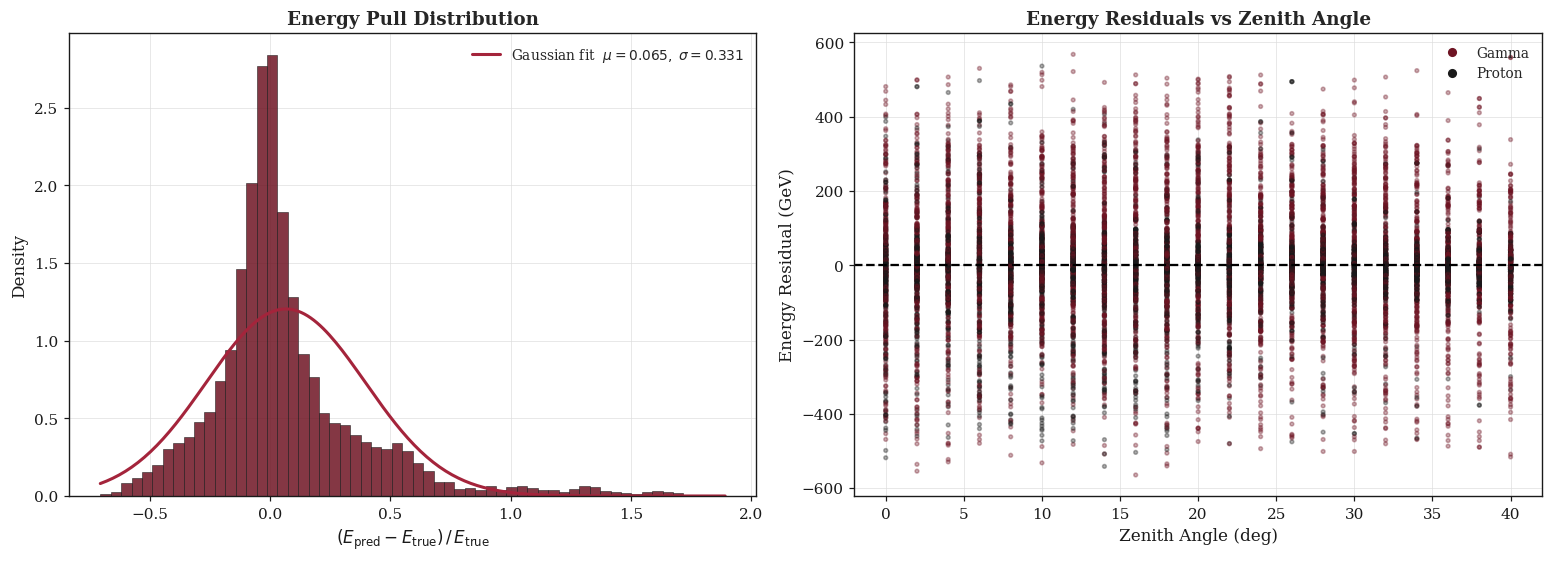

Figure saved: energy_detailed_analysis.png


In [30]:
# ============================================================
# ENERGY ANALYSIS — Pull distribution + residuals vs angle
# Top panels (bias/resolution vs energy) replaced by Table 4.3 in thesis.
# ============================================================

# ─── Compute and save stratified bias & resolution ─────────
energy_stats_rows = []
for particle_type, pname in [(0, "Proton"), (1, "Gamma")]:
    mask = pred_summary["particle_true"] == particle_type
    for e_val in sorted(pred_summary["energy_true_GeV"].unique()):
        sub = pred_summary[mask & (pred_summary["energy_true_GeV"] == e_val)]
        bias = ((sub["energy_pred_GeV"] - sub["energy_true_GeV"]) / sub["energy_true_GeV"]).mean() * 100
        resol = ((sub["energy_pred_GeV"] - sub["energy_true_GeV"]) / sub["energy_true_GeV"]).std() * 100
        energy_stats_rows.append({
            "particle": pname,
            "energy_GeV": int(e_val),
            "bias_pct": round(bias, 1),
            "resolution_pct": round(resol, 1),
        })
energy_stats_df = pd.DataFrame(energy_stats_rows)
energy_stats_csv = plots_dir / "energy_stratified_stats.csv"
energy_stats_df.to_csv(energy_stats_csv, index=False)
print("Stratified energy bias & resolution:")
print(energy_stats_df.to_string(index=False))

# ─── Figure: pull distribution + residuals vs angle (1×2) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
apply_condor_style()

E_hat  = pred_summary["energy_pred_GeV"]
E_true = pred_summary["energy_true_GeV"]
pull   = (E_hat - E_true) / E_true.replace(0.0, np.nan)

# Panel 1: Pull distribution
ax3 = axes[0]
ax3.hist(pull.dropna(), bins=60, alpha=0.85, color=CONDOR_DARKRED,
         edgecolor=CONDOR_INK, linewidth=0.4, density=True)
from scipy.stats import norm as _norm
mu, sigma = pull.mean(), pull.std()
x_fit = np.linspace(pull.min(), pull.max(), 200)
ax3.plot(x_fit, _norm.pdf(x_fit, mu, sigma), color=CONDOR_RED, linewidth=2,
         label=rf"Gaussian fit  $\mu={mu:.3f},\;\sigma={sigma:.3f}$")
ax3.set_xlabel(r"$(E_\mathrm{pred} - E_\mathrm{true})\,/\,E_\mathrm{true}$")
ax3.set_ylabel("Density")
ax3.set_title("Energy Pull Distribution")
ax3.legend(fontsize=9)

# Panel 2: Residuals vs zenith angle
ax4 = axes[1]
residuals = E_hat - E_true
ptypes    = pred_summary["particle_true"].values
colors_sc = [CONDOR_DARKRED if p == 1 else CONDOR_INK for p in ptypes]
ax4.scatter(pred_summary["angle_true_deg"], residuals,
            c=colors_sc, alpha=0.35, s=6, rasterized=True)
ax4.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax4.set_xlabel("Zenith Angle (deg)")
ax4.set_ylabel("Energy Residual (GeV)")
ax4.set_title("Energy Residuals vs Zenith Angle")
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=CONDOR_DARKRED,
           markersize=7, label='Gamma'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=CONDOR_INK,
           markersize=7, label='Proton'),
]
ax4.legend(handles=legend_elements, fontsize=9)

fig.savefig(plots_dir / "energy_detailed_analysis.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()
print(f"Figure saved: energy_detailed_analysis.png")


### 4.4. Stratified ROC Analysis
ROC curves stratified by energy level and zenith angle bins.

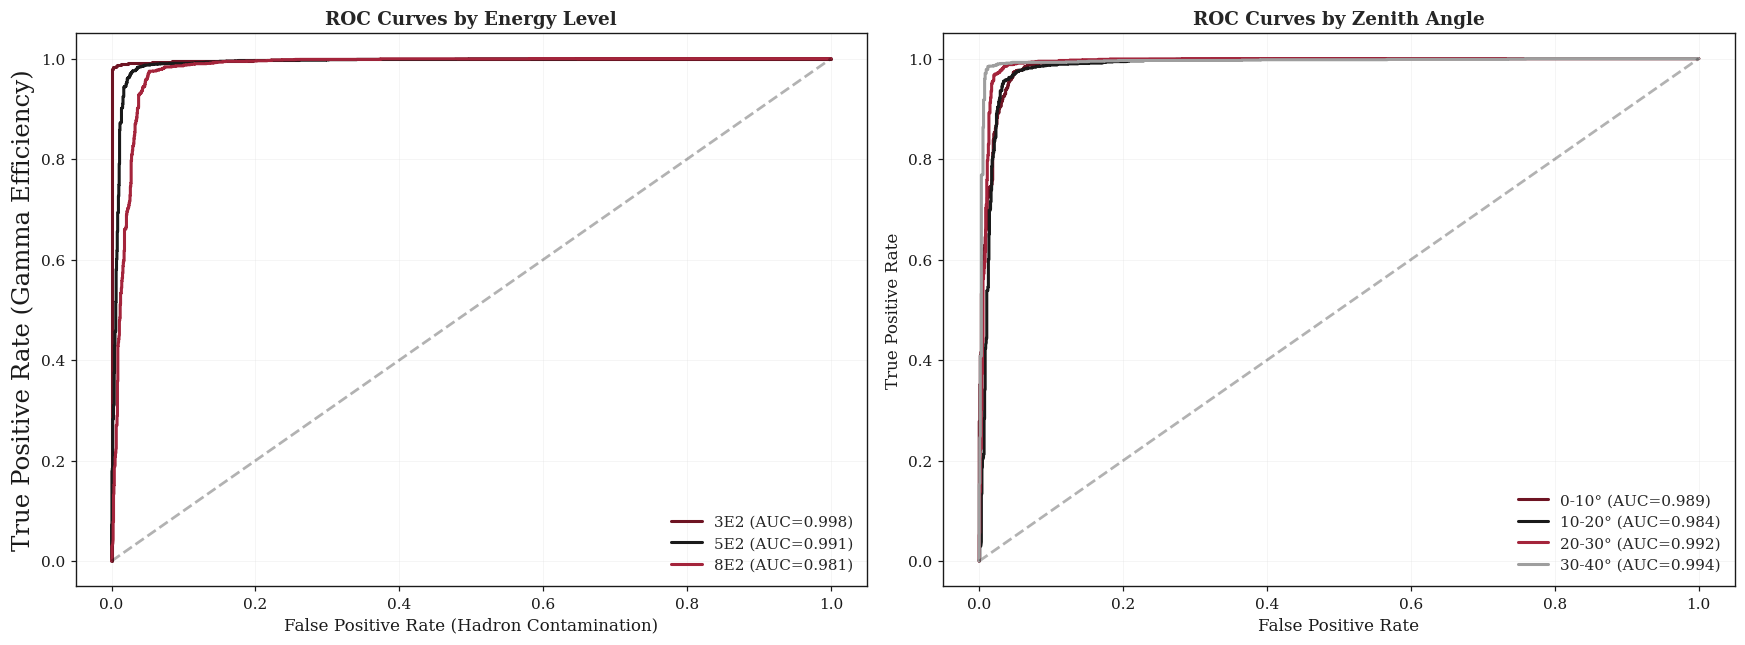

In [31]:
# ============================================================
# ROC CURVES: STRATIFIED BY PHYSICS PARAMETERS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC by energy level
ax1 = axes[0]
for energy_level in ["3E2", "5E2", "8E2"]:
    mask = pred_summary["energy_level_true"] == energy_level
    if mask.sum() > 10:
        fpr_e, tpr_e, _ = roc_curve(
            pred_summary[mask]["particle_true"],
            pred_summary[mask]["particle_pred_prob"]
        )
        auc_e = auc(fpr_e, tpr_e)
        ax1.plot(fpr_e, tpr_e, label=f'{energy_level} (AUC={auc_e:.3f})', linewidth=2)

ax1.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax1.set_xlabel("False Positive Rate (Hadron Contamination)")
ax1.set_ylabel("True Positive Rate (Gamma Efficiency)", fontsize=16)
ax1.set_title("ROC Curves by Energy Level")
ax1.legend()
ax1.grid(alpha=0.3)

# ROC by zenith angle
ax2 = axes[1]
angle_bins = [(0, 10), (10, 20), (20, 30), (30,40)]
for angle_min, angle_max in angle_bins:
    mask = (pred_summary["angle_true_deg"] >= angle_min) & \
           (pred_summary["angle_true_deg"] < angle_max)
    if mask.sum() > 10:
        fpr_a, tpr_a, _ = roc_curve(
            pred_summary[mask]["particle_true"],
            pred_summary[mask]["particle_pred_prob"]
        )
        auc_a = auc(fpr_a, tpr_a)
        ax2.plot(fpr_a, tpr_a, label=f'{angle_min}-{angle_max}° (AUC={auc_a:.3f})', linewidth=2)

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax2.set_xlabel("False Positive Rate")
ax2.set_ylabel("True Positive Rate")
ax2.set_title("ROC Curves by Zenith Angle")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "roc_stratified.png", dpi=200)
plt.show()

### 4.5. Energy Migration Matrix
Confusion-style matrix for the three discrete primary energies. Row-normalised: each row shows how events of a given true energy are distributed across the reconstructed energy bins. A dominant diagonal means little energy migration.

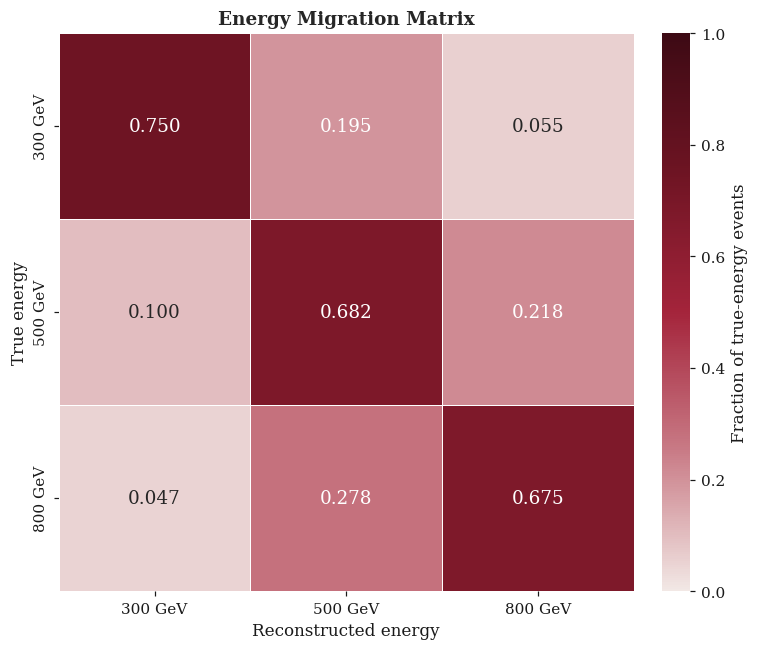

In [32]:
e_edges = [-np.inf, 400, 650, np.inf]
e_labels = ["300 GeV", "500 GeV", "800 GeV"]
true_bin = pd.cut(pred_summary["energy_true_GeV"], bins=e_edges, labels=e_labels)
pred_bin = pd.cut(pred_summary["energy_pred_GeV"], bins=e_edges, labels=e_labels)
migration = (
    pd.crosstab(true_bin, pred_bin, normalize="index")
    .reindex(index=e_labels, columns=e_labels)
)

fig, ax = plt.subplots(figsize=(6.8, 5.8), constrained_layout=True)
sns.heatmap(migration, annot=True, fmt=".3f", cmap=CMAP_SEQ, vmin=0, vmax=1,
            linewidths=0.6, linecolor="white", annot_kws={"fontsize": 12},
            cbar_kws={"label": "Fraction of true-energy events"}, ax=ax)
ax.set_xlabel("Reconstructed energy")
ax.set_ylabel("True energy")
ax.set_title("Energy Migration Matrix")
fig.savefig(plots_dir / "energy_migration_matrix.png", dpi=SAVE_DPI)
plt.show()

### 4.6. Consolidated Performance Summary

In [33]:
# ============================================================
# CONSOLIDATED PERFORMANCE TABLE
# ============================================================

summary_table = pd.DataFrame({
    'Task': ['Gamma/Hadron', 'Angle Reconstruction', 'Energy Estimation'],
    'Primary Metric': [
        f"AUC = {roc_auc:.4f}",
        f"PSF68 = {angle_resolution['psf_68_deg']:.2f}°",
        f"Bias = {energy_metrics['MAE (GeV)']:.1f} GeV"
    ],
    'Resolution': [
        f"Q-factor = {gh_metrics['q_factor']:.3f}",
        f"RMS = {angle_resolution['rms_deg']:.2f}°",
        f"σ/E = {(pred_summary['relative_error'].std()*100):.1f}%"
    ],
    'Efficiency/R²': [
        f"ε_γ = {gh_metrics['efficiency_gamma']:.3f}",
        f"Q-factor(<5°) = {angle_resolution['q_factor_5deg']:.3f}",
        f"R² = {energy_metrics['R2']:.4f}"
    ]
})

display(summary_table)
summary_table.to_csv(ARTIFACTS_DIR / "performance_summary.csv", index=False)

,Task,Primary Metric,Resolution,Efficiency/R²
0,Gamma/Hadron,AUC = 0.9907,Q-factor = 5.482,ε_γ = 0.971
1,Angle Reconstruction,PSF68 = 0.50°,RMS = 0.74°,Q-factor(<5°) = 0.999
2,Energy Estimation,Bias = 103.7 GeV,σ/E = 33.1%,R² = 0.4530


## 5. Explainability
### 5.1. Feature Ablation Study
Measures feature importance by replacing each feature with its median value and measuring task degradation.

In [34]:
# ============================================================
# FEATURE ABLATION STUDY
# ============================================================
"""
Objective: Measure the importance of each feature by REMOVING it from the model
Difference vs PFI: 
   - PFI: permutes values (maintains distribution)
   - Ablation: replaces with neutral value (mean/median/zero)

NOTE: Replacement values (mean/median) are computed from the TRAINING set only,
excluding padded positions (where all 6 features are zero), to avoid data leakage
and inflation from padding zeros.
"""

from tqdm.notebook import tqdm

# ----------------------------- #
# Ablation Configuration        #
# ----------------------------- #

FEATURE_NAMES_ABLATION = FEATURE_NAMES  # defined in utilities cell

# ----------------------------- #
# Pre-compute replacement values from TRAINING set (excluding padding)
# ----------------------------- #

# Mask: a position is non-padded if ANY of its 6 features is non-zero
_train_mask = np.any(X_train != 0, axis=-1)  # (n_train, seq_len)

TRAIN_FEATURE_STATS = {}
for feat_idx, feat_name in enumerate(FEATURE_NAMES_ABLATION):
    feat_values = X_train[:, :, feat_idx]  # (n_train, seq_len)
    # Only include values at non-padded positions
    valid_values = feat_values[_train_mask]
    TRAIN_FEATURE_STATS[feat_idx] = {
        'zero': 0.0,
        'mean': float(np.mean(valid_values)),
        'median': float(np.median(valid_values)),
    }

print("Pre-computed replacement values from TRAINING set (padding excluded):")
for idx, name in enumerate(FEATURE_NAMES_ABLATION):
    stats = TRAIN_FEATURE_STATS[idx]
    print(f"  {name:15s} -> mean={stats['mean']:.4f}, median={stats['median']:.4f}")

# ----------------------------- #
# Core Functions                #
# ----------------------------- #

def ablate_feature(X_seq, feature_idx, strategy='median'):
    """
    Replaces a feature with a neutral value computed from the training set.
    Only replaces at NON-PADDED positions to preserve masking behavior.
    
    Args:
        X_seq: Array (batch, seq_len, n_features)
        feature_idx: Index of the feature to ablate
        strategy: 'zero', 'mean', or 'median'
    
    Returns:
        X_ablated: Copy with ablated feature at non-padded positions
    """
    X_ablated = np.array(X_seq, copy=True)
    
    # Identify non-padded positions (where ANY feature is non-zero)
    non_padded_mask = np.any(X_seq != 0, axis=-1)  # (batch, seq_len)
    
    # Get replacement value from pre-computed training stats
    replacement_value = TRAIN_FEATURE_STATS[feature_idx][strategy]
    
    # Only replace at non-padded positions to preserve Masking layer behavior
    X_ablated[:, :, feature_idx] = np.where(
        non_padded_mask, replacement_value, 0.0
    )
    
    return X_ablated

def compute_task_metric(y_true, y_pred, task_name):
    """
    Calculates task-specific metric.
    """
    if task_name == 'particle':
        return accuracy_score(y_true.astype(int), (y_pred >= 0.5).astype(int))
    else:  # angle, energy
        return mean_absolute_error(y_true.astype(float), y_pred.astype(float))

def run_ablation_study(
    model, 
    X_seq, 
    X_global, 
    y_true_dict,
    strategy='median',
    batch_size=BATCH_SIZE,
    verbose=True
):
    """
    Runs complete ablation study.
    
    Args:
        model: Trained Keras model
        X_seq: Input sequences (batch, seq_len, n_features)
        X_global: Global features (batch, n_global_features)
        y_true_dict: Dict with ground truth per task
            {'particle': array, 'angle': array, 'energy': array}
        strategy: 'zero', 'mean', or 'median'
        batch_size: Batch size for inference
        verbose: Show progress
    
    Returns:
        results_df: DataFrame with ablation results
    """
    
    # 1. Baseline (model without ablation)
    if verbose:
        print("\U0001f4ca Calculating baseline (without ablation)...")
    
    baseline_preds = model.predict([X_seq, X_global], batch_size=batch_size, verbose=0)
    pred_particle_base, pred_angle_base, pred_energy_base = baseline_preds
    
    # Denormalize energy
    pred_energy_base = pred_energy_base.reshape(-1) * energy_std + energy_mean
    
    baseline_scores = {
        'particle': compute_task_metric(y_true_dict['particle'], pred_particle_base.reshape(-1), 'particle'),
        'angle': compute_task_metric(y_true_dict['angle'], pred_angle_base.reshape(-1), 'angle'),
        'energy': compute_task_metric(y_true_dict['energy'], pred_energy_base, 'energy'),
    }
    
    if verbose:
        print("\n\u2705 Baseline Scores:")
        for task, score in baseline_scores.items():
            print(f"   {task:12s}: {score:.4f}")
    
    # 2. Ablation for each feature
    results = []
    
    iterator = enumerate(FEATURE_NAMES_ABLATION)
    if verbose:
        iterator = tqdm(list(iterator), desc="Ablating features")
    
    for feat_idx, feat_name in iterator:
        # Ablate feature (uses train-set statistics, excludes padding)
        X_ablated = ablate_feature(X_seq, feat_idx, strategy=strategy)
        
        # Predict with ablated input
        ablated_preds = model.predict([X_ablated, X_global], batch_size=batch_size, verbose=0)
        pred_particle_abl, pred_angle_abl, pred_energy_abl = ablated_preds
        
        # Denormalize energy
        pred_energy_abl = pred_energy_abl.reshape(-1) * energy_std + energy_mean
        
        ablated_scores = {
            'particle': compute_task_metric(y_true_dict['particle'], pred_particle_abl.reshape(-1), 'particle'),
            'angle': compute_task_metric(y_true_dict['angle'], pred_angle_abl.reshape(-1), 'angle'),
            'energy': compute_task_metric(y_true_dict['energy'], pred_energy_abl, 'energy'),
        }
        
        for task in ['particle', 'angle', 'energy']:
            base_score = baseline_scores[task]
            abl_score = ablated_scores[task]
            
            if task == 'particle':
                # For accuracy: importance = drop in accuracy
                importance = base_score - abl_score
                pct_change = -100 * importance / base_score if base_score > 0 else 0
            else:
                # For MAE: importance = increase in MAE
                importance = abl_score - base_score
                pct_change = 100 * importance / base_score if base_score > 0 else 0
            
            results.append({
                'feature': feat_name,
                'task': task,
                'baseline_score': base_score,
                'ablated_score': abl_score,
                'importance': importance,
                'pct_change': pct_change,
                'strategy': strategy,
            })
        
        del X_ablated, ablated_preds
    
    results_df = pd.DataFrame(results)
    return results_df, baseline_scores


Pre-computed replacement values from TRAINING set (padding excluded):
  detector_id     -> mean=52.7856, median=52.0000
  particle_count  -> mean=1.1642, median=1.0000
  t_bin           -> mean=56.1232, median=46.0000
  total_energy    -> mean=0.5834, median=0.0372
  x_center        -> mean=-0.4665, median=-4.2500
  y_center        -> mean=0.0240, median=4.5000


In [35]:
# ----------------------------- #
# Execute Ablation Study       #
# ----------------------------- #

print("="*80)
print("FEATURE ABLATION STUDY")
print("="*80)
print(f"\nAblation strategy: MEDIAN (replace with training-set median, padding excluded)")
print(f"Dataset: Test set ({len(X_test)} samples)")
print(f"Features analyzed: {FEATURE_NAMES_ABLATION}")

y_true_dict = {
    'particle': y_label_test,
    'angle': y_angle_test,
    'energy': y_energy_test_cont
}

# Execute ablation
ablation_results, baseline_scores = run_ablation_study(
    model=model,
    X_seq=X_test,
    X_global=Xg_test,
    y_true_dict=y_true_dict,
    strategy='median',
    batch_size=BATCH_SIZE,
    verbose=True
)


FEATURE ABLATION STUDY

Ablation strategy: MEDIAN (replace with training-set median, padding excluded)
Dataset: Test set (11209 samples)
Features analyzed: ['detector_id', 'particle_count', 't_bin', 'total_energy', 'x_center', 'y_center']
📊 Calculating baseline (without ablation)...

✅ Baseline Scores:
   particle    : 0.9699
   angle       : 0.4841
   energy      : 103.7179


Ablating features:   0%|          | 0/6 [00:00<?, ?it/s]

In [ ]:
# ----------------------------- #
# Feature ablation - relative degradation (%) per task (single row)
# ----------------------------- #
from matplotlib.colors import LinearSegmentedColormap, Normalize
_CMAP_SEQ = LinearSegmentedColormap.from_list(
    "condor_seq", ["#F2E8E5", "#C97B86", "#A4243B", "#6E1423", "#3D0A14"])
_INK = "#1A1A1A"

tasks = ["particle", "angle", "energy"]
task_titles = ["Gamma-Hadron Discrimination", "Zenith Angle Reconstruction", "Energy Estimation"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
for ax, task, title in zip(axes, tasks, task_titles):
    sub = ablation_results[ablation_results["task"] == task].copy()
    sub["pct"] = sub["pct_change"].abs()          # particle pct_change is negative
    sub = sub.sort_values("pct", ascending=True)
    pct = sub["pct"].to_numpy()
    norm = Normalize(0, max(pct.max(), 1e-9))
    ax.barh(sub["feature"], pct, color=_CMAP_SEQ(norm(pct)), edgecolor=_INK, linewidth=0.6)
    for y, v in enumerate(pct):
        ax.text(v + pct.max() * 0.01, y, f"{v:.1f}%", va="center", ha="left",
                fontsize=8.5, color=_INK)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Relative degradation (%)")
    ax.set_xlim(0, pct.max() * 1.18)
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Feature ablation - relative degradation when each feature is replaced by its training-set median",
             fontweight="bold")
fig.savefig(plots_dir / "feature_ablation.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()


In [37]:
print("\n" + "="*80)
print("FEATURE ABLATION SUMMARY")
print("="*80)

pivot_table = ablation_results.pivot_table(
    index='feature',
    columns='task',
    values='importance',
    aggfunc='mean'
).round(4)

# Ranking by task
pivot_table['rank_particle'] = pivot_table['particle'].rank(ascending=False)
pivot_table['rank_angle'] = pivot_table['angle'].rank(ascending=False)
pivot_table['rank_energy'] = pivot_table['energy'].rank(ascending=False)

# Calculate average importance
pivot_table['avg_importance'] = pivot_table[['particle', 'angle', 'energy']].mean(axis=1)
pivot_table = pivot_table.sort_values('avg_importance', ascending=False)

display(pivot_table)

# Save results
ablation_results.to_csv(ARTIFACTS_DIR / "diagnostics" / "feature_ablation_results.csv", index=False)
pivot_table.to_csv(ARTIFACTS_DIR / "diagnostics" / "feature_ablation_summary.csv")

print(f"\n Results saved to:")
print(f"   - {ARTIFACTS_DIR / 'diagnostics' / 'feature_ablation_results.csv'}")
print(f"   - {ARTIFACTS_DIR / 'diagnostics' / 'feature_ablation_summary.csv'}")


FEATURE ABLATION SUMMARY


task,angle,energy,particle,rank_particle,rank_angle,rank_energy,avg_importance
feature,,,,,,,
x_center,9.1435,106.3899,0.1361,2.0,2.0,1.0,38.556500
detector_id,7.0486,83.4498,0.1124,4.0,3.0,2.0,30.203600
t_bin,12.4334,72.7209,0.1180,3.0,1.0,3.0,28.424100
y_center,0.2357,58.5765,0.0711,5.0,4.0,4.0,19.627767
total_energy,0.1285,38.1201,0.2241,1.0,5.0,5.0,12.824233
particle_count,0.0228,0.5811,0.0012,6.0,6.0,6.0,0.201700



 Results saved to:
   - pipeline_artifacts\diagnostics\feature_ablation_results.csv
   - pipeline_artifacts\diagnostics\feature_ablation_summary.csv


In [38]:
# ----------------------------- #
# Physical Insights             #
# ----------------------------- #

print("\n" + "="*80)
print("PHYSICAL INSIGHTS FROM ABLATION")
print("="*80)

# Top 3 features per task
for task, title in zip(tasks, task_titles):
    top3 = ablation_results[ablation_results['task'] == task].nlargest(3, 'importance')
    print(f"\n{title}:")
    for i, row in enumerate(top3.itertuples(), 1):
        print(f"   {i}. {row.feature:15s}: Importance = {row.importance:.4f} ({row.pct_change:+.1f}%)")

# Cross-task dependencies analysis
print("\n\nCROSS-TASK FEATURE IMPORTANCE:")
cross_task_importance = ablation_results.groupby('feature')['importance'].agg(['mean', 'std', 'min', 'max']).round(4)
cross_task_importance = cross_task_importance.sort_values('mean', ascending=False)
display(cross_task_importance)

print("\n" + "="*80)


PHYSICAL INSIGHTS FROM ABLATION

Gamma-Hadron
Discrimination:
   1. total_energy   : Importance = 0.2241 (-23.1%)
   2. x_center       : Importance = 0.1361 (-14.0%)
   3. t_bin          : Importance = 0.1180 (-12.2%)

Zenith Angle
Reconstruction:
   1. t_bin          : Importance = 12.4334 (+2568.3%)
   2. x_center       : Importance = 9.1435 (+1888.7%)
   3. detector_id    : Importance = 7.0486 (+1456.0%)

Energy
Estimation:
   1. x_center       : Importance = 106.3899 (+102.6%)
   2. detector_id    : Importance = 83.4498 (+80.5%)
   3. t_bin          : Importance = 72.7209 (+70.1%)


CROSS-TASK FEATURE IMPORTANCE:


,mean,std,min,max
feature,,,,
x_center,38.5565,58.9178,0.1361,106.3899
detector_id,30.2036,46.2428,0.1124,83.4498
t_bin,28.4241,38.8532,0.1180,72.7209
y_center,19.6278,33.7307,0.0711,58.5765
total_energy,12.8242,21.9069,0.1285,38.1201
particle_count,0.2017,0.3287,0.0012,0.5811


### 5.2. Permutation Feature Importance
Per-sequence feature PFI: permute each feature column across events and measure metric degradation.

In [39]:
# Permutation Feature Importance — Sequence Features
# NOTE: Permutation is restricted to NON-PADDED positions only.
# This prevents creating "ghost hits" (1 non-zero feature + 5 zeros)
# that would bypass the Masking layer and inflate importance estimates.

OUTPUT_SPECS = {
    "particle": {
        "metric_name": "accuracy",
        "metric": lambda pred: accuracy_score(y_label_test.astype(int), (pred >= 0.5).astype(int)),
        "higher_is_better": True,
    },
    "angle": {
        "metric_name": "MAE_deg",
        "metric": lambda pred: mean_absolute_error(y_angle_test.astype(float), pred.astype(float)),
        "higher_is_better": False,
    },
    "energy": {
        "metric_name": "MAE_GeV",
        "metric": lambda pred: mean_absolute_error(y_energy_test_cont.astype(float), pred.astype(float)),
        "higher_is_better": False,
    },
}

def _predict_all_heads(seq_input, global_input, batch_size=32):
    with tf.device("/GPU:0"):
        head_particle, head_angle, head_energy_scaled = model.predict(
            [seq_input, global_input], batch_size=batch_size, verbose=0
        )
    head_particle = head_particle.reshape(-1)
    head_angle = head_angle.reshape(-1)
    head_energy = head_energy_scaled.reshape(-1) * energy_std + energy_mean
    return {"particle": head_particle, "angle": head_angle, "energy": head_energy}

def _permute_sequence_feature(seq_data, feat_idx, rng):
    """
    Permute a single feature across events, but ONLY at non-padded positions.
    Padded positions (all 6 features == 0) are left untouched to preserve masking.
    """
    permuted = np.array(seq_data, copy=True)
    # Non-padded mask: True where ANY of the 6 features is non-zero
    non_padded = np.any(seq_data != 0, axis=-1)  # (batch, seq_len)
    feature_view = permuted[:, :, feat_idx]
    for t_idx in range(feature_view.shape[1]):
        # Only permute among events that have a real (non-padded) value at this timestep
        valid_mask = non_padded[:, t_idx]  # (batch,)
        valid_indices = np.where(valid_mask)[0]
        if len(valid_indices) > 1:
            feature_view[valid_indices, t_idx] = rng.permutation(feature_view[valid_indices, t_idx])
    permuted[:, :, feat_idx] = feature_view
    return permuted

def compute_pfi_sequence_features(
    model,
    X_seq,
    X_global,
    *,
    n_repeats=8,
    random_state=42,
    batch_size=32,
):
    rng_master = np.random.default_rng(random_state)
    baseline_preds = _predict_all_heads(X_seq, X_global, batch_size=32)
    baseline_scores = {
        task: spec["metric"](baseline_preds[task]) for task, spec in OUTPUT_SPECS.items()
    }

    records = []
    for feat_idx, feat_name in tqdm(enumerate(FEATURE_NAMES), total=len(FEATURE_NAMES), desc="PFI features"):
        task_scores = {task: [] for task in OUTPUT_SPECS}
        for rep in tqdm(range(n_repeats), desc=f"  {feat_name} repeats", leave=False):
            rng = np.random.default_rng(rng_master.integers(0, 2**32 - 1))
            X_perm = _permute_sequence_feature(X_seq, feat_idx, rng)
            perm_preds = _predict_all_heads(X_perm, X_global, batch_size=batch_size)
            for task, spec in OUTPUT_SPECS.items():
                task_scores[task].append(spec["metric"](perm_preds[task]))
            del X_perm, perm_preds
            gc.collect()

        for task, scores in task_scores.items():
            scores = np.asarray(scores, dtype=float)
            baseline = baseline_scores[task]
            mean_score = float(scores.mean())
            std_score = float(scores.std(ddof=1))
            delta = baseline - mean_score if OUTPUT_SPECS[task]["higher_is_better"] else mean_score - baseline
            records.append(
                {
                    "feature": f"sequence::{feat_name}",
                    "task": task,
                    "metric_name": OUTPUT_SPECS[task]["metric_name"],
                    "baseline": baseline,
                    "permuted_mean": mean_score,
                    "permuted_std": std_score,
                    "importance_delta": delta,
                }
            )

    results = (
        pd.DataFrame(records)
        .sort_values(["task", "importance_delta"], ascending=[True, False])
        .reset_index(drop=True)
    )
    return baseline_scores, results

baseline_scores, pfi_results = compute_pfi_sequence_features(
    model,
    X_test,
    Xg_test,
    n_repeats=8,
    random_state=42,
    batch_size=32,
)

print("Baseline metrics by head:")
for task, value in baseline_scores.items():
    print(f"  {task}: {value:.4f}")

display(pfi_results)
pfi_results.to_csv(ARTIFACTS_DIR / "diagnostics" / "pfi_all_heads_sequence_only.csv", index=False)


PFI features:   0%|          | 0/6 [00:00<?, ?it/s]

  detector_id repeats:   0%|          | 0/8 [00:00<?, ?it/s]

  particle_count repeats:   0%|          | 0/8 [00:00<?, ?it/s]

  t_bin repeats:   0%|          | 0/8 [00:00<?, ?it/s]

  total_energy repeats:   0%|          | 0/8 [00:00<?, ?it/s]

  x_center repeats:   0%|          | 0/8 [00:00<?, ?it/s]

  y_center repeats:   0%|          | 0/8 [00:00<?, ?it/s]

Baseline metrics by head:
  particle: 0.9699
  angle: 0.4841
  energy: 103.7179


,feature,task,metric_name,baseline,permuted_mean,permuted_std,importance_delta
0,sequence::t_bin,angle,MAE_deg,0.484119,13.247499,0.010729,12.763380
1,sequence::x_center,angle,MAE_deg,0.484119,5.630046,0.016624,5.145927
2,sequence::detector_id,angle,MAE_deg,0.484119,3.784264,0.012847,3.300145
3,sequence::y_center,angle,MAE_deg,0.484119,0.805223,0.004059,0.321104
4,sequence::total_energy,angle,MAE_deg,0.484119,0.649152,0.003537,0.165033
5,sequence::particle_count,angle,MAE_deg,0.484119,0.502268,0.000763,0.018149
6,sequence::t_bin,energy,MAE_GeV,103.717939,277.022704,0.624875,173.304765
7,sequence::x_center,energy,MAE_GeV,103.717939,247.600568,0.983556,143.882629
8,sequence::detector_id,energy,MAE_GeV,103.717939,207.367415,0.989963,103.649475
9,sequence::y_center,energy,MAE_GeV,103.717939,179.170861,1.106502,75.452922


In [ ]:
# ----------------------------- #
# Permutation feature importance - relative degradation (%) per task (single row)
# ----------------------------- #
from matplotlib.colors import LinearSegmentedColormap, Normalize
_CMAP_SEQ = LinearSegmentedColormap.from_list(
    "condor_seq", ["#F2E8E5", "#C97B86", "#A4243B", "#6E1423", "#3D0A14"])
_INK = "#1A1A1A"

def _friendly_feature_name(raw_name: str) -> str:
    return raw_name.split("::", 1)[-1]

tasks = ["particle", "angle", "energy"]
task_titles = ["Gamma-Hadron Discrimination", "Zenith Angle Reconstruction", "Energy Estimation"]

pfi = pfi_results.copy()
pfi["feature_pretty"] = pfi["feature"].apply(_friendly_feature_name)
pfi["pct"] = 100.0 * pfi["importance_delta"] / pfi["baseline"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), constrained_layout=True)
for ax, task, title in zip(axes, tasks, task_titles):
    sub = pfi[pfi["task"] == task].sort_values("pct", ascending=True)
    pct = sub["pct"].to_numpy()
    norm = Normalize(0, max(pct.max(), 1e-9))
    ax.barh(sub["feature_pretty"], pct, color=_CMAP_SEQ(norm(pct)), edgecolor=_INK, linewidth=0.6)
    for y, v in enumerate(pct):
        ax.text(v + pct.max() * 0.01, y, f"{v:.1f}%", va="center", ha="left",
                fontsize=8.5, color=_INK)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Relative degradation (%)")
    ax.set_xlim(0, pct.max() * 1.18)
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Permutation feature importance - relative degradation when each feature is permuted across events",
             fontweight="bold")
fig.savefig(plots_dir / "pfi_results.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()


### 5.3. Attention Analysis
Extract and visualize attention patterns from the 6 Transformer streams (3 CNN + 3 RAW).

In [41]:
# ===========================
# Auxiliary Model for Attention Scores Extraction
# ===========================
print("Creating auxiliary model (CNN + RAW) to extract attention scores...")

# MHA layers (CNN)
mha_class_cnn = model.get_layer("mha_class_cnn")
mha_angle_cnn = model.get_layer("mha_angle_cnn")
mha_energy_cnn = model.get_layer("mha_energy_cnn")

# MHA layers (RAW)
mha_class_raw = model.get_layer("mha_class_raw")
mha_angle_raw = model.get_layer("mha_angle_raw")
mha_energy_raw = model.get_layer("mha_energy_raw")

# Normalized inputs (CNN)
pre_mha_class_cnn = model.get_layer("pre_mha_norm_class_cnn").output
pre_mha_angle_cnn = model.get_layer("pre_mha_norm_angle_cnn").output
pre_mha_energy_cnn = model.get_layer("pre_mha_norm_energy_cnn").output

# Normalized inputs (RAW)
pre_mha_class_raw = model.get_layer("pre_mha_norm_class_raw").output
pre_mha_angle_raw = model.get_layer("pre_mha_norm_angle_raw").output
pre_mha_energy_raw = model.get_layer("pre_mha_norm_energy_raw").output

# Calls with return_attention_scores=True
_, attn_class_cnn = mha_class_cnn(pre_mha_class_cnn, pre_mha_class_cnn, return_attention_scores=True)
_, attn_angle_cnn = mha_angle_cnn(pre_mha_angle_cnn, pre_mha_angle_cnn, return_attention_scores=True)
_, attn_energy_cnn = mha_energy_cnn(pre_mha_energy_cnn, pre_mha_energy_cnn, return_attention_scores=True)

_, attn_class_raw = mha_class_raw(pre_mha_class_raw, pre_mha_class_raw, return_attention_scores=True)
_, attn_angle_raw = mha_angle_raw(pre_mha_angle_raw, pre_mha_angle_raw, return_attention_scores=True)
_, attn_energy_raw = mha_energy_raw(pre_mha_energy_raw, pre_mha_energy_raw, return_attention_scores=True)

# Auxiliary model with the 6 attention scores
attention_model = Model(
    inputs=model.inputs,
    outputs=[
        attn_class_cnn, attn_angle_cnn, attn_energy_cnn,
        attn_class_raw, attn_angle_raw, attn_energy_raw,
    ],
    name="CONDOR_AttentionExtractor"
)

print("Auxiliary attention model (CNN+RAW) created")

Creating auxiliary model (CNN + RAW) to extract attention scores...
Auxiliary attention model (CNN+RAW) created


Extrayendo attention scores de 200 muestras...
7/7 [==============================] - 1s 22ms/step
Shapes CNN: (200, 1, 236, 236) (200, 1, 236, 236) (200, 1, 236, 236)
Shapes RAW: (200, 1, 472, 472) (200, 1, 472, 472) (200, 1, 472, 472)


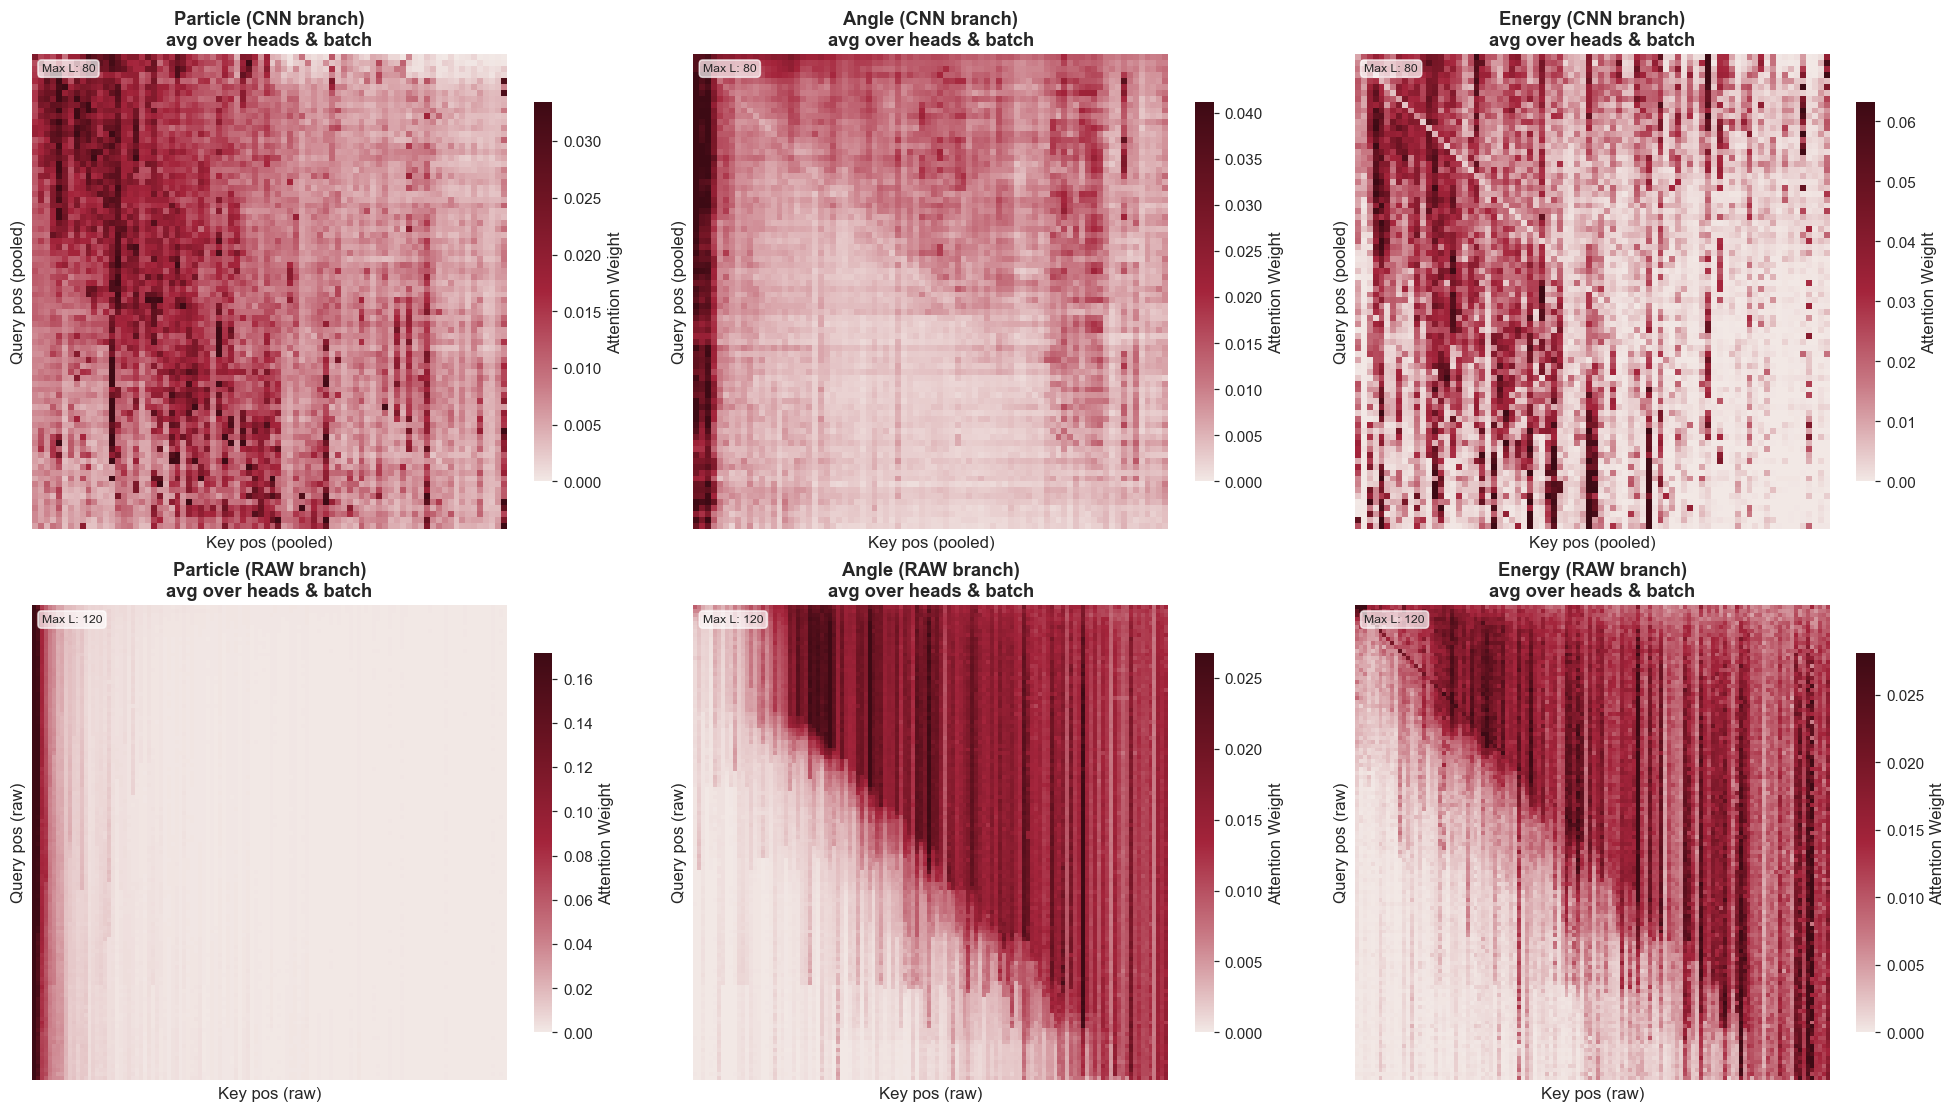

✓ Patrones de atención (CNN vs RAW) guardados en: pipeline_artifacts\diagnostics\attention_patterns_cnn_vs_raw.png


In [42]:
# =======================================================
# Extracción y visualización: atención CNN vs atención RAW
# =======================================================
sample_size = min(200, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_sample = X_test[sample_indices]
Xg_sample = Xg_test[sample_indices]

print(f"Extrayendo attention scores de {sample_size} muestras...")
with tf.device('/GPU:0'):
    (
        attn_class_cnn_scores,
        attn_angle_cnn_scores,
        attn_energy_cnn_scores,
        attn_class_raw_scores,
        attn_angle_raw_scores,
        attn_energy_raw_scores,
    ) = attention_model.predict([X_sample, Xg_sample], batch_size=BATCH_SIZE, verbose=1)

print("Shapes CNN:", attn_class_cnn_scores.shape, attn_angle_cnn_scores.shape, attn_energy_cnn_scores.shape)
print("Shapes RAW:", attn_class_raw_scores.shape, attn_angle_raw_scores.shape, attn_energy_raw_scores.shape)

# Máscaras de padding (longitud real en espacio RAW)
valid_masks_raw = ~np.all(np.isclose(X_sample, 0.0, atol=1e-8), axis=-1)
valid_lengths_raw = valid_masks_raw.sum(axis=-1)  # (batch,)

def average_attention(attn_scores, valid_lengths, max_len=100, pool_factor=1):
    """
    Promedia matrices de atención (batch, heads?, L, L) respetando padding.
    pool_factor=2 para ramas CNN (por MaxPool1D), 1 para RAW.
    """
    if attn_scores.ndim == 4:  # (batch, heads, L, L)
        attn_scores = attn_scores.mean(axis=1)
    batch, L_attn, _ = attn_scores.shape
    max_len = min(max_len, L_attn)
    attn_avg = np.zeros((max_len, max_len))
    count = np.zeros((max_len, max_len))
    for i in range(batch):
        L_eff = int(np.ceil(valid_lengths[i] / pool_factor))
        L_eff = max(0, min(L_eff, L_attn, max_len))
        if L_eff == 0:
            continue
        attn_avg[:L_eff, :L_eff] += attn_scores[i, :L_eff, :L_eff]
        count[:L_eff, :L_eff] += 1
    attn_avg = np.divide(attn_avg, count, where=count > 0)
    attn_avg[count == 0] = np.nan
    return attn_avg

# Promedios
avg_maps = {
    ("CNN", "Particle"): average_attention(attn_class_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2),
    ("CNN", "Angle"):    average_attention(attn_angle_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2),
    ("CNN", "Energy"):   average_attention(attn_energy_cnn_scores, valid_lengths_raw, max_len=80, pool_factor=2),
    ("RAW", "Particle"): average_attention(attn_class_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1),
    ("RAW", "Angle"):    average_attention(attn_angle_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1),
    ("RAW", "Energy"):   average_attention(attn_energy_raw_scores, valid_lengths_raw, max_len=120, pool_factor=1),
}

# Figura 2x3: fila CNN, fila RAW
task_order = ["Particle", "Angle", "Energy"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for col, task in enumerate(task_order):
    # CNN
    ax = axes[0, col]
    m = avg_maps[("CNN", task)]
    vmax = np.nanpercentile(m, 99)
    sns.heatmap(
        m, cmap=CMAP_SEQ, square=True, ax=ax, vmin=0, vmax=vmax,
        cbar_kws={"label": "Attention Weight", "shrink": 0.8},
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(f"{task} (CNN branch)\navg over heads & batch", fontsize=12)
    ax.set_xlabel("Key pos (pooled)")
    ax.set_ylabel("Query pos (pooled)")
    ax.text(0.02, 0.98, f"Max L: {m.shape[0]}", transform=ax.transAxes,
            va="top", ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

    # RAW
    ax = axes[1, col]
    m = avg_maps[("RAW", task)]
    vmax = np.nanpercentile(m, 99)
    sns.heatmap(
        m, cmap=CMAP_SEQ, square=True, ax=ax, vmin=0, vmax=vmax,
        cbar_kws={"label": "Attention Weight", "shrink": 0.8},
        xticklabels=False, yticklabels=False,
    )
    ax.set_title(f"{task} (RAW branch)\navg over heads & batch", fontsize=12)
    ax.set_xlabel("Key pos (raw)")
    ax.set_ylabel("Query pos (raw)")
    ax.text(0.02, 0.98, f"Max L: {m.shape[0]}", transform=ax.transAxes,
            va="top", ha="left", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

plt.savefig(plots_dir / "attention_patterns_cnn_vs_raw.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"✓ Patrones de atención (CNN vs RAW) guardados en: {plots_dir / 'attention_patterns_cnn_vs_raw.png'}")

In [43]:
# Use RAW attention streams for all interpretability analysis.
# RAW branch maps directly to individual detector hits;
# CNN branch introduces pooling that blurs the temporal position.
attn_class_scores = attn_class_raw_scores
attn_angle_scores  = attn_angle_raw_scores
attn_energy_scores = attn_energy_raw_scores
valid_lengths      = valid_lengths_raw

#### Temporal Attention Patterns


2. Analizando importancia temporal de las posiciones...


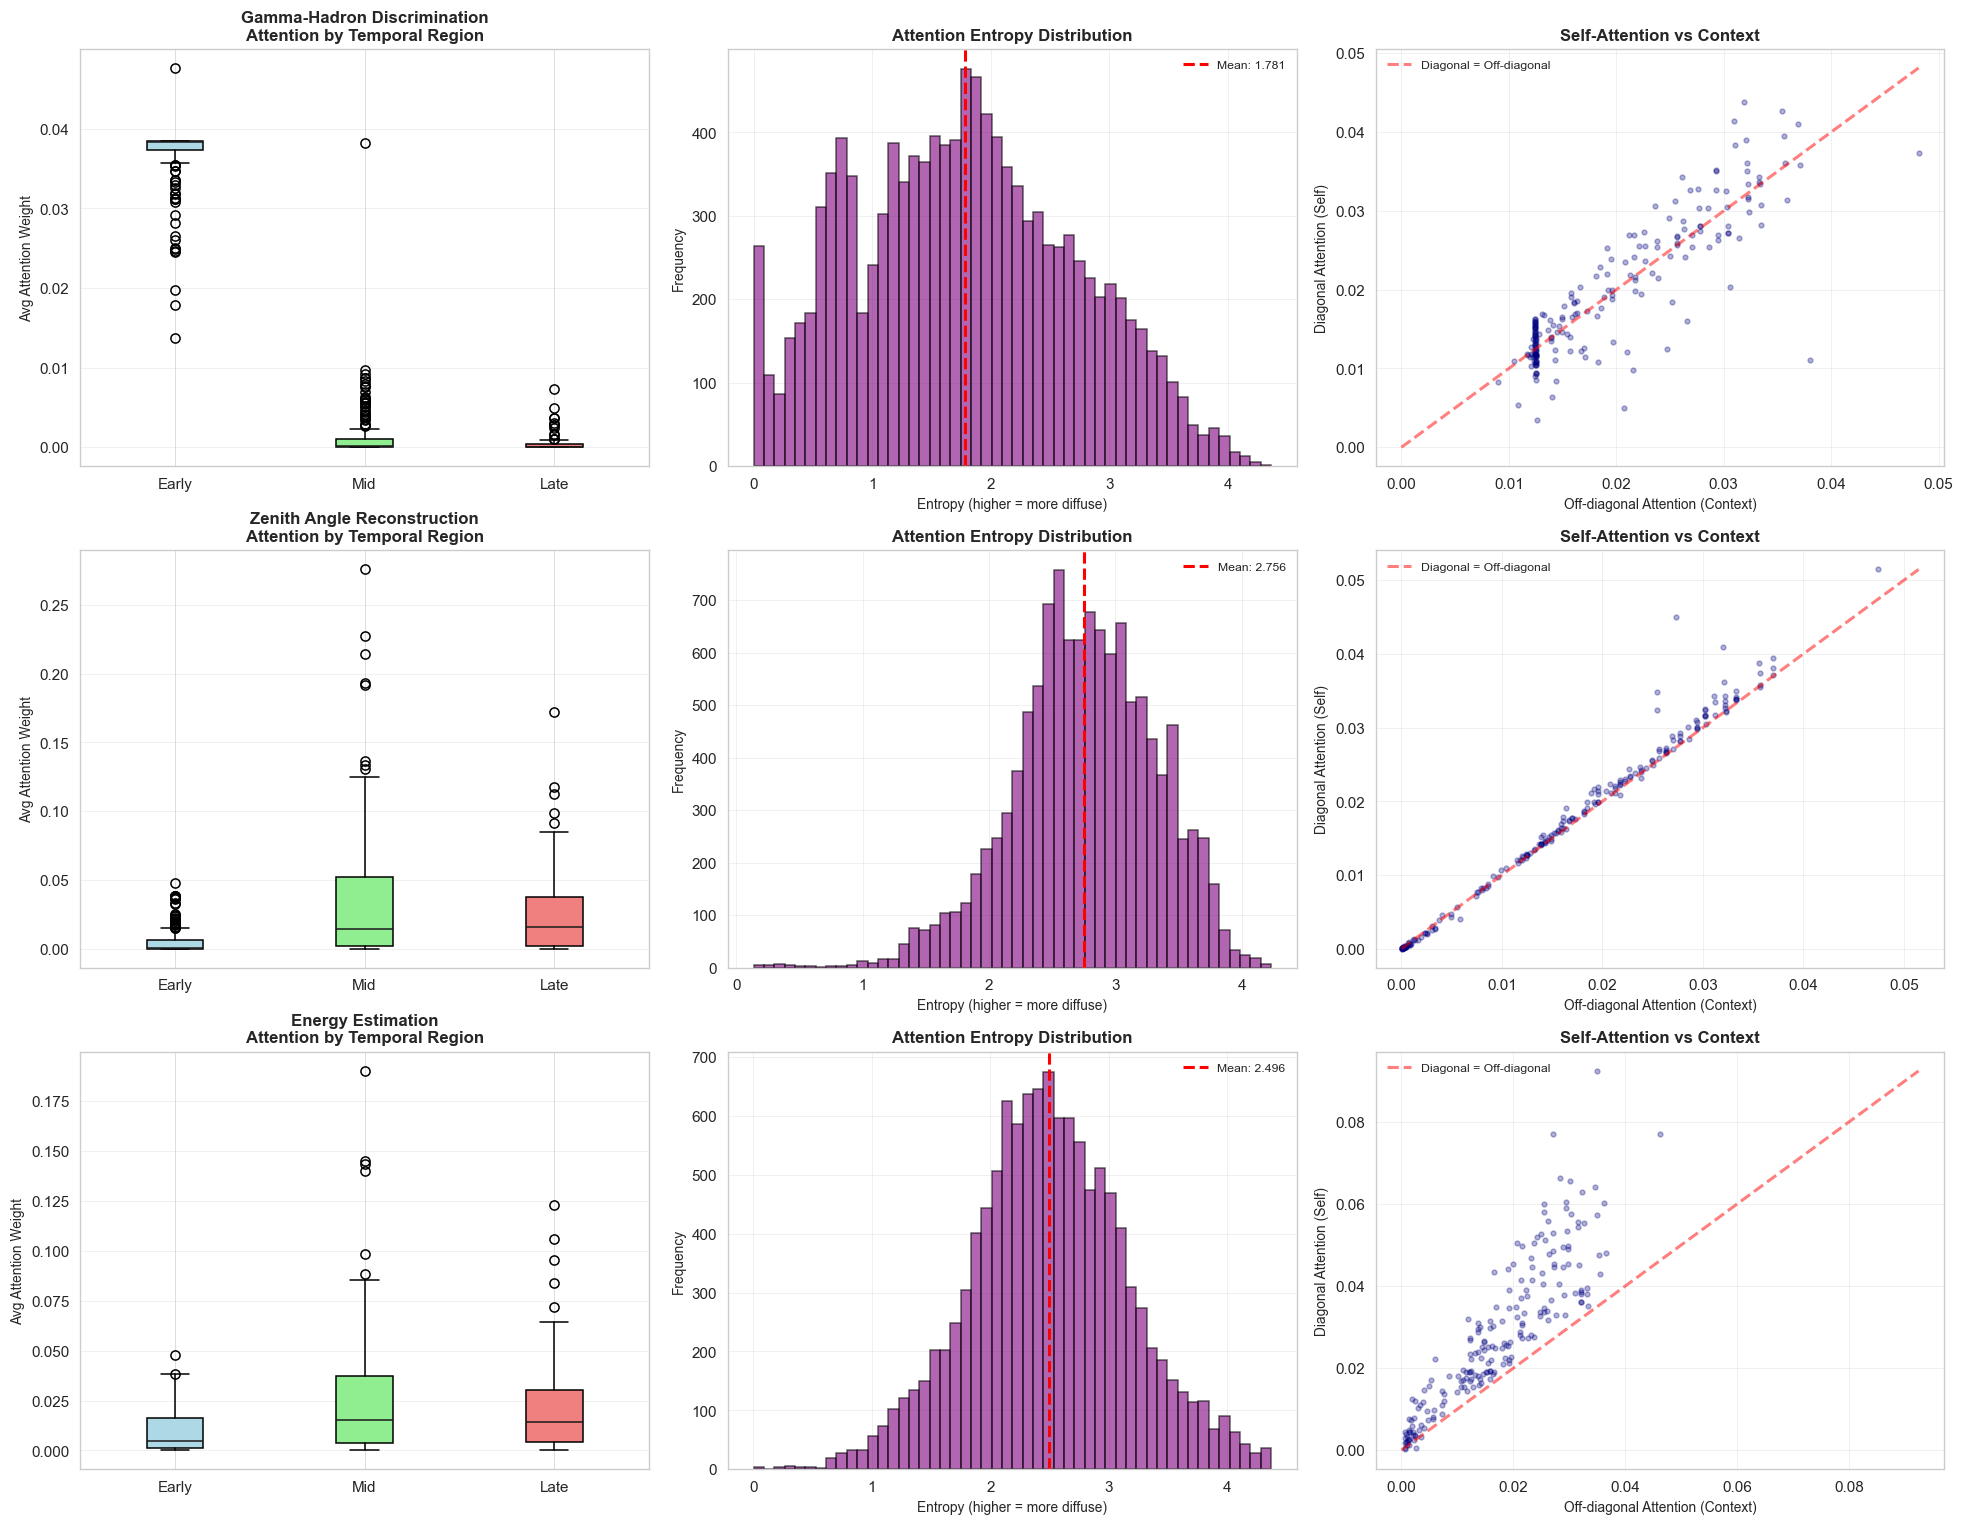

✓ Guardado: pipeline_artifacts\diagnostics\attention_temporal_analysis.png


In [44]:
# 2. ANÁLISIS TEMPORAL: Importancia de posiciones early/mid/late
# ----------------------------- #
print("\n2. Analizando importancia temporal de las posiciones...")

fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for task_idx, (task_name, attn_scores) in enumerate([
    ("Gamma-Hadron Discrimination", attn_class_scores),
    ("Zenith Angle Reconstruction", attn_angle_scores),
    ("Energy Estimation", attn_energy_scores)
]):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    max_len = 80
    early_range = (0, max_len // 3)
    mid_range = (max_len // 3, 2 * max_len // 3)
    late_range = (2 * max_len // 3, max_len)

    early_attn, mid_attn, late_attn = [], [], []

    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 10:
            attn_mat = attn_3d[idx, :L, :L]
            attn_received = attn_mat.mean(axis=0)

            e_end = min(L, early_range[1])
            m_start = min(L, mid_range[0]); m_end = min(L, mid_range[1])
            l_start = min(L, late_range[0])

            if e_end > early_range[0]:
                early_attn.append(np.nanmean(attn_received[early_range[0]:e_end]))
            if m_end > m_start:
                mid_attn.append(np.nanmean(attn_received[m_start:m_end]))
            if L > l_start:
                late_attn.append(np.nanmean(attn_received[l_start:L]))

    # Plot 1: Box plot
    ax1 = axes[task_idx, 0]
    bp = ax1.boxplot([early_attn, mid_attn, late_attn],
                     tick_labels=['Early', 'Mid', 'Late'],
                     patch_artist=True)
    for patch, color in zip(bp['boxes'], ['lightblue', 'lightgreen', 'lightcoral']):
        patch.set_facecolor(color)
    ax1.set_title(f"{task_name}\nAttention by Temporal Region", fontsize=11, fontweight="bold")
    ax1.set_ylabel("Avg Attention Weight", fontsize=9)
    ax1.grid(axis='y', alpha=0.3)

    # Plot 2: Entropía
    ax2 = axes[task_idx, 1]
    entropies = []
    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 5:
            attn_mat = attn_3d[idx, :L, :L]
            for row in attn_mat:
                s = row.sum()
                if s <= 0:
                    continue
                row_norm = row / s
                entropy = -np.sum(row_norm * np.log(row_norm + 1e-12))
                if np.isfinite(entropy):
                    entropies.append(entropy)

    if entropies:
        ax2.hist(entropies, bins=50, color='purple', alpha=0.6, edgecolor='black')
        mean_ent = float(np.mean(entropies))
        ax2.axvline(mean_ent, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_ent:.3f}')
        ax2.legend(fontsize=8)
    ax2.set_title("Attention Entropy Distribution", fontsize=11, fontweight="bold")
    ax2.set_xlabel("Entropy (higher = more diffuse)", fontsize=9)
    ax2.set_ylabel("Frequency", fontsize=9)
    ax2.grid(alpha=0.3)

    # Plot 3: Self vs Context
    ax3 = axes[task_idx, 2]
    diag_strengths, offdiag_strengths = [], []

    for idx in range(len(attn_3d)):
        L = min(int(valid_lengths[idx]), max_len)
        if L > 5:
            attn_mat = attn_3d[idx, :L, :L]
            diag = np.diag(attn_mat).mean()
            mask = ~np.eye(L, dtype=bool)
            offdiag = attn_mat[mask].mean()
            if np.isfinite(diag) and np.isfinite(offdiag):
                diag_strengths.append(diag)
                offdiag_strengths.append(offdiag)

    if diag_strengths and offdiag_strengths:
        ax3.scatter(offdiag_strengths, diag_strengths, alpha=0.3, s=10, color='navy')
        lim = max(offdiag_strengths + diag_strengths)
        ax3.plot([0, lim], [0, lim], 'r--', linewidth=2, alpha=0.5, label='Diagonal = Off-diagonal')
        ax3.legend(fontsize=8)
    ax3.set_xlabel("Off-diagonal Attention (Context)", fontsize=9)
    ax3.set_ylabel("Diagonal Attention (Self)", fontsize=9)
    ax3.set_title("Self-Attention vs Context", fontsize=11, fontweight="bold")
    ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plots_dir / "attention_temporal_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"✓ Guardado: {plots_dir / 'attention_temporal_analysis.png'}")

#### Attention Difference: $\gamma$ vs. Proton

Overlaying many attention curves is hard to read. Instead we plot the **difference**
in mean attention received at each temporal position between gamma and proton events:

$$\Delta A(t) = \bar{A}_\gamma(t) - \bar{A}_\mathrm{proton}(t)$$

Dark red (positive) = the model attends more when the primary is a gamma; ink
(negative) = more for protons. A flat line near zero means the temporal strategy
does not depend on particle type.

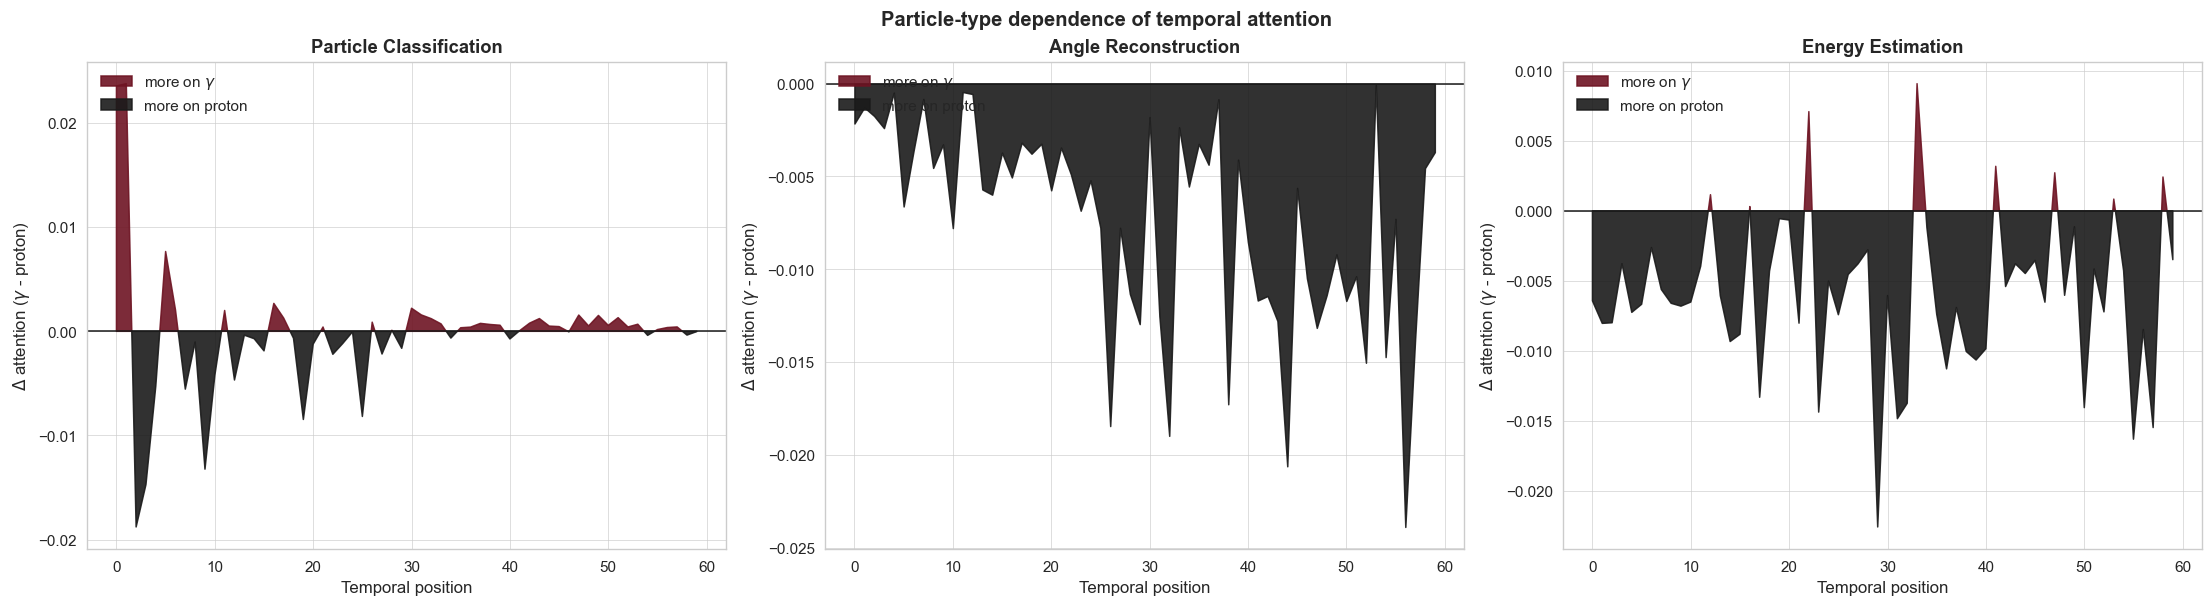

In [45]:
particle_types = pred_summary["particle_true"].values[sample_indices]
is_gamma  = particle_types == 1
is_proton = particle_types == 0


def _as3d(a):
    """Collapse a (events, heads, L, L) attention tensor to (events, L, L)."""
    a = np.asarray(a)
    return a.mean(axis=1) if a.ndim == 4 else a


def mean_attention_profile(attn, valid_lengths, mask, max_len=60):
    """Mean attention received per temporal position, averaged over masked events."""
    attn = _as3d(attn)
    acc = np.zeros(max_len)
    cnt = np.zeros(max_len)
    for mat, L, keep in zip(attn, valid_lengths, mask):
        if not keep:
            continue
        Le = int(min(L, mat.shape[0], max_len))
        if Le <= 0:
            continue
        recv = mat[:Le, :Le].mean(axis=0)
        acc[:Le] += recv
        cnt[:Le] += 1
    return acc / np.maximum(cnt, 1.0)


tasks_attn = [
    ("Particle Classification", attn_class_scores),
    ("Angle Reconstruction", attn_angle_scores),
    ("Energy Estimation", attn_energy_scores),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.4), constrained_layout=True)
for ax, (title, attn) in zip(axes, tasks_attn):
    prof_g = mean_attention_profile(attn, valid_lengths, is_gamma)
    prof_p = mean_attention_profile(attn, valid_lengths, is_proton)
    diff = prof_g - prof_p
    x = np.arange(len(diff))
    ax.axhline(0, color=CONDOR_INK, lw=1.0)
    ax.fill_between(x, diff, 0, where=diff >= 0, color=CONDOR_DARKRED, alpha=0.9,
                    interpolate=True, label=r"more on $\gamma$")
    ax.fill_between(x, diff, 0, where=diff < 0, color=CONDOR_INK, alpha=0.9,
                    interpolate=True, label="more on proton")
    ax.set_title(title)
    ax.set_xlabel("Temporal position")
    ax.set_ylabel(r"$\Delta$ attention ($\gamma$ - proton)")
    ax.legend(loc="upper left")
fig.suptitle("Particle-type dependence of temporal attention", fontweight="bold")
fig.savefig(plots_dir / "attention_difference_temporal.png", dpi=SAVE_DPI)
plt.show()

#### Spatial Attention Maps


[1] ANÁLISIS ESPACIAL: Mapeo de importancia por detector

Particle Classification:
  Detectores analizados: 120
  Incluye detector_id=0: True
  Atención promedio: 0.005007 ± 0.007819

Angle Reconstruction:
  Detectores analizados: 120
  Incluye detector_id=0: True
  Atención promedio: 0.004886 ± 0.005382

Energy Estimation:
  Detectores analizados: 120
  Incluye detector_id=0: True
  Atención promedio: 0.005113 ± 0.006728


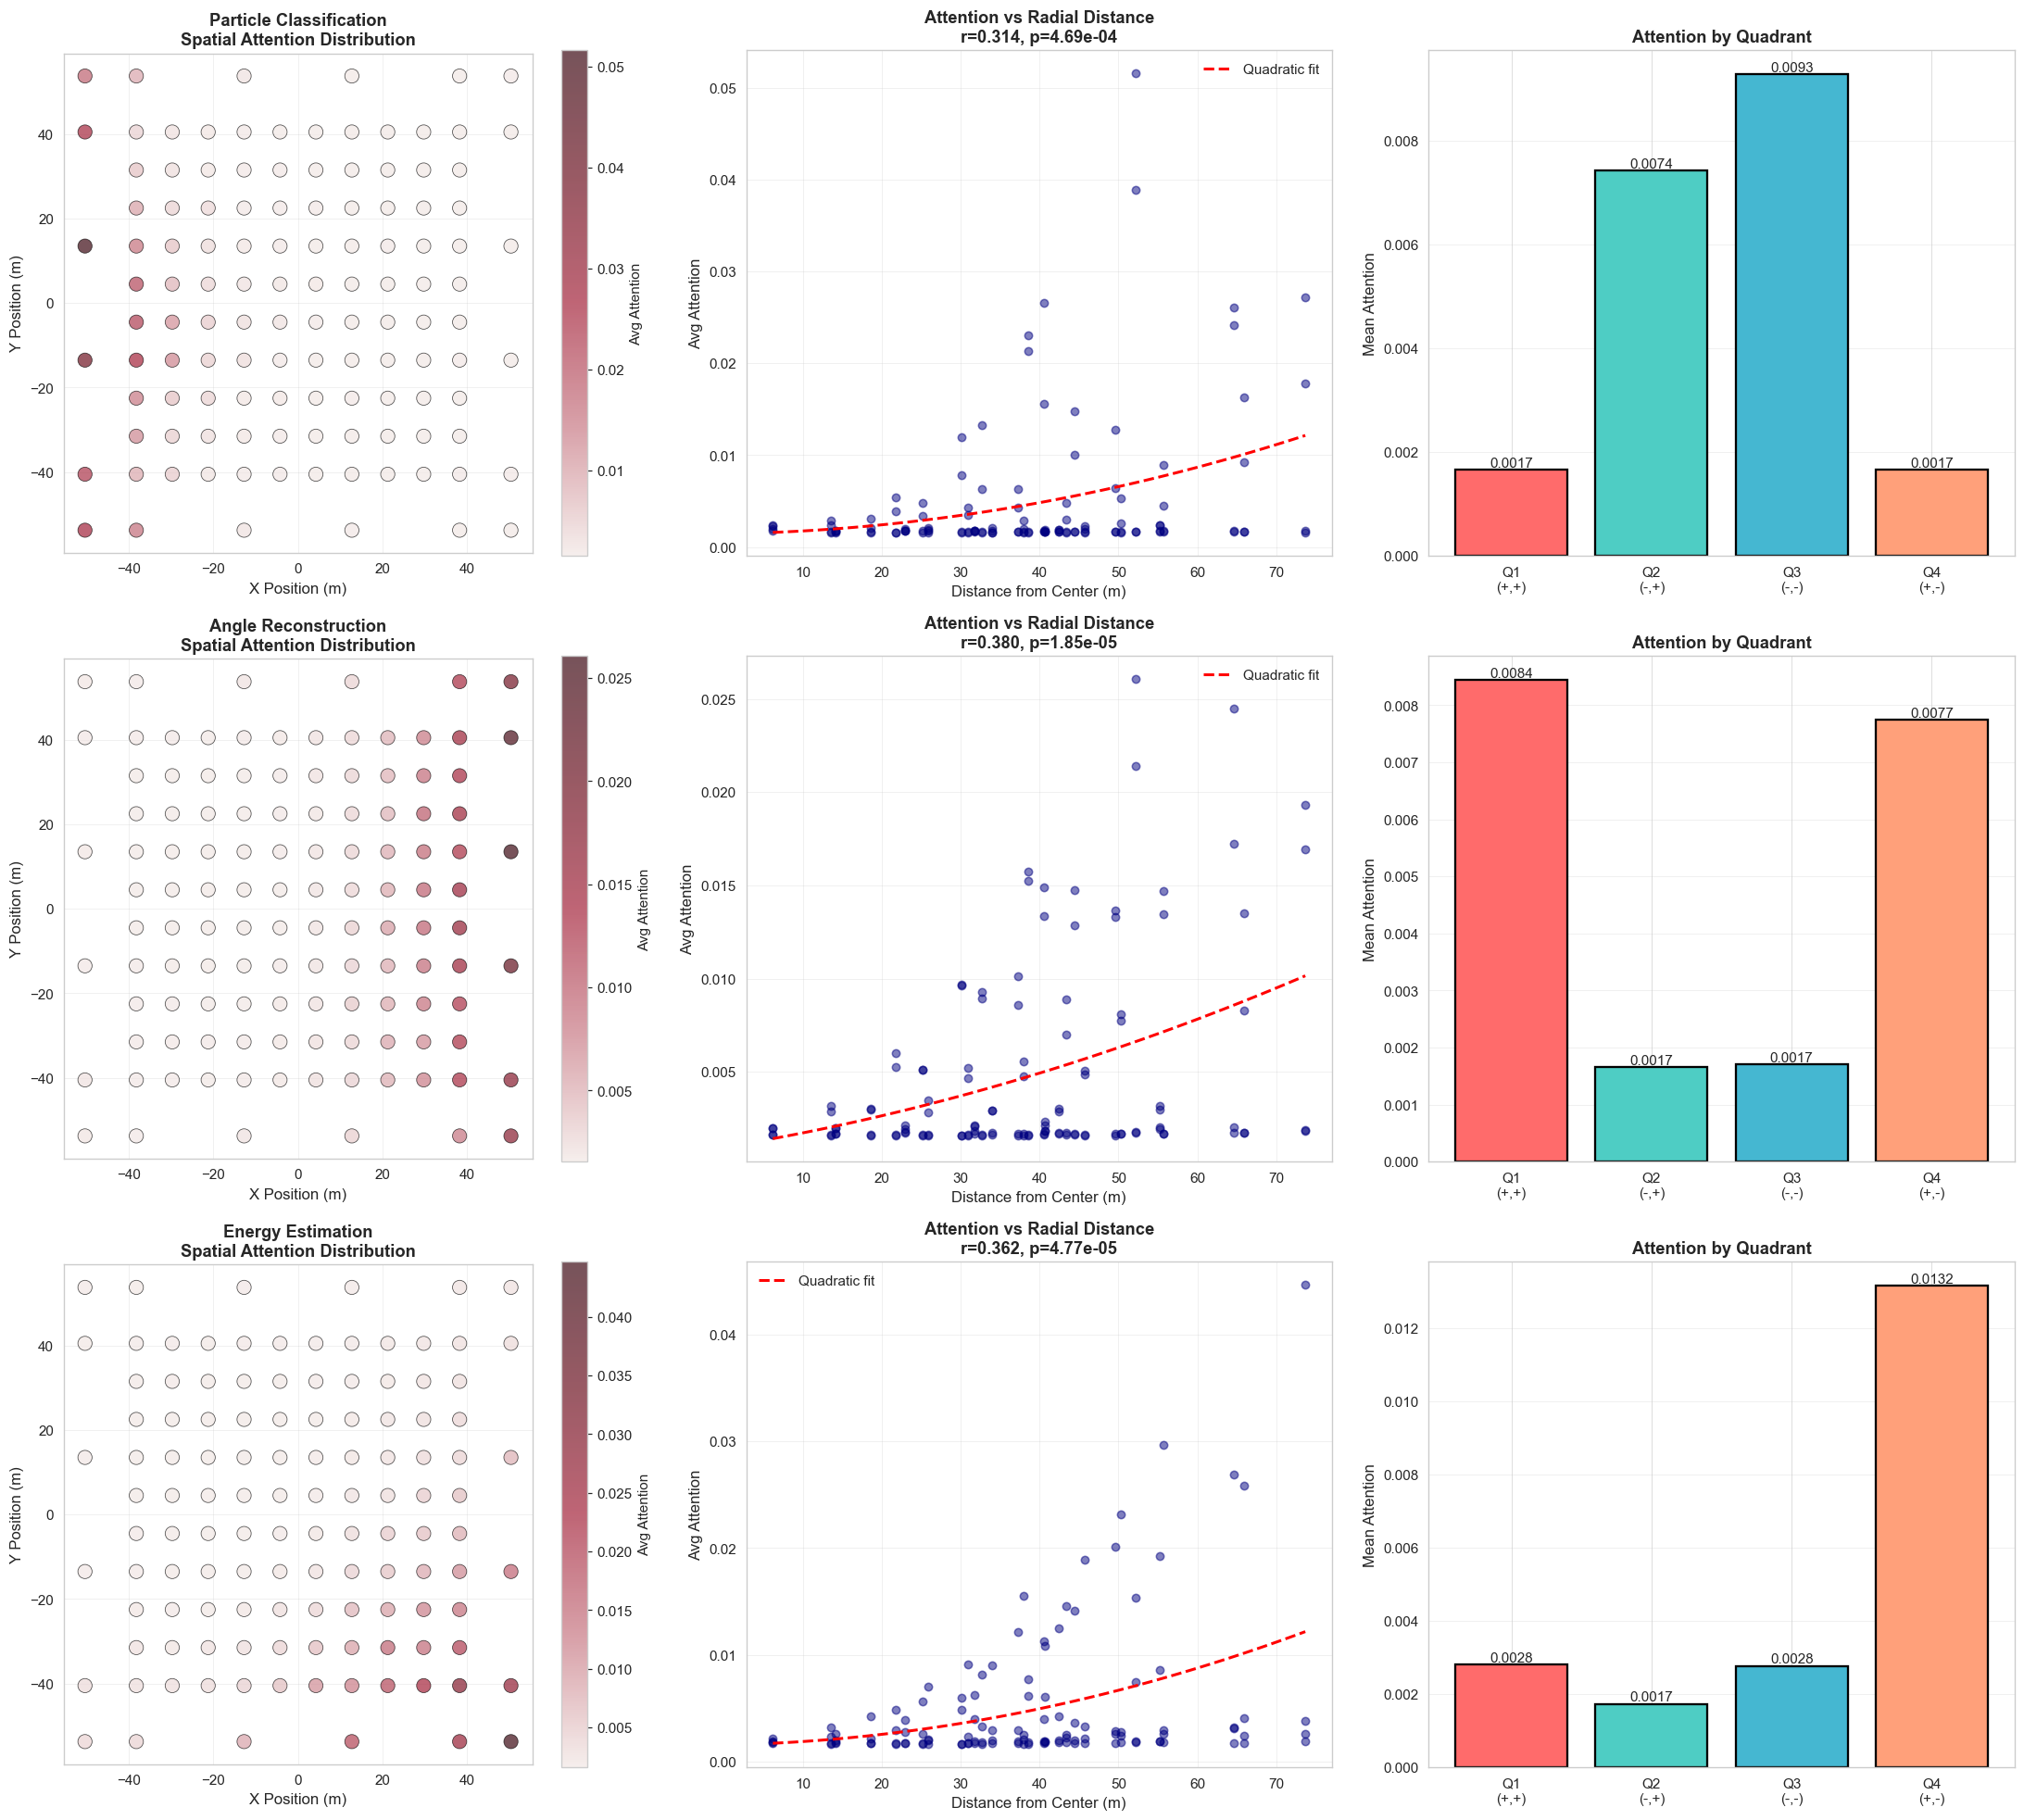


✓ Guardado: pipeline_artifacts\diagnostics\attention_spatial_analysis.png


In [46]:
# ============================================================
# ANÁLISIS DE EXPLICABILIDAD FÍSICA: CNN-TRANSFORMER ESPACIOTEMPORAL
# ============================================================
# Contexto: Detectores CONDOR capturan cascadas atmosféricas extensas (EAS)
# Features: detector_id, particle_count, t_bin, total_energy, x_center, y_center
# Arquitectura: CNN (extracción temporal) → Transformer (atención) → 3 heads (particle/angle/energy)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.gridspec import GridSpec
from scipy.stats import pearsonr, spearmanr
from sklearn.decomposition import PCA

# ============================================================
# 1. ANÁLISIS ESPACIAL: ¿Qué regiones del detector son importantes?
# ============================================================
print("\n[1] ANÁLISIS ESPACIAL: Mapeo de importancia por detector")

# Reconstruir posiciones espaciales desde el catálogo
detector_positions = detector_catalog.set_index('detector_id')[['x_center', 'y_center']].to_dict('index')

# Para cada tarea, calcular qué detectores reciben más atención
fig, axes = plt.subplots(3, 3, figsize=(20, 18))

for task_idx, (task_name, attn_scores, ax_row) in enumerate([
    ("Particle Classification", attn_class_scores, axes[0]),
    ("Angle Reconstruction", attn_angle_scores, axes[1]),
    ("Energy Estimation", attn_energy_scores, axes[2]),
]):
    attn_3d = attn_scores.mean(axis=1) if attn_scores.ndim == 4 else attn_scores

    detector_importance = {}
    detector_count = {}

    for idx in range(len(X_sample)):
        seq = X_sample[idx]
        L = int(valid_lengths[idx])

        if L <= 5:
            continue

        attn_mat = attn_3d[idx]
        attn_len = attn_mat.shape[0]

        # Factor de pooling dinámico (1 para RAW, 2 para CNN pooled)
        pool_factor = max(1, int(np.ceil(L / max(1, attn_len))))

        # Atención recibida (promedio sobre queries), saneando NaN/inf
        attn_received = attn_mat.mean(axis=0)
        attn_received = np.where(np.isfinite(attn_received), attn_received, np.nan)
        if attn_received.size == 0:
            continue

        max_t = min(attn_len, int(np.ceil(L / pool_factor)))
        for t_pos in range(max_t):
            seq_idx = min(int(t_pos * pool_factor), L - 1)
            det_id = int(seq[seq_idx, 0])

            if det_id >= 0 and det_id in detector_positions:
                if det_id not in detector_importance:
                    detector_importance[det_id] = 0.0
                    detector_count[det_id] = 0
                if t_pos < len(attn_received):
                    val = attn_received[t_pos]
                    if np.isfinite(val):
                        detector_importance[det_id] += val
                        detector_count[det_id] += 1

    for det_id in list(detector_importance):
        if detector_count[det_id] > 0:
            detector_importance[det_id] /= detector_count[det_id]
        else:
            detector_importance.pop(det_id, None)

    if len(detector_importance) == 0:
        print(f"⚠ Warning: No hay datos de importancia de detectores para {task_name}")
        continue

    detector_ids = list(detector_importance.keys())
    x_coords = [detector_positions[d]['x_center'] for d in detector_ids]
    y_coords = [detector_positions[d]['y_center'] for d in detector_ids]
    importances = np.array([detector_importance[d] for d in detector_ids], dtype=float)

    print(f"\n{task_name}:")
    print(f"  Detectores analizados: {len(detector_ids)}")
    print(f"  Incluye detector_id=0: {0 in detector_ids}")
    print(f"  Atención promedio: {np.nanmean(importances):.6f} ± {np.nanstd(importances):.6f}")

    scatter = ax_row[0].scatter(x_coords, y_coords, c=importances, s=100,
                                cmap=CMAP_SEQ, alpha=0.7, edgecolors='black', linewidth=0.5)
    ax_row[0].set_xlabel("X Position (m)", fontsize=11)
    ax_row[0].set_ylabel("Y Position (m)", fontsize=11)
    ax_row[0].set_title(f"{task_name}\nSpatial Attention Distribution", fontsize=12, fontweight='bold')
    ax_row[0].grid(alpha=0.3)
    ax_row[0].set_aspect('equal')
    cbar = plt.colorbar(scatter, ax=ax_row[0])
    cbar.set_label("Avg Attention", fontsize=10)

    distances = np.sqrt(np.array(x_coords)**2 + np.array(y_coords)**2)
    ax_row[1].scatter(distances, importances, alpha=0.5, s=30, color='navy')

    if len(distances) > 3:
        z = np.polyfit(distances, importances, 2)
        p = np.poly1d(z)
        x_fit = np.linspace(distances.min(), distances.max(), 100)
        ax_row[1].plot(x_fit, p(x_fit), "r--", linewidth=2, label='Quadratic fit')

    if len(distances) > 1:
        corr, pval = pearsonr(distances, importances)
    else:
        corr, pval = np.nan, np.nan

    ax_row[1].set_xlabel("Distance from Center (m)", fontsize=11)
    ax_row[1].set_ylabel("Avg Attention", fontsize=11)
    ax_row[1].set_title(f"Attention vs Radial Distance\nr={corr:.3f}, p={pval:.2e}",
                        fontsize=12, fontweight='bold')
    ax_row[1].legend()
    ax_row[1].grid(alpha=0.3)

    ax_row[2].set_title("Attention by Quadrant", fontsize=12, fontweight='bold')
    quadrants = {'Q1 (+,+)': [], 'Q2 (-,+)': [], 'Q3 (-,-)': [], 'Q4 (+,-)': []}
    for x, y, imp in zip(x_coords, y_coords, importances):
        if x >= 0 and y >= 0:
            quadrants['Q1 (+,+)'].append(imp)
        elif x < 0 and y >= 0:
            quadrants['Q2 (-,+)'].append(imp)
        elif x < 0 and y < 0:
            quadrants['Q3 (-,-)'].append(imp)
        else:
            quadrants['Q4 (+,-)'].append(imp)

    quad_means = [np.nanmean(quadrants[q]) if len(quadrants[q]) > 0 else 0
                  for q in ['Q1 (+,+)', 'Q2 (-,+)', 'Q3 (-,-)', 'Q4 (+,-)']]

    colors_quad = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
    bars = ax_row[2].bar(range(4), quad_means, color=colors_quad, edgecolor='black', linewidth=1.5)
    ax_row[2].set_xticks(range(4))
    ax_row[2].set_xticklabels(['Q1\n(+,+)', 'Q2\n(-,+)', 'Q3\n(-,-)', 'Q4\n(+,-)'])
    ax_row[2].set_ylabel("Mean Attention", fontsize=11)
    ax_row[2].grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax_row[2].text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(plots_dir / "attention_spatial_analysis.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"\n✓ Guardado: {plots_dir / 'attention_spatial_analysis.png'}")

#### Spatial Attention Difference: $\gamma$ vs. Proton

Per-detector attention is computed **separately** for gamma and proton events,
each normalised to sum to one, and then subtracted. Dark-red detectors receive more
attention when the primary is a gamma; ink detectors receive more for protons.
This shows **where on the array** the model's focus depends on particle type — the
most physically direct of the attention diagnostics.

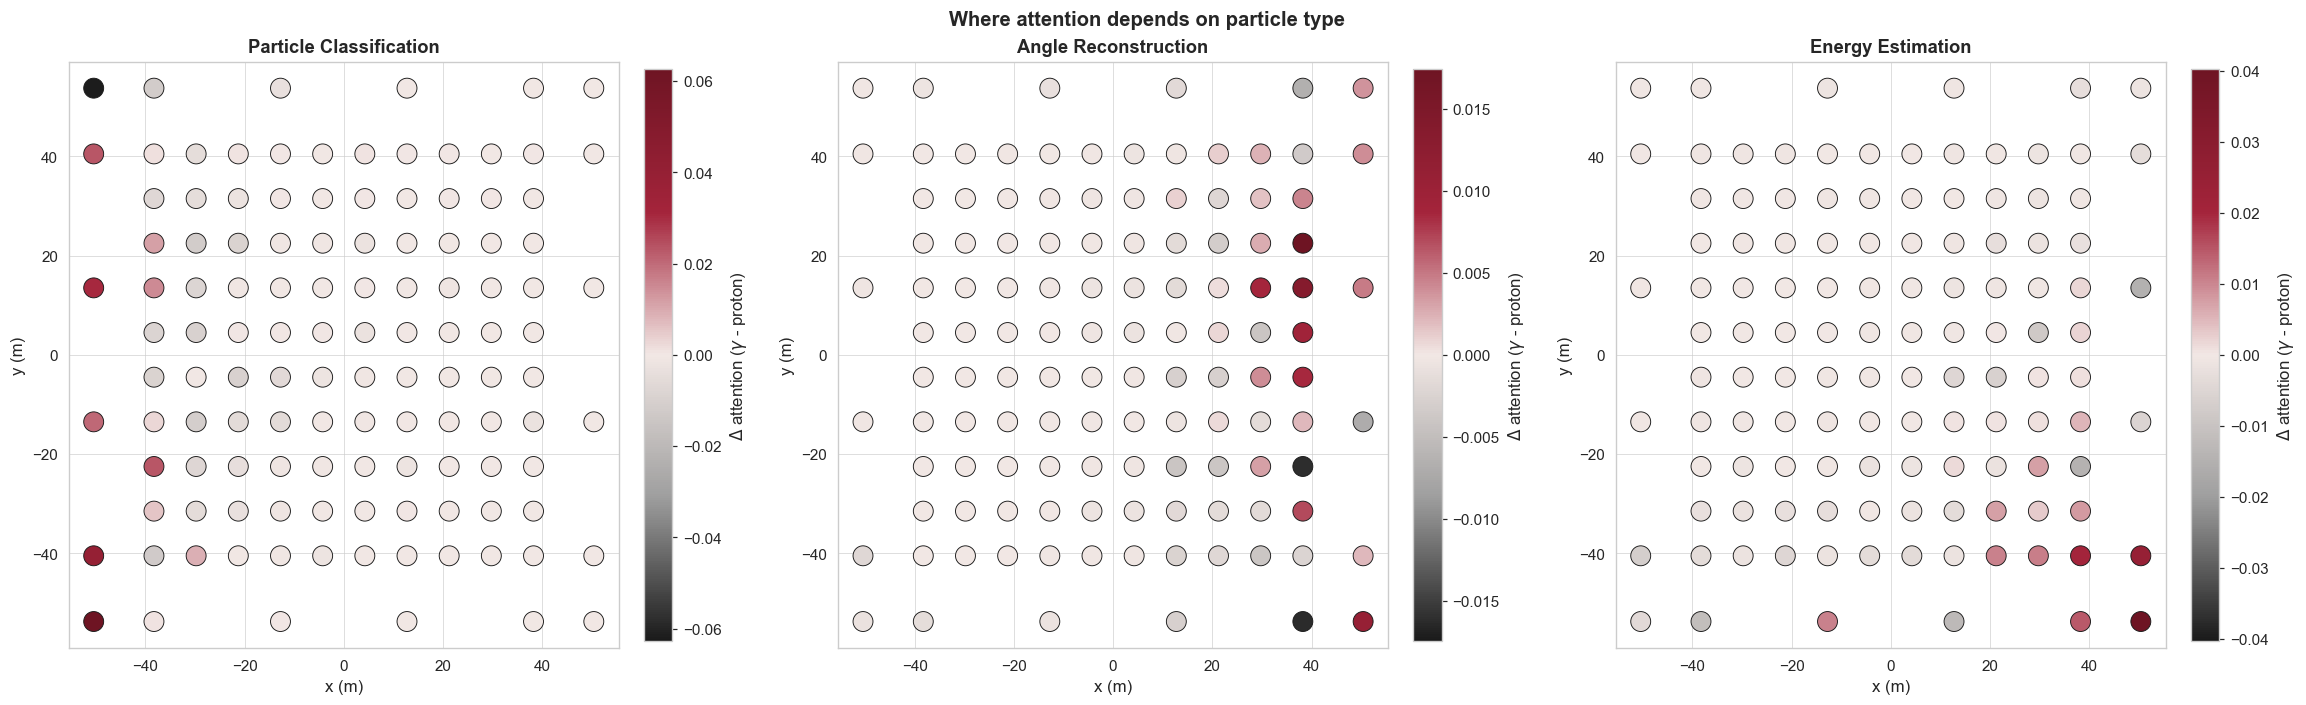

In [47]:
def per_detector_attention(attn, sequences, valid_lengths, mask, max_len=120):
    """Mean attention received per detector_id, over the masked events; sum-normalised."""
    attn = _as3d(attn)
    acc, cnt = {}, {}
    for mat, seq, L, keep in zip(attn, sequences, valid_lengths, mask):
        if not keep:
            continue
        Le = int(min(L, mat.shape[0], seq.shape[0], max_len))
        if Le <= 0:
            continue
        recv = mat[:Le, :Le].mean(axis=0)
        for t in range(Le):
            det = int(seq[t, FEATURE_IDX["detector_id"]])
            acc[det] = acc.get(det, 0.0) + float(recv[t])
            cnt[det] = cnt.get(det, 0) + 1
    imp = {d: acc[d] / cnt[d] for d in acc}
    total = sum(imp.values()) or 1.0
    return {d: v / total for d, v in imp.items()}


pos = detector_catalog.set_index("detector_id")[["x_center", "y_center"]]
fig, axes = plt.subplots(1, 3, figsize=(21, 6.3), constrained_layout=True)
for ax, (title, attn) in zip(axes, tasks_attn):
    att_g = per_detector_attention(attn, X_sample, valid_lengths, is_gamma)
    att_p = per_detector_attention(attn, X_sample, valid_lengths, is_proton)
    dets = sorted(set(att_g) | set(att_p))
    diff = np.array([att_g.get(d, 0.0) - att_p.get(d, 0.0) for d in dets])
    xs = np.array([pos.loc[d, "x_center"] for d in dets])
    ys = np.array([pos.loc[d, "y_center"] for d in dets])
    vmax = float(np.abs(diff).max()) or 1e-9
    sc = ax.scatter(xs, ys, c=diff, cmap=CMAP_DIV, vmin=-vmax, vmax=vmax,
                    s=170, edgecolor=CONDOR_INK, linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(r"$\Delta$ attention ($\gamma$ - proton)")
fig.suptitle("Where attention depends on particle type", fontweight="bold")
fig.savefig(plots_dir / "attention_difference_spatial.png", dpi=SAVE_DPI)
plt.show()

#### Top-Attention Detector Hits

In [48]:
# --- Top-k hits más influyentes por evento (RAW) ---
import pandas as pd

FEATURE_IDX = {"detector_id": 0, "particle_count": 1, "t_bin": 2, "total_energy": 3, "x_center": 4, "y_center": 5}

def topk_attention_hits(attn_scores, sequences, valid_lengths, k=5):
    """Devuelve lista de dataframes con los k hits con mayor atención recibida por evento."""
    if attn_scores.ndim == 4:
        attn_scores = attn_scores.mean(axis=1)
    results = []
    for mat, seq, L in zip(attn_scores, sequences, valid_lengths):
        L = int(min(L, mat.shape[0], seq.shape[0]))
        if L <= 0:
            results.append(pd.DataFrame())
            continue
        attn_recv = mat[:L, :L].mean(axis=0)
        top_idx = np.argsort(attn_recv)[::-1][:k]
        rows = []
        for idx in top_idx:
            rows.append({
                "rank": len(rows)+1,
                "attention": float(attn_recv[idx]),
                "detector_id": int(seq[idx, FEATURE_IDX["detector_id"]]),
                "t_bin": float(seq[idx, FEATURE_IDX["t_bin"]]),
                "particle_count": float(seq[idx, FEATURE_IDX["particle_count"]]),
                "total_energy": float(seq[idx, FEATURE_IDX["total_energy"]]),
                "x_center": float(seq[idx, FEATURE_IDX["x_center"]]),
                "y_center": float(seq[idx, FEATURE_IDX["y_center"]]),
            })
        results.append(pd.DataFrame(rows))
    return results

topk_particle = topk_attention_hits(attn_class_raw_scores, X_sample, valid_lengths_raw, k=5)

# Ejemplo: mostrar primer evento y guardar CSV
if topk_particle and not topk_particle[0].empty:
    display(topk_particle[0])
all_topk = pd.concat(topk_particle, keys=range(len(topk_particle)), names=["event_idx"])
all_topk.to_csv(plots_dir / "topk_attention_hits_particle.csv")
print(f"✓ Guardado: {plots_dir / 'topk_attention_hits_particle.csv'}")

,rank,attention,detector_id,t_bin,particle_count,total_energy,x_center,y_center
0,1,0.892722,111,14.0,1.0,0.021692,-50.400002,-13.5
1,2,0.096199,33,71.0,1.0,71.068512,-12.750000,-13.5
2,3,0.006006,10,39.0,1.0,0.093823,-29.750000,-40.5
3,4,0.000800,12,61.0,1.0,0.007868,-29.750000,-22.5
4,5,0.000772,16,56.0,1.0,0.005496,-29.750000,13.5


✓ Guardado: pipeline_artifacts\diagnostics\topk_attention_hits_particle.csv


## 6. Detector Robustness and Array Optimisation

The CONDOR array is still in its design phase, so two questions matter beyond raw
accuracy. This section answers them by **switching detectors off at inference time** —
removing all of their hits from the test events and recomputing the event-level
global features — and re-evaluating the *already trained* model (no retraining).

- **Fault tolerance.** How many detectors can fail before reconstruction degrades?
  Which detectors, individually or as groups, carry the most information?
- **Array design.** For a fixed number of detectors, is a denser-but-smaller array
  better than a sparser-but-wider one?

> Each off-configuration is one full forward pass. The cells below run a few hundred
> of them on a test subsample — expect roughly **10-15 min** on an RTX 3050 Ti.
> Tune `DROPOUT_SUBSAMPLE` to trade speed for precision.

In [49]:
# Unpadded test-set sequences, aligned with the y_*_test arrays
test_sequences = [X_sequences[i] for i in test_idx]

# Subsample for speed - every off-configuration is a full forward pass
DROPOUT_SUBSAMPLE = 3000          # set to None to use the whole test set
rng_drop = np.random.default_rng(SEED)
if DROPOUT_SUBSAMPLE and DROPOUT_SUBSAMPLE < len(test_sequences):
    _sel = np.sort(rng_drop.choice(len(test_sequences), DROPOUT_SUBSAMPLE, replace=False))
else:
    _sel = np.arange(len(test_sequences))

drop_sequences = [test_sequences[i] for i in _sel]
drop_label  = y_label_test[_sel].astype(int)
drop_angle  = y_angle_test[_sel].astype(float)
drop_energy = y_energy_test_cont[_sel].astype(float)
print(f"Detector-dropout evaluation set: {len(drop_sequences)} events")

# Section 6 uses a reduced inference batch size to avoid OOM from memory fragmentation.
# Root cause: after 200+ sequential forward passes the GPU allocator can no longer
# find a contiguous block for the RAW attention tensor [batch, 1, 472, 472].
# Reducing from BATCH_SIZE=32 → DROPOUT_BATCH_SIZE=8 shrinks the peak contiguous
# allocation from 28.4 MB to 7.1 MB per stream, which fits even in a fragmented pool.
DROPOUT_BATCH_SIZE = 8


def evaluate_with_detectors_off(off_ids):
    """Drop all hits from off_ids, recompute global features, return task metrics.

    Events that lose ALL their hits after detector removal are excluded from the
    evaluation — passing all-zero sequences to the model produces NaN predictions
    due to numerical edge cases in LayerNorm / attention on zero-only input.
    Metrics are therefore computed on the subset of events that still have >= 1 hit.
    """
    off = np.asarray(list(off_ids), dtype=np.int32)
    mod, keep = [], []
    for seq in drop_sequences:
        filtered = seq if (off.size == 0 or seq.size == 0) else \
                   seq[~np.isin(seq[:, 0].astype(np.int32), off)]
        mod.append(filtered)
        keep.append(filtered.size > 0)
    keep = np.array(keep, dtype=bool)

    mod_v  = [m for m, k in zip(mod, keep) if k]
    lbl_v  = drop_label[keep]
    ang_v  = drop_angle[keep]
    en_v   = drop_energy[keep]

    _NAN = {k: np.nan for k in ("particle_acc", "particle_auc", "angle_mae", "energy_mae")}
    if len(mod_v) == 0:
        return _NAN

    Xg = compute_global_features(mod_v, central_ids)
    Xs = pad_sequences(mod_v, maxlen=max_sequence_length, padding="post", dtype="float32")
    p_part, p_ang, p_en = model.predict([Xs, Xg], batch_size=DROPOUT_BATCH_SIZE, verbose=0)
    p_part = p_part.ravel()
    p_ang  = p_ang.ravel()
    en_gev = p_en.ravel() * energy_std + energy_mean
    gc.collect()  # release Python-side tensor wrappers between repeated predict calls

    # Safety net: discard any residual NaN/Inf predictions
    ok = np.isfinite(p_part) & np.isfinite(p_ang) & np.isfinite(en_gev)
    if ok.sum() == 0:
        return _NAN
    p_part, p_ang, en_gev = p_part[ok], p_ang[ok], en_gev[ok]
    lbl_v, ang_v, en_v   = lbl_v[ok], ang_v[ok], en_v[ok]

    # roc_auc_score requires both classes to be present
    auc_val = (float(roc_auc_score(lbl_v, p_part))
               if len(np.unique(lbl_v)) == 2 else np.nan)

    return {
        "particle_acc": float(np.mean((p_part > 0.5).astype(int) == lbl_v)),
        "particle_auc": auc_val,
        "angle_mae":    float(np.mean(np.abs(p_ang - ang_v))),
        "energy_mae":   float(np.mean(np.abs(en_gev - en_v))),
    }


baseline = evaluate_with_detectors_off([])
print("Baseline (all detectors on):")
print(f"  particle accuracy : {baseline['particle_acc']:.4f}")
print(f"  particle AUC      : {baseline['particle_auc']:.4f}")
print(f"  angle MAE         : {baseline['angle_mae']:.4f} deg")
print(f"  energy MAE        : {baseline['energy_mae']:.2f} GeV")

Detector-dropout evaluation set: 3000 events
Baseline (all detectors on):
  particle accuracy : 0.9667
  particle AUC      : 0.9896
  angle MAE         : 0.4865 deg
  energy MAE        : 106.51 GeV


### 6.1. Single-Detector Importance

Each detector is switched off **on its own** and the degradation is mapped back onto
the array geometry. Bright cells mark detectors whose loss hurts the model most -
the spatial pattern reveals which regions carry the discriminative information.

  evaluated 25/120 detectors
  evaluated 50/120 detectors
  evaluated 75/120 detectors
  evaluated 100/120 detectors


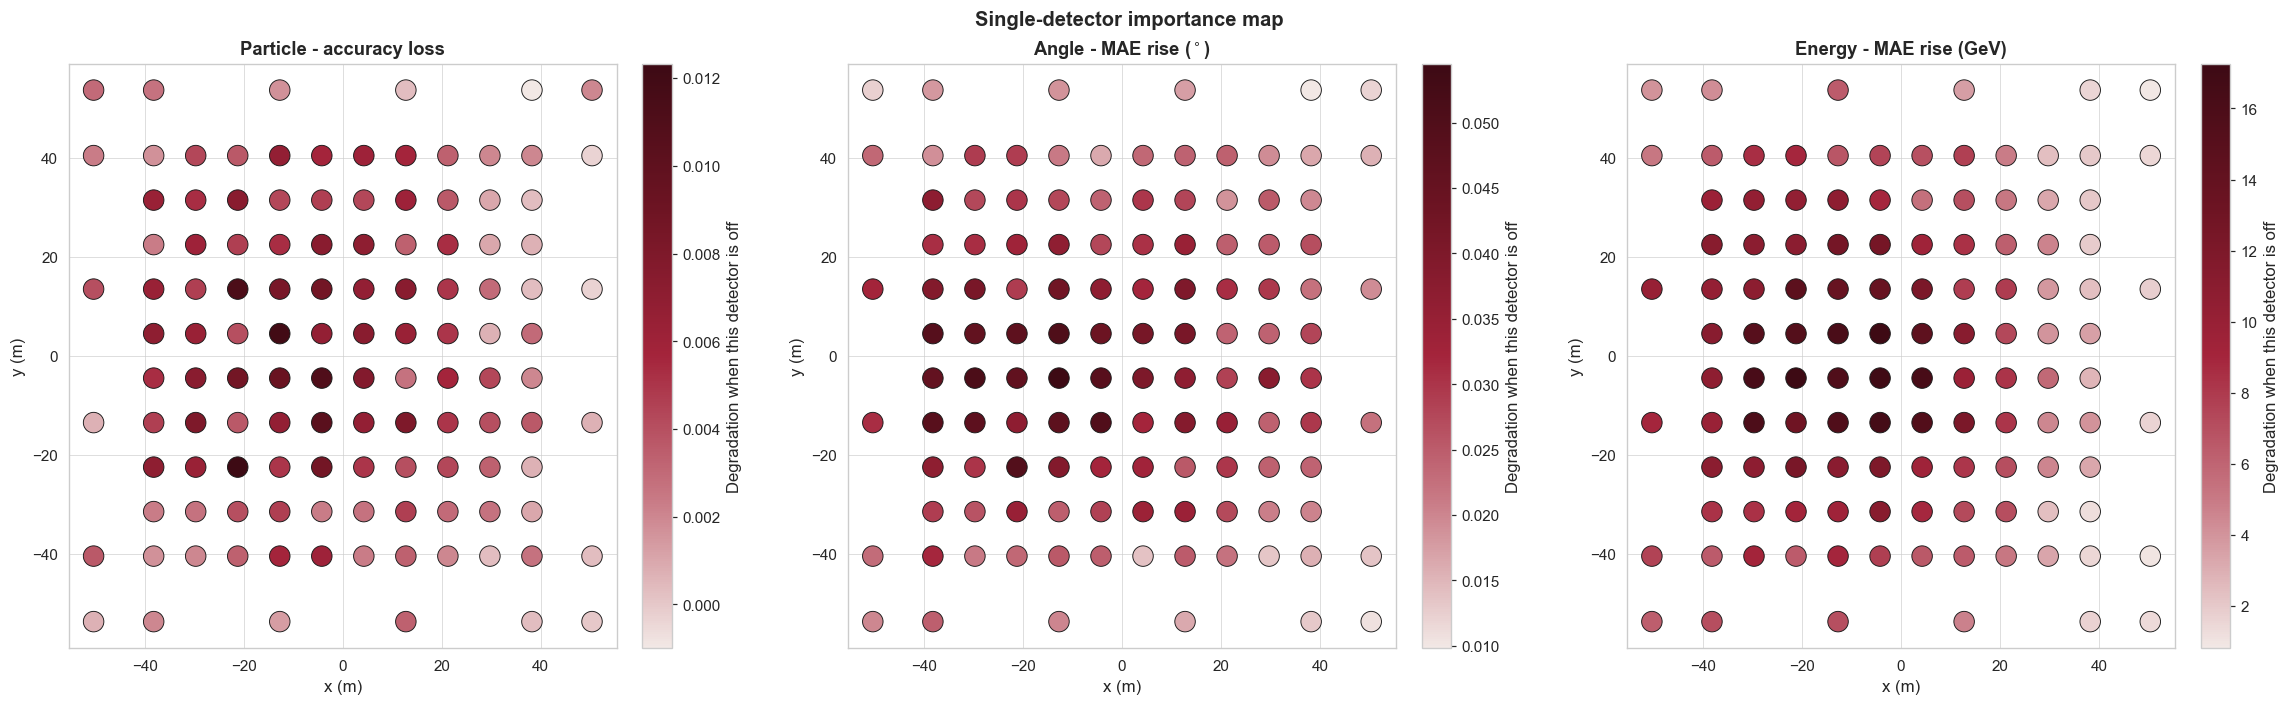

Most critical single detectors (by accuracy loss):


,detector_id,acc_drop,angle_rise,energy_rise
22,22,0.0123,0.0494,12.2592
35,35,0.0120,0.0504,16.1421
26,26,0.0113,0.0291,14.6817
44,44,0.0110,0.0483,16.9723
43,43,0.0103,0.0499,16.5335


In [50]:
all_detectors = detector_catalog["detector_id"].astype(int).tolist()
single_rows = []
for k, det in enumerate(all_detectors):
    single_rows.append({"detector_id": det, **evaluate_with_detectors_off([det])})
    if (k + 1) % 25 == 0:
        print(f"  evaluated {k + 1}/{len(all_detectors)} detectors")

single_df = pd.DataFrame(single_rows).merge(
    detector_catalog[["detector_id", "x_center", "y_center"]], on="detector_id")
single_df["acc_drop"]    = baseline["particle_acc"] - single_df["particle_acc"]
single_df["angle_rise"]  = single_df["angle_mae"]  - baseline["angle_mae"]
single_df["energy_rise"] = single_df["energy_mae"] - baseline["energy_mae"]

maps = [("acc_drop", "Particle - accuracy loss"),
        ("angle_rise", r"Angle - MAE rise ($^\circ$)"),
        ("energy_rise", "Energy - MAE rise (GeV)")]
fig, axes = plt.subplots(1, 3, figsize=(21, 6.3), constrained_layout=True)
for ax, (col, title) in zip(axes, maps):
    sc = ax.scatter(single_df["x_center"], single_df["y_center"],
                    c=single_df[col].to_numpy(), cmap=CMAP_SEQ,
                    s=180, edgecolor=CONDOR_INK, linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("y (m)")
    ax.set_aspect("equal")
    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("Degradation when this detector is off")
fig.suptitle("Single-detector importance map", fontweight="bold")
fig.savefig(plots_dir / "dropout_single_detector.png", dpi=SAVE_DPI)
plt.show()

print("Most critical single detectors (by accuracy loss):")
display(single_df.nlargest(5, "acc_drop")[
    ["detector_id", "acc_drop", "angle_rise", "energy_rise"]].round(4))

### 6.2. Progressive Random Failure

An increasing fraction of detectors is switched off at random (several repetitions
per fraction). The curves show how gracefully each task degrades and where the
"knee" is - the failure rate at which reconstruction starts to collapse.

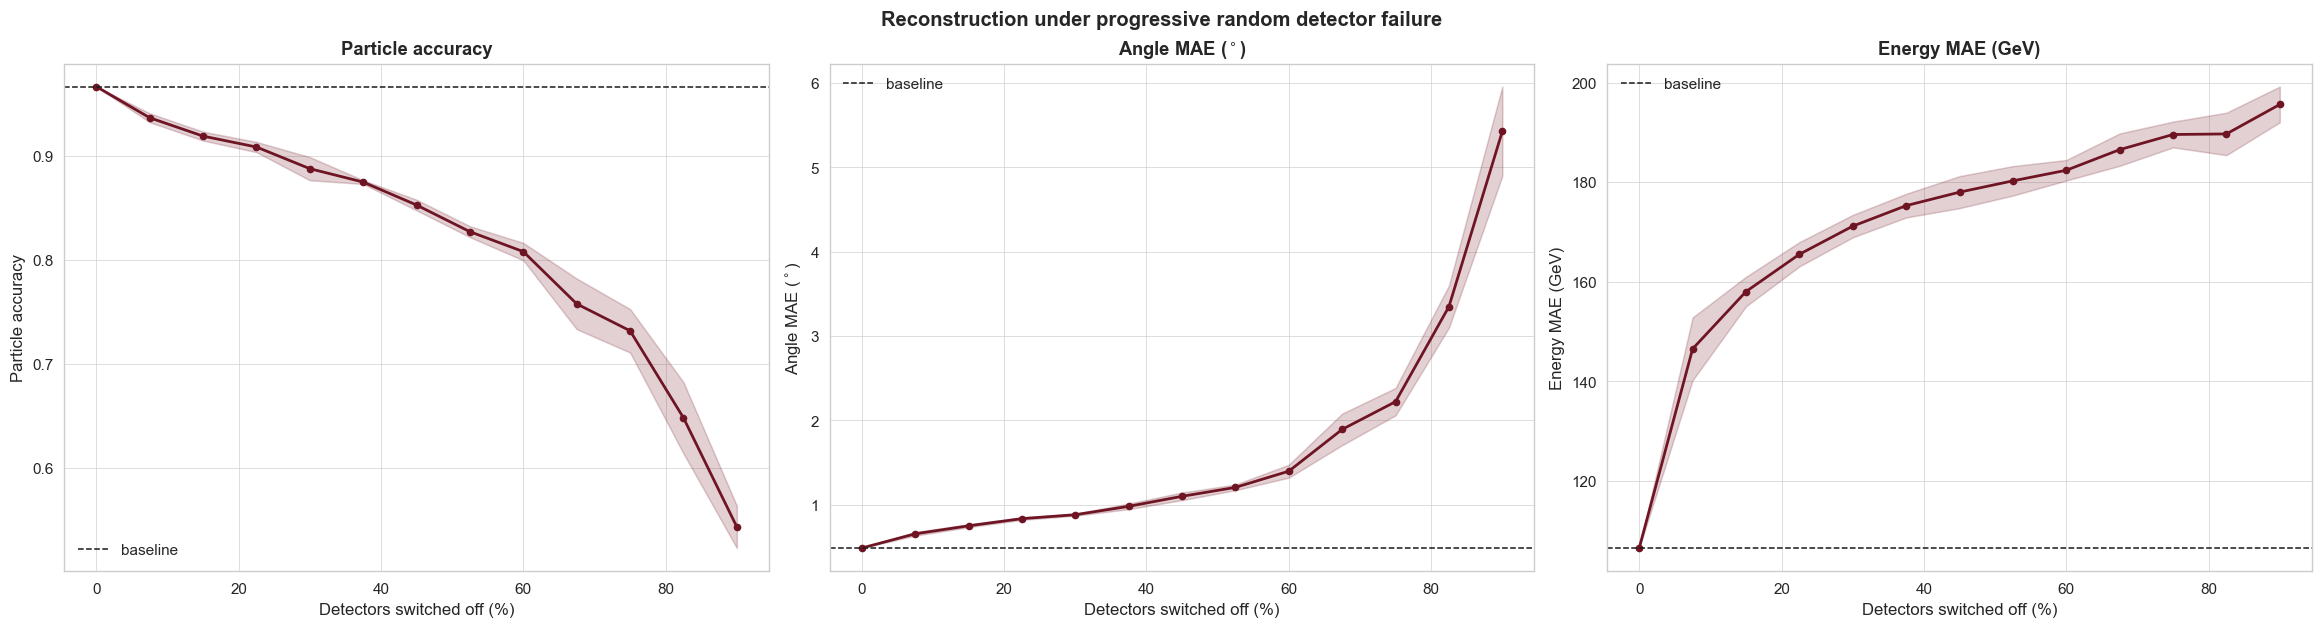

In [51]:
frac_grid = np.linspace(0.0, 0.9, 13)
N_REPS = 4
det_array = np.array(all_detectors)
prog_rows = []
for frac in frac_grid:
    n_off = int(round(frac * len(det_array)))
    for rep in range(N_REPS):
        if n_off == 0:
            m = baseline
        else:
            m = evaluate_with_detectors_off(
                rng_drop.choice(det_array, n_off, replace=False))
        prog_rows.append({"frac": frac, "n_off": n_off, "rep": rep, **m})
prog_df = pd.DataFrame(prog_rows)
prog_stats = prog_df.groupby("frac").agg(["mean", "std"])

fig, axes = plt.subplots(1, 3, figsize=(21, 5.6), constrained_layout=True)
panels = [("particle_acc", "Particle accuracy"),
          ("angle_mae", r"Angle MAE ($^\circ$)"),
          ("energy_mae", "Energy MAE (GeV)")]
xx = prog_stats.index.to_numpy() * 100.0
for ax, (col, title) in zip(axes, panels):
    mu = prog_stats[(col, "mean")].to_numpy()
    sd = np.nan_to_num(prog_stats[(col, "std")].to_numpy())
    ax.plot(xx, mu, color=CONDOR_DARKRED, marker="o", ms=4)
    ax.fill_between(xx, mu - sd, mu + sd, color=CONDOR_DARKRED, alpha=0.2)
    ax.axhline(baseline[col], color=CONDOR_INK, ls="--", lw=1.0, label="baseline")
    ax.set_title(title)
    ax.set_xlabel("Detectors switched off (%)")
    ax.set_ylabel(title)
    ax.legend()
fig.suptitle("Reconstruction under progressive random detector failure",
             fontweight="bold")
fig.savefig(plots_dir / "dropout_progressive.png", dpi=SAVE_DPI)
plt.show()

### 6.3. Regional Dropout

Whole geometric groups are switched off at once - radial rings (from the central
core out to the peripheral detectors) and quadrants. This identifies which *region*
of the array, removed as a block, costs the model the most.

,region,n_off,particle_acc,particle_auc,angle_mae,energy_mae,acc_drop,angle_rise,energy_rise
0,Central core (16),16,0.8613,0.9469,0.7728,171.7076,0.1053,0.2863,65.1948
1,Inner ring,32,0.8823,0.9377,0.9487,172.4481,0.0843,0.4623,65.9353
2,Mid region,32,0.8913,0.9441,0.8581,169.9960,0.0753,0.3716,63.4832
3,Outer ring,20,0.9270,0.9692,0.7736,150.8305,0.0397,0.2871,44.3177
4,Peripheral (20),20,0.9380,0.9730,0.6875,146.8465,0.0287,0.2010,40.3337
5,Quadrant +x +y,30,0.9053,0.9527,0.9312,151.7212,0.0613,0.4447,45.2084
6,Quadrant -x +y,30,0.8680,0.9407,0.8981,158.3021,0.0987,0.4117,51.7893


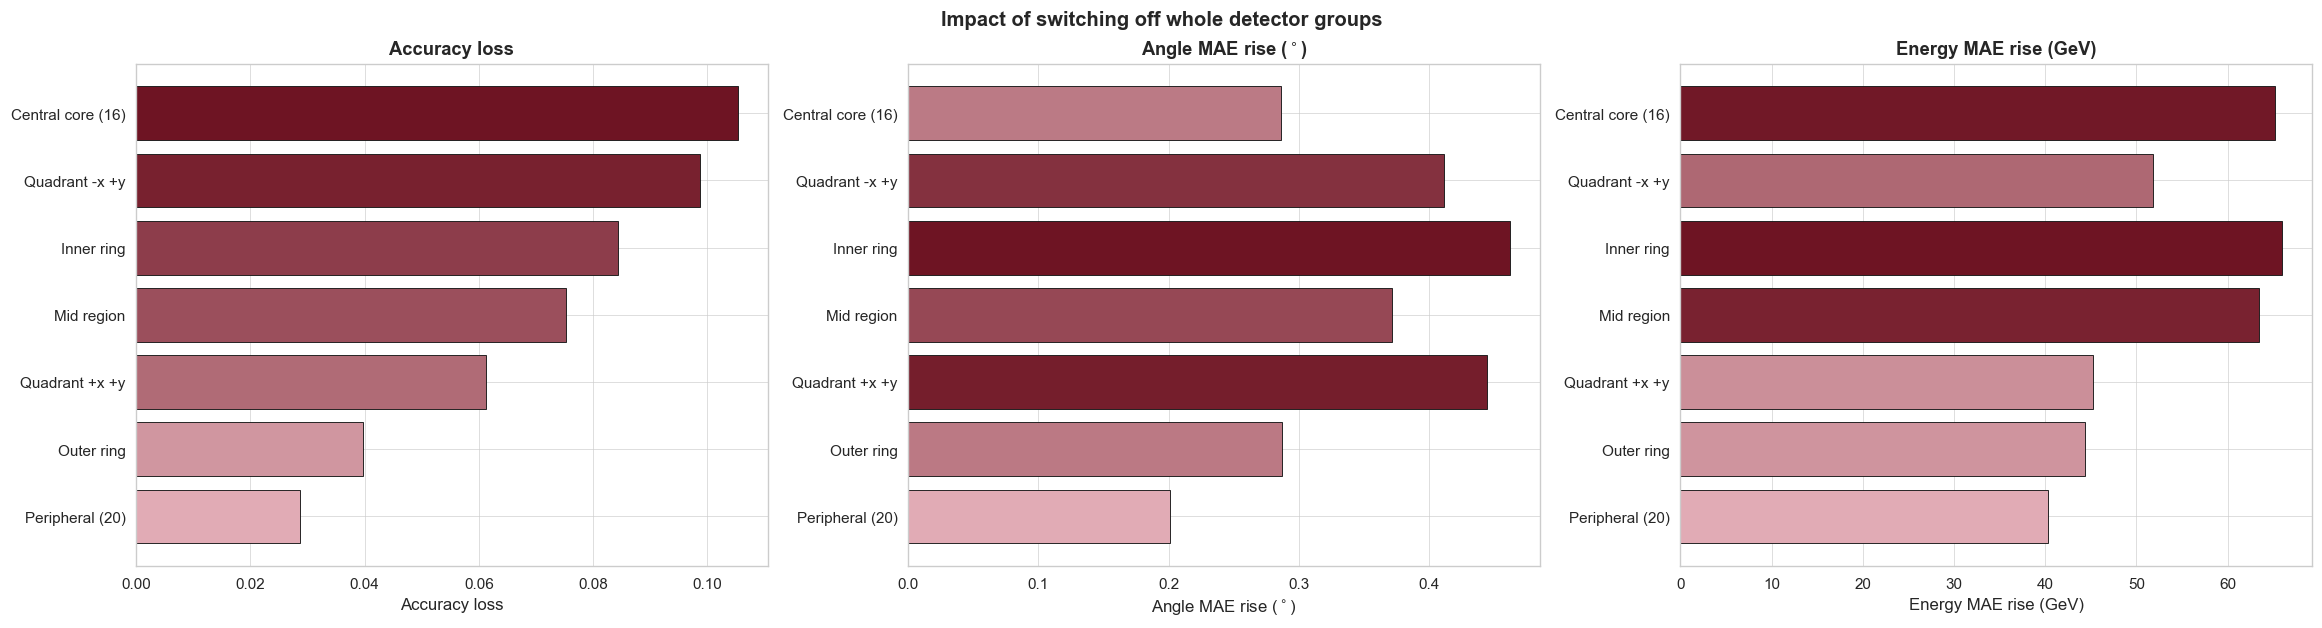

In [52]:
cat = detector_catalog.copy()
cat["rank"] = cat["distance"].rank(method="first").astype(int) - 1
regions = {
    "Central core (16)": cat.nsmallest(16, "distance")["detector_id"].tolist(),
    "Inner ring":  cat[(cat["rank"] >= 16) & (cat["rank"] < 48)]["detector_id"].tolist(),
    "Mid region":  cat[(cat["rank"] >= 48) & (cat["rank"] < 80)]["detector_id"].tolist(),
    "Outer ring":  cat[(cat["rank"] >= 80) & (cat["rank"] < 100)]["detector_id"].tolist(),
    "Peripheral (20)": cat.nlargest(20, "distance")["detector_id"].tolist(),
    "Quadrant +x +y":  cat[(cat["x_center"] >= 0) & (cat["y_center"] >= 0)]["detector_id"].tolist(),
    "Quadrant -x +y":  cat[(cat["x_center"] < 0) & (cat["y_center"] >= 0)]["detector_id"].tolist(),
}
reg_rows = []
for name, ids in regions.items():
    reg_rows.append({"region": name, "n_off": len(ids),
                     **evaluate_with_detectors_off(ids)})
reg_df = pd.DataFrame(reg_rows)
reg_df["acc_drop"]    = baseline["particle_acc"] - reg_df["particle_acc"]
reg_df["angle_rise"]  = reg_df["angle_mae"]  - baseline["angle_mae"]
reg_df["energy_rise"] = reg_df["energy_mae"] - baseline["energy_mae"]
display(reg_df.round(4))

order = reg_df.sort_values("acc_drop")["region"].tolist()
d = reg_df.set_index("region").loc[order]
bars = [("acc_drop", "Accuracy loss"),
        ("angle_rise", r"Angle MAE rise ($^\circ$)"),
        ("energy_rise", "Energy MAE rise (GeV)")]
fig, axes = plt.subplots(1, 3, figsize=(21, 5.6), constrained_layout=True)
for ax, (col, title) in zip(axes, bars):
    # Gradient: darker red = higher degradation (more informative bars)
    _vals = d[col].values
    _vmin, _vmax = _vals.min(), _vals.max()
    _norm_bar = (_vals - _vmin) / (_vmax - _vmin + 1e-9)
    import matplotlib.cm as _cm
    import matplotlib.colors as _mcolors
    # Use Reds colormap anchored to CONDOR dark red as maximum
    _cmap_bar = _mcolors.LinearSegmentedColormap.from_list(
        "condor_reds", ["#f5c6ce", CONDOR_DARKRED])
    _bar_colors = [_cmap_bar(v * 0.85 + 0.15) for v in _norm_bar]
    ax.barh(d.index, d[col], color=_bar_colors, edgecolor=CONDOR_INK, linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel(title)
fig.suptitle("Impact of switching off whole detector groups", fontweight="bold")
fig.savefig(plots_dir / "dropout_regional.png", dpi=SAVE_DPI)
plt.show()

### 6.4. Array Geometry Trade-off

A first, data-driven look at the array design question. Three sparsification
strategies are compared **at matched detector counts**:

- **Random thinning** - detectors removed uniformly at random.
- **Central crop** - only detectors within a shrinking radius are kept (denser, smaller array).
- **Checkerboard** - every other detector removed (uniform, wider pitch).

If central crop beats random thinning at the same count, a compact dense array is
preferable; if the checkerboard holds up, the detector pitch can be widened to save
material and space.

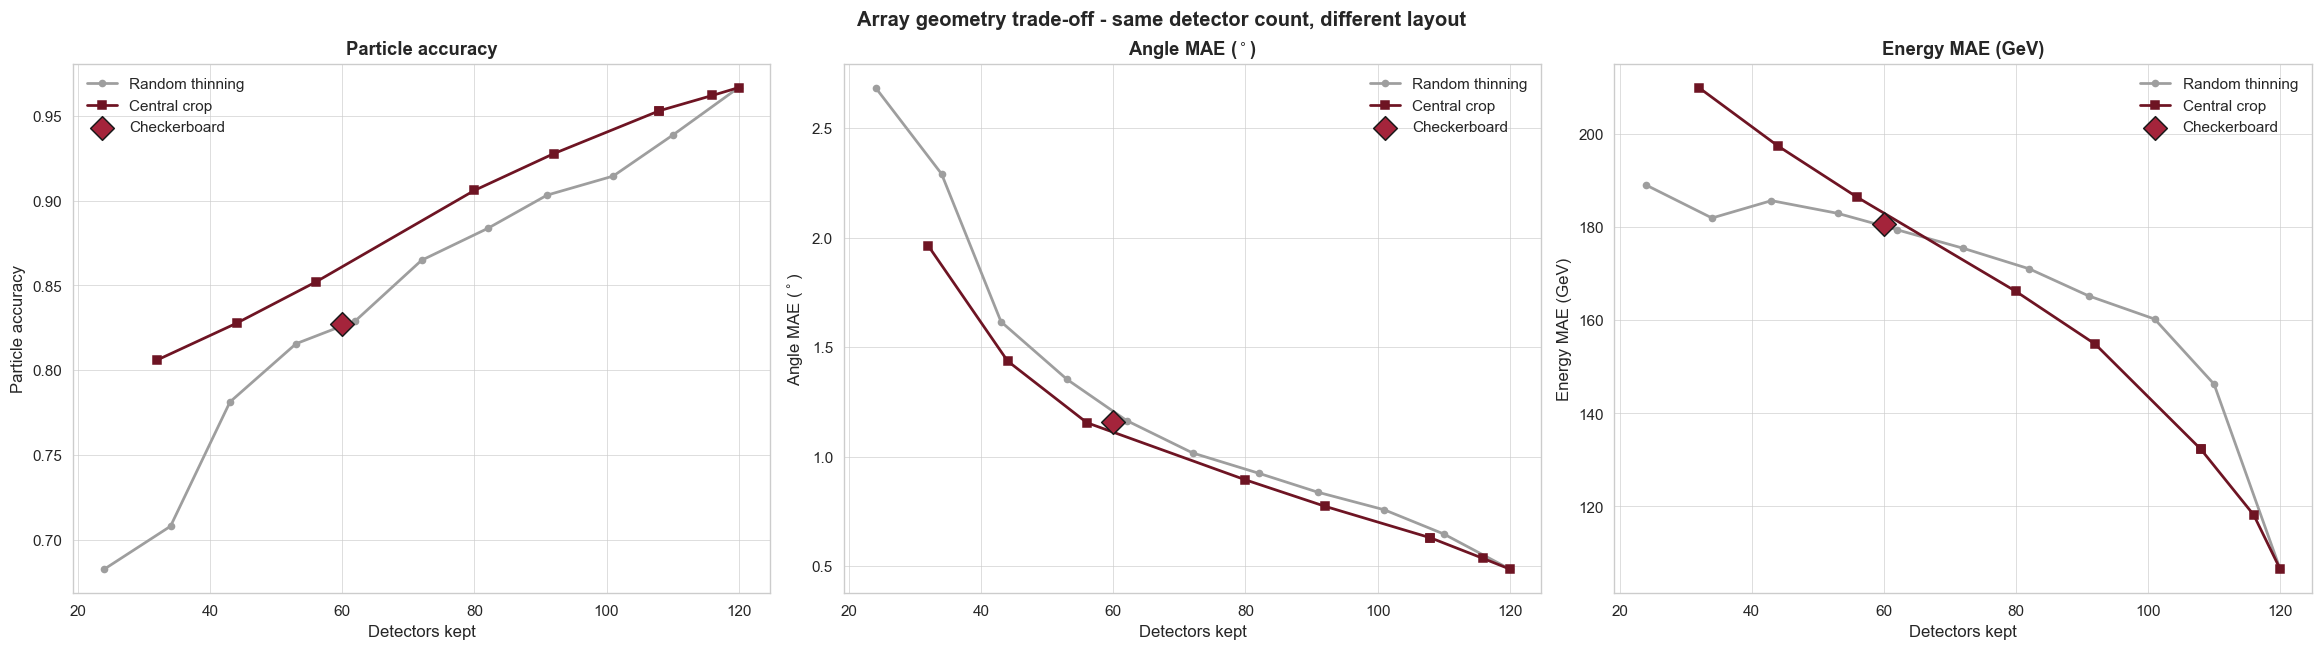

In [53]:
SPACING = 8.7  # m, nominal central-grid pitch
det_xy = detector_catalog.set_index("detector_id")[["x_center", "y_center"]]
det_array = np.array(all_detectors)
n_det = len(det_array)

# (a) random thinning
random_rows = []
for kf in np.linspace(0.2, 1.0, 11):
    n_off = int(round((1.0 - kf) * n_det))
    for rep in range(3):
        off = rng_drop.choice(det_array, n_off, replace=False) if n_off > 0 else []
        random_rows.append({"n_kept": n_det - n_off, **evaluate_with_detectors_off(off)})
random_df = pd.DataFrame(random_rows).groupby("n_kept").mean(numeric_only=True).reset_index()

# (b) central crop - keep detectors within a radius
crop_rows = []
for R in np.linspace(detector_catalog["distance"].quantile(0.25),
                     detector_catalog["distance"].max(), 9):
    off = detector_catalog[detector_catalog["distance"] > R]["detector_id"].tolist()
    crop_rows.append({"n_kept": n_det - len(off), **evaluate_with_detectors_off(off)})
crop_df = pd.DataFrame(crop_rows)

# (c) checkerboard decimation - uniform ~50% thinning
grid_idx = (np.round(det_xy["x_center"] / SPACING)
            + np.round(det_xy["y_center"] / SPACING))
checker_off = det_xy.index[(grid_idx % 2 == 1).to_numpy()].tolist()
m_check = evaluate_with_detectors_off(checker_off)
check_kept = n_det - len(checker_off)

fig, axes = plt.subplots(1, 3, figsize=(21, 5.8), constrained_layout=True)
geo = [("particle_acc", "Particle accuracy"),
       ("angle_mae", r"Angle MAE ($^\circ$)"),
       ("energy_mae", "Energy MAE (GeV)")]
for ax, (col, title) in zip(axes, geo):
    ax.plot(random_df["n_kept"], random_df[col], color=CONDOR_GRAY,
            marker="o", ms=4, label="Random thinning")
    ax.plot(crop_df["n_kept"], crop_df[col], color=CONDOR_DARKRED,
            marker="s", ms=5, label="Central crop")
    ax.scatter([check_kept], [m_check[col]], color=CONDOR_RED, s=120, marker="D",
               zorder=5, edgecolor=CONDOR_INK, label="Checkerboard")
    ax.set_title(title)
    ax.set_xlabel("Detectors kept")
    ax.set_ylabel(title)
    ax.legend()
fig.suptitle("Array geometry trade-off - same detector count, different layout",
             fontweight="bold")
fig.savefig(plots_dir / "dropout_geometry_tradeoff.png", dpi=SAVE_DPI)
plt.show()

> **On full geometry exploration.** Genuinely different layouts (hexagonal,
> elliptical, wider uniform pitch) require re-binning *particle-level* CORSIKA
> output onto new detector positions. The processed dataset only stores
> per-detector aggregates, so it cannot be re-gridded - the analysis above is the
> subset-based proxy: it answers detector-count, spacing and array-size questions
> by *removing* detectors from the existing geometry. A from-scratch geometry study
> (re-running `CONDORPROCESSING_MULTI.py` on the raw CORSIKA files for each candidate
> layout) is the natural next step.

## 7. Summary

### Explainability Findings (Quantitative)
- Spatial: central vs peripheral detector attention.
- Temporal: entropy, self vs context attention.
- Correlations with energy/particle count.
- Embedding separability (variance explained).

---

This document summarizes the key metrics used to evaluate model performance in the three main tasks: Classification (Gamma/Hadron), Angular Reconstruction, and Energy Estimation.

---

## 1. Metrics Summary Table
<div align="center">

| Category | Metric | Notation / Formula | Interpretation | Target Value (Benchmark) |
|:---|:---|:---|:---|:---|
| **🎯 Classification** | **Accuracy** | $\frac{TP + TN}{Total}$ | % of correct predictions (overall) | $85\% - 95\%$ |
| (Gamma/Hadron) | **Precision** | $\frac{TP}{TP + FP}$ | Purity of gamma sample | $> 90\%$ |
| | **Recall (Efficiency)** | $\epsilon_\gamma = \frac{TP}{TP + FN}$ | Gamma retention efficiency | $> 80\%$ |
| | **F1-Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Harmonic balance | $> 85\%$ |
| | **AUC-ROC** | $\int TPR \, d(FPR)$ | Global discriminative ability | $0.90 - 0.98$ |
| | **Q-Factor** | $Q = \frac{\epsilon_\gamma}{\sqrt{\epsilon_h}}$ | **Figure of Merit (IACTs)** | $3 - 7$ |
| **📐 Angle** | **MAE** | $\langle \lvert \hat{\theta} - \theta \rvert \rangle$ | Mean absolute error | $1.0^\circ - 3.0^\circ$ | 
| (Direction) | **PSF68** ($\sigma_{68}$) | $P_{68}(\lvert \hat{\theta} - \theta \rvert)$ | **Angular Resolution (68% Containment)** | $0.5^\circ - 1.5^\circ$ | 
| | **Bias (Zenith)** | $\langle \hat{\theta} - \theta \rangle$ | Systematic zenith bias | $\pm 0.1^\circ$ | 
| | **Opening Angle** | $\psi = \arccos(\hat{\vec{v}} \cdot \vec{v})$ | Solid angle between 3D vectors | Rayleigh distribution | 
| **⚡ Energy** | **MAE** | $\langle \lvert \hat{E} - E \rvert \rangle$ | Mean error (GeV) | Depends on $E$ | 
| (Calorimetry) | **Energy Bias** | $\langle \frac{\hat{E} - E}{E} \rangle$ | **Systematic Relative Bias** | $<\pm 5\%$ | 
| | **Energy Resolution** | $\sigma_{68}(\frac{\hat{E} - E}{E})$ | **Relative Resolution** | $15\% - 30\%$ | 
| | **Migration** | $P(\hat{E}_j \lvert E_i)$ | Energy confusion matrix | Dominant diagonal | 

</div>

---

## 🔍 Detailed Explanation of Key Metrics

### 1. Quality Factor ($Q$-Factor)

This is the fundamental metric for optimizing selection cuts in gamma-ray astronomy (as in MAGIC, CTA, or HAWC). It maximizes the signal ($\gamma$) while suppressing the dominant background (hadrons).

$$Q = \frac{\epsilon_\gamma}{\sqrt{\epsilon_h}}$$

Where:
- $\epsilon_\gamma$: Signal efficiency (Gamma Recall).
- $\epsilon_h$: Residual background efficiency (Hadron False Positive Rate).
- $\sqrt{\epsilon_h}$: Represents the statistical fluctuation of the background (Poisson).

**Interpretation:**
- A factor $Q=5$ means the instrument's sensitivity improves by a factor of 5 compared to no cuts, reducing the required observation time by a factor of 25 ($t \propto 1/Q^2$).

---

### 2. Li & Ma Significance ($\sigma_{LiMa}$)

This is the statistical standard for claiming the discovery of an astrophysical source. It compares events in the source region ($N_{on}$) with a control region ($N_{off}$).

$$S_{LiMa} = \sqrt{2 \left( N_{on} \ln \left[ \frac{1+\alpha}{\alpha} \left( \frac{N_{on}}{N_{on} + N_{off}} \right) \right] + N_{off} \ln \left[ (1+\alpha) \left( \frac{N_{off}}{N_{on} + N_{off}} \right) \right] \right)}$$

- $\alpha$: Exposure ratio between ON and OFF regions ($t_{on}/t_{off}$).
- **Discovery threshold:** $S > 5\sigma$ (random fluctuation probability $< 2.8 \times 10^{-7}$).

---

### 3. Angular Resolution (PSF - Point Spread Function)

Instead of using a Gaussian standard deviation ($\sigma$), cosmic ray experiments use the **68% Containment Radius** (PSF68), since error distributions often have long non-Gaussian tails.

- **Definition:** The angular value $\Psi$ such that 68% of reconstructed events have an error less than $\Psi$.
- **Importance:** Defines the telescope's ability to resolve extended source morphology and reduces background contamination for point sources.

---

### 4. Energy Metrics: Bias and Resolution

Since the cosmic ray spectrum follows a power law ($dN/dE \propto E^{-\gamma}$), small systematic errors can severely distort the measured flux.

#### **Energy Bias**
$$\text{Bias} = \left\langle \frac{E_{pred} - E_{true}}{E_{true}} \right\rangle$$
- **Goal:** $\approx 0\%$.
- **Risk:** A positive bias ($+10\%$) shifts low-energy events (very abundant) to higher energy bins, creating false signals or "harder spectra".

#### **Energy Resolution**
$$\frac{\sigma_E}{E} = \frac{1}{2} (\text{Percentile}_{84} - \text{Percentile}_{16}) \quad \text{of the distribution } \frac{\Delta E}{E}$$
- The robust interquartile range is used instead of the simple standard deviation to mitigate the effect of outliers.

---

### 5. Migration Matrix

Visualizes the probability that an event with true energy $E_i$ is reconstructed with energy $E_j$.

**Theoretical Example:**

| $E_{true}$ \ $E_{rec}$ | **300 GeV** | **500 GeV** | **800 GeV** |
|:---:|:---:|:---:|:---:|
| **300 GeV** | **0.85** | 0.12 | 0.03 |
| **500 GeV** | 0.10 | **0.80** | 0.10 |
| **800 GeV** | 0.05 | 0.15 | **0.80** |

- **Diagonal:** Represents reconstruction accuracy.
- **Upper Triangle:** "Spill-over" events (reconstructed with more energy than true).
- **Use:** This matrix is essential for the *Unfolding* (deconvolution) process of the final energy spectrum.

In [61]:
# --- Liberar VRAM antes de los experimentos (GPU de 4 GB) ---
import gc
for _n in ["model", "attention_model"]:
    globals().pop(_n, None)
gc.collect()
tf.keras.backend.clear_session()
gc.collect()
print("VRAM liberada — listo para 8.1 / 8.2 / 8.3")

VRAM liberada — listo para 8.1 / 8.2 / 8.3


## 8. Methodological Validation (thesis)

> **Thesis-only section.** These experiments answer three reviewer-facing
> robustness questions for the thesis (Chapters 4-5). They are **not** part of the
> published paper and are gated behind flags so that *Run All* does not trigger
> hours of retraining. Run the notebook top-to-bottom first (so the data pipeline,
> `build_multitask_model`, and the in-memory split arrays exist), then set the flag
> for the experiment you want and execute its cell.
>
> | # | Experiment | Flag | Question | Approx. cost |
> |---|---|---|---|---|
> | 8.1 | Leakage control | `RUN_EXP1_LEAKAGE` | Does balance-before-split inflate proton metrics? | ~1 run |
> | 8.2 | Multi-task vs single-task | `RUN_EXP2_ABLATION` | Does joint training beat 3 separate models? | ~4 runs |
> | 8.3 | Multi-seed stability | `RUN_EXP3_MULTISEED` | How stable are the metrics across seeds? | N runs |
>
> Each cell saves its results to `pipeline_artifacts/diagnostics/` for traceability.


In [ ]:
# ============================================================
# 8.0  Shared utility for the validation experiments
# ============================================================
# Reuses the in-notebook pipeline: build_multitask_model(), balance_by_group(),
# build_sequence_list(), compute_global_features(), parse_energy(), central_ids,
# FEATURE_NAMES, pad_sequences, strategy, BATCH_SIZE, EPOCHS, SEED.
import gc
from sklearn.metrics import roc_auc_score

VALID_DIR = ARTIFACTS_DIR / "diagnostics"
VALID_DIR.mkdir(parents=True, exist_ok=True)

MULTITASK_WEIGHTS = {"particle_output": 0.6, "angle_output": 1.0, "energy_output": 1.5}

def free_gpu(*extra):
    """Release VRAM held by previously built models before constructing a new one.
    Essential on the 4 GB laptop GPU: after a full notebook run, the trained `model`
    and `attention_model` still occupy VRAM, which would cause an OOM (TensorFlow
    reports it as 'Dst tensor is not initialized'). Safe to call repeatedly."""
    g = globals()
    for n in ("model", "attention_model") + tuple(extra):
        g.pop(n, None)
    gc.collect()
    tf.keras.backend.clear_session()
    gc.collect()

def _build_compiled(max_len, gdim, loss_weights, seed):
    """Fresh model with custom loss weights; metrics are computed manually downstream."""
    random.seed(seed); np.random.seed(seed); tf.random.set_seed(seed)
    with strategy.scope():
        m = build_multitask_model(sequence_shape=(max_len, len(FEATURE_NAMES)), global_dim=gdim)
        m.compile(
            optimizer=optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),
            loss={"particle_output": "binary_crossentropy",
                  "angle_output": tf.keras.losses.Huber(),
                  "energy_output": tf.keras.losses.Huber()},
            loss_weights=loss_weights,
        )
    return m

def train_eval(train, val, test, loss_weights, seed=SEED, epochs=EPOCHS, verbose=0):
    """train/val/test are tuples (X_pad, X_global, label, angle, energy_continuous).
    Energy is z-scored on the train split only. Returns a metrics dict (incl. per-class).
    Label convention: 0 = gamma/photon, 1 = proton (see the balance_summary cell)."""
    Xtr, Xgtr, ltr, atr, etr = train
    Xva, Xgva, lva, ava, eva = val
    Xte, Xgte, lte, ate, ete = test
    e_mean = float(np.mean(etr)); e_std = float(np.std(etr)) + 1e-8
    sc = lambda e: (np.asarray(e, dtype=np.float32) - e_mean) / e_std

    free_gpu()  # release VRAM from any previously built model before allocating
    m = _build_compiled(Xtr.shape[1], Xgtr.shape[1], loss_weights, seed)
    cbs = [callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True, verbose=0),
           callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=7, min_lr=1e-6, verbose=0)]
    m.fit([Xtr, Xgtr], [ltr, atr, sc(etr)],
          validation_data=([Xva, Xgva], [lva, ava, sc(eva)]),
          epochs=epochs, batch_size=BATCH_SIZE, callbacks=cbs, verbose=verbose)

    pp, pa, pe = m.predict([Xte, Xgte], batch_size=BATCH_SIZE, verbose=0)
    pp = pp.reshape(-1); pa = pa.reshape(-1); pe = pe.reshape(-1) * e_std + e_mean
    lte = np.asarray(lte); ate = np.asarray(ate); ete = np.asarray(ete, dtype=np.float32)

    res = {}
    res["accuracy"]   = float(np.mean((pp >= 0.5).astype(int) == lte))
    try:               res["auc"] = float(roc_auc_score(lte, pp))
    except Exception:  res["auc"] = float("nan")
    res["angle_mae"]  = float(np.mean(np.abs(pa - ate)))
    res["energy_mae"] = float(np.mean(np.abs(pe - ete)))
    for cls, name in [(0, "gamma"), (1, "proton")]:
        mk = lte == cls
        if mk.sum() > 0:
            frac = (pe[mk] - ete[mk]) / ete[mk]
            res[f"Ebias_{name}_pct"] = float(np.mean(frac) * 100)
            res[f"Eres_{name}_pct"]  = float(np.std(frac) * 100)
            res[f"angle_mae_{name}"] = float(np.mean(np.abs(pa[mk] - ate[mk])))
            res[f"acc_{name}"]       = float(np.mean((pp[mk] >= 0.5).astype(int) == lte[mk]))
    del m; gc.collect(); tf.keras.backend.clear_session()
    return res

print("Validation utilities ready. Label convention: 0 = gamma, 1 = proton.")


### 8.1  Leakage control - split before balancing

The main pipeline balances **before** the train/val/test split, so oversampled
proton events (the minority class) can have identical copies in both train and
test. This experiment removes that leak: it splits the **raw, unique** events
first, then oversamples **only** the train and validation partitions, leaving the
**test set untouched and disjoint from training**. Per-class metrics on this
leak-free test set are compared against the values reported in the thesis
(`energy_stratified_stats.csv`: proton resolution 16-18%, gamma 28-41%). A large
drop in proton energy resolution here would indicate the original gap was partly a
leakage artifact; a stable value would confirm it is physical.


In [ ]:
RUN_EXP1_LEAKAGE = False   # <-- set True to run (~1 training run)

if RUN_EXP1_LEAKAGE:
    raw = df_full.reset_index(drop=True)
    strata_raw = (raw["angle"].round().astype(int).astype(str) + "_" + raw["label"].astype(str)).to_numpy()
    idx_all = np.arange(len(raw))
    tr_i, tmp_i = train_test_split(idx_all, test_size=1.0 - TRAIN_RATIO,
                                   stratify=strata_raw, random_state=SEED, shuffle=True)
    vf = VAL_RATIO / (1.0 - TRAIN_RATIO)
    va_i, te_i = train_test_split(tmp_i, test_size=1.0 - vf,
                                  stratify=strata_raw[tmp_i], random_state=SEED, shuffle=True)

    # Balance TRAIN and VAL only (oversample); TEST stays natural and disjoint -> no leak
    df_tr = balance_by_group(raw.iloc[tr_i].copy(), ("label", "angle", "energy"), SEED)[0]
    df_va = balance_by_group(raw.iloc[va_i].copy(), ("label", "angle", "energy"), SEED)[0]
    df_te = raw.iloc[te_i].copy()
    print(f"events  train={len(df_tr)}  val={len(df_va)}  test(unique)={len(df_te)}")

    def _to_arrays(df):
        seqs = build_sequence_list(df)
        Xg   = compute_global_features(seqs, central_ids)
        return (seqs, Xg, df["angle"].to_numpy(np.float32),
                df["label"].to_numpy(np.int32), parse_energy(df["energy"].to_numpy()))

    s_tr, Xg_tr, a_tr, l_tr, e_tr = _to_arrays(df_tr)
    s_va, Xg_va, a_va, l_va, e_va = _to_arrays(df_va)
    s_te, Xg_te, a_te, l_te, e_te = _to_arrays(df_te)
    ml = max(max(len(s) for s in s_tr), max(len(s) for s in s_va), max(len(s) for s in s_te))
    ml = min(ml, max_sequence_length)  # cap at the trained length (472) to bound O(ml^2) attention memory on the 4 GB GPU
    _pad = lambda S: pad_sequences(S, maxlen=ml, padding="post", truncating="post", dtype="float32")

    res_leak = train_eval(
        (_pad(s_tr), Xg_tr, l_tr, a_tr, e_tr),
        (_pad(s_va), Xg_va, l_va, a_va, e_va),
        (_pad(s_te), Xg_te, l_te, a_te, e_te),
        loss_weights=MULTITASK_WEIGHTS, seed=SEED, epochs=EPOCHS, verbose=1)

    print("\n=== Leak-free (split-before-balance) test metrics ===")
    for k, v in res_leak.items():
        print(f"  {k:20s} {v:.4f}")
    print("\nThesis reference (balanced, possibly leaky): proton Eres 16-18%, gamma Eres 28-41%")
    json.dump(res_leak, open(VALID_DIR / "validation_leakage_control.json", "w"), indent=2)
    print(f"saved -> {VALID_DIR / 'validation_leakage_control.json'}")
else:
    print("RUN_EXP1_LEAKAGE = False  (skipped)")


### 8.2  Multi-task vs single-task ablation

The thesis asserts that joint multi-task training is beneficial but never
benchmarks it against single-task models. Here the **same architecture** is
trained four times on the standard split: once with all three losses active
(multi-task) and three times with a single task's loss weight active and the other
two set to zero (single-task). Compare each task's **own** metric across the two
regimes (the off-task metrics in a single-task row are meaningless and should be
ignored). The shared CNN backbone is identical in both regimes; in the
single-task runs it receives gradients from one objective only.


In [ ]:
RUN_EXP2_ABLATION = False   # <-- set True to run (~4 training runs)

if RUN_EXP2_ABLATION:
    std_train = (X_train, Xg_train, y_label_train, y_angle_train, y_energy_train_cont)
    std_val   = (X_val,   Xg_val,   y_label_val,   y_angle_val,   y_energy_val_cont)
    std_test  = (X_test,  Xg_test,  y_label_test,  y_angle_test,  y_energy_test_cont)

    configs = {
        "multitask":       {"particle_output": 0.6, "angle_output": 1.0, "energy_output": 1.5},
        "single_particle": {"particle_output": 0.6, "angle_output": 0.0, "energy_output": 0.0},
        "single_angle":    {"particle_output": 0.0, "angle_output": 1.0, "energy_output": 0.0},
        "single_energy":   {"particle_output": 0.0, "angle_output": 0.0, "energy_output": 1.5},
    }
    rows = []
    for name, w in configs.items():
        print(f"\n--- training {name} ---")
        r = train_eval(std_train, std_val, std_test, loss_weights=w, seed=SEED, epochs=EPOCHS, verbose=0)
        r["config"] = name
        rows.append(r)
        print(f"  acc={r['accuracy']:.4f}  auc={r['auc']:.4f}  "
              f"angleMAE={r['angle_mae']:.4f}  energyMAE={r['energy_mae']:.2f}")
    df_ab = pd.DataFrame(rows).set_index("config")
    cols = ["accuracy", "auc", "angle_mae", "energy_mae"]
    print("\n=== Multi-task vs single-task (read each task's OWN metric) ===")
    print(df_ab[cols].round(4).to_string())
    df_ab.to_csv(VALID_DIR / "validation_multitask_ablation.csv")
    print(f"saved -> {VALID_DIR / 'validation_multitask_ablation.csv'}")
else:
    print("RUN_EXP2_ABLATION = False  (skipped)")


### 8.3  Multi-seed stability

All headline numbers come from a single training run. This experiment retrains the
multi-task model under several random seeds (same data split) and reports
mean +/- standard deviation, so the thesis can state confidence intervals instead
of point estimates. Add more seeds for tighter intervals at proportional cost.


In [ ]:
RUN_EXP3_MULTISEED = False     # <-- set True to run (len(SEEDS) training runs)
SEEDS = [42, 1, 7]             # add e.g. 123, 2025 for tighter CIs

if RUN_EXP3_MULTISEED:
    std_train = (X_train, Xg_train, y_label_train, y_angle_train, y_energy_train_cont)
    std_val   = (X_val,   Xg_val,   y_label_val,   y_angle_val,   y_energy_val_cont)
    std_test  = (X_test,  Xg_test,  y_label_test,  y_angle_test,  y_energy_test_cont)

    rows = []
    for sd in SEEDS:
        print(f"\n--- seed {sd} ---")
        r = train_eval(std_train, std_val, std_test, loss_weights=MULTITASK_WEIGHTS,
                       seed=sd, epochs=EPOCHS, verbose=0)
        r["seed"] = sd
        rows.append(r)
        print(f"  acc={r['accuracy']:.4f}  auc={r['auc']:.4f}  "
              f"angleMAE={r['angle_mae']:.4f}  energyMAE={r['energy_mae']:.2f}")
    df_ms = pd.DataFrame(rows).set_index("seed")
    cols = ["accuracy", "auc", "angle_mae", "energy_mae"]
    summary = df_ms[cols].agg(["mean", "std"])
    print("\n=== Multi-seed summary (mean / std) ===")
    print(summary.round(4).to_string())
    df_ms.to_csv(VALID_DIR / "validation_multiseed.csv")
    summary.to_csv(VALID_DIR / "validation_multiseed_summary.csv")
    print(f"saved -> {VALID_DIR / 'validation_multiseed.csv'}")
else:
    print("RUN_EXP3_MULTISEED = False  (skipped)")
